# 2026 K-DATA SCIENCE 해커톤 — 한국산림복지진흥원 과제
# 데이터 기반 산림복지 수요 예측 및 시설 운영 최적화 AI모델 구축

**활용 데이터**: 『2024년 산림휴양·복지활동 조사』 원자료 (2025년 실시, 응답자 11,949명 x 668문항, 개인 가중치 포함)

이 노트북은 다음 순서로 구성됩니다.

1. 데이터 로드 및 구조 파악
2. 다개년(2019~2024) 트렌드 분석 및 인구변화 기반 수요전망
3. 전처리 (가구구조 복원, 라벨링, 다중응답/반복측정 문항 정리)
4. 파생변수 생성 (생애주기 세그먼트, 참여 프로필, 인지-이용-의향 퍼널, 계절/지출 패턴 등)
5. 탐색적 데이터분석(EDA) 및 가중 통계
6. 교차분석 / 통계적 가설검정
7. K-means 세그먼트(페르소나) 분석
8. 선호 활동유형 분류 예측모델
9. 선호시설 다중레이블 추천모델
10. 지역별 시설 입지 적합도 스코어링
11. 결론 및 솔루션 제안 요약

> 상세한 배경, 방법론적 근거, 해석과 비즈니스 제안은 함께 제공되는 `forest_welfare_report.md` 보고서를 참고하세요.


## 1. 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font="Malgun Gothic")   # macOS 한글 폰트. Windows는 'Malgun Gothic'으로 교체
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860", "#DA8BC3", "#8C8C8C", "#CCB974"]

BASE = Path("..")   # 이 노트북(분석산출물/)의 상위 폴더 = 원본 데이터 폴더
FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

raw = pd.read_excel(BASE / "DATA_2024년 산림휴양복지활동 조사(공표용)_가중치 포함.xlsx")
print("원자료 크기:", raw.shape)
raw.head(3)

원자료 크기: (11949, 668)


,IDX,LIST,NO0,CO11,CO12,CO13,CO21,CO22,CO30,CO40,...,D_SQ6,D_SQ7,D_DQ2,D_SQ3,D_DQ3,D_SQ8,D_DQ5,D_SQ4,D_CO1112,D_CO11
0,NaN,NaN,1,31,60,64,97,0,NaN,NaN,...,2,7,3,1,3,1,1.0,2,2,9
1,NaN,NaN,1,31,60,64,97,0,NaN,NaN,...,1,6,3,2,2,1,6.0,2,2,9
2,NaN,NaN,2,31,60,64,97,0,NaN,NaN,...,2,5,3,2,2,2,NaN,2,2,9


In [2]:
guide_label = pd.read_excel(BASE / "2024년 산림휴양복지활동조사_변수가이드_공표용.xlsx", sheet_name="변수정보_Label")
guide_label.columns = ["var", "pos", "label"]
guide_label = guide_label.iloc[1:].reset_index(drop=True)

guide_value = pd.read_excel(BASE / "2024년 산림휴양복지활동조사_변수가이드_공표용.xlsx", sheet_name="변수정보_value")
guide_value.columns = ["var", "code", "label"]
guide_value["var"] = guide_value["var"].ffill()
guide_value = guide_value.iloc[1:].reset_index(drop=True)

valuemap = {}
for v, g in guide_value.groupby("var"):
    valuemap[v] = {row["code"]: row["label"] for _, row in g.iterrows() if pd.notna(row["code"])}

print(f"레이블 정보가 있는 변수 수: {len(valuemap)}개 / 전체 컬럼 수: {raw.shape[1]}개")

레이블 정보가 있는 변수 수: 441개 / 전체 컬럼 수: 668개


### 데이터 구조상 특이사항 (전처리 설계의 근거)

원자료를 점검한 결과 다음과 같은 구조적 특징이 확인되어, 이를 반영한 전처리가 필요합니다.

1. **개인 단위 데이터 + 가구 단위 변수 혼재**: 행(11,949개)은 만 15세 이상 가구원 개인이지만, 가구소득(DQ5) 등은 가구주 1명에게만 응답되어 있습니다. `NO0==1`이 가구주(각 가구의 첫 행)를 의미하므로, 이를 이용해 가구ID를 복원하고 가구단위 변수를 가구원 전체에 전파해야 합니다.
2. **다중응답(복수응답) 문항의 더미 인코딩**: 예를 들어 Q1(활동유형)은 `Q1A1~Q1A4` 4개 컬럼으로 존재하는데, 각 컬럼은 "옵션 k가 선택되었는가"를 나타내는 고정 슬롯이며(Q1A1은 항상 코드1 또는 결측) 응답자가 여러 옵션을 선택하면 여러 컬럼에 값이 채워집니다.
3. **반복측정(방문기록) 문항**: Q11(당일형)·Q12(숙박형)은 응답자 1인이 경험한 개별 활동(최대 15개)마다 시기·지역·동반유형·목적·지출액을 반복 기록한 구조로, 실제로는 "응답자 x 방문기록"의 롱포맷 데이터가 와이드로 펼쳐져 있습니다.
4. **구조적 결측(스킵 패턴)**: Q10~Q16(당일/숙박형 세부문항)은 Q1에서 해당 유형을 경험하지 않았다고 답한 응답자에게는 애초에 질문되지 않아 결측입니다. 무작위 결측이 아니므로 임의로 대체하지 않고 "미해당"으로 별도 처리합니다.
5. **개인 가중치(WT)**: 표본(11,949명)을 전국민(15세 이상)으로 확장하기 위한 가중치이며, 합계는 약 4,640만 명으로 15세 이상 인구 추정치와 유사합니다. 따라서 모든 비율/평균은 가중 통계로 산출합니다.


## 2. 다개년(2019~2024) 트렌드 분석 및 인구변화 기반 수요전망

『2024년 산림휴양·복지활동 조사』는 매년 실시되는 조사이며, 이번에는 **2020~2025년 조사(각각 전년도인 2019~2024년 활동을 질문) 6개년치 원자료**와
**통계청 장래인구추계**가 함께 제공되었습니다. 이를 활용해 해커톤 요약서의 배경 서술("최근 산림휴양 트렌드가 등산 중심에서 자연풍경감상·치유휴식으로 재편되고,
1인 가구 증가와 고령화에 따라 수요가 세분화되고 있다")이 실제 데이터로 뒷받침되는지 검증하고, 향후 인구구조 변화가 수요에 미칠 영향을 전망합니다.

**연도별 파일 구조가 다른 이유**: 6개 연도 파일은 조사 시행 시점의 설문 문항 순서·명명 규칙이 달라(예: 2021년만 변수명이 `Q1a1_...`, 나머지는 `문1. ...` 형태)
컬럼 수도 384~495개로 제각각입니다. 668개 변수를 모두 연도별로 일치시키는 것은 신뢰성이 떨어지므로, 6개 연도 모두에서 **동일한 의미로 안정적으로 식별 가능한
핵심 지표(활동유형 참여, 연령대, 만족도, 가중치)만 선별**하여 시계열을 구성했습니다. 이는 무리한 전체 항목 병합보다 정확성을 우선한 설계입니다.


In [3]:
FILES = {2020:"2020_총괄_20260403_70188.csv", 2021:"2021_총괄_20260403_70188.csv", 2022:"2022_총괄_20260403_70188.csv",
         2023:"2023_총괄_20260403_70188.csv", 2024:"2024_총괄_20260403_70188.csv", 2025:"2025_총괄_20260428_71819.csv"}

import re
records, age_records, sat_records = [], [], []

for survey_year, fname in FILES.items():
    activity_year = survey_year - 1  # 조사는 항상 "지난해" 활동을 질문
    dfy = pd.read_csv(BASE / fname, encoding="cp949")
    cols = dfy.columns.tolist()

    wt_col = [c for c in cols if "가중" in c][0]
    q1_cols = [c for c in cols if c.startswith(("Q1a1", "Q1a2", "Q1a3", "Q1a4"))]
    if not q1_cols:
        q1_cols = [c for c in cols if ("문1." in c and "산림휴양" in c and "이유" not in c) and re.search(r"[1-4]$", c)]
    q1_cols = sorted(q1_cols, key=lambda c: cols.index(c))[:4]
    age_col = [c for c in cols if c in ("연령별", "연령코드")][0]
    wt = dfy[wt_col]

    def wrate(mask, denom_mask=None):
        base = wt.notna()
        if denom_mask is not None:
            base = base & denom_mask
        return np.average(mask[base].astype(float), weights=wt[base]) if base.sum() else np.nan

    exp_daily, exp_daytrip, exp_overnight, exp_none = [dfy[c].notna() for c in q1_cols]

    records.append({"활동연도": activity_year, "n": len(dfy), "가중인구": wt.sum(),
        "일상형": wrate(exp_daily)*100, "당일형": wrate(exp_daytrip)*100,
        "숙박형": wrate(exp_overnight)*100, "경험없음": wrate(exp_none)*100})

    max_age_code = dfy[age_col].max()
    age_map = ({1:"15-19세",2:"20대",3:"30대",4:"40대",5:"50대",6:"60대",7:"70세 이상"} if max_age_code >= 7
               else {1:"15-19세",2:"20대",3:"30대",4:"40대",5:"50대",6:"60세 이상"})
    age_band = dfy[age_col].map(age_map)
    for band in age_map.values():
        m = (age_band == band)
        if m.sum() == 0:
            continue
        age_records.append({"활동연도": activity_year, "연령대": band,
                             "참여율(당일+숙박)": wrate(exp_daytrip | exp_overnight, denom_mask=m)*100})

    def find_cols(must_all=(), any_of=()):
        return [c for c in cols if all(m_ in c for m_ in must_all) and (not any_of or any(a in c for a in any_of))]
    sat_daily_c = [c for c in cols if ("만족" in c) and ("일상형" in c or ("①" in c and "당일형" not in c))]
    sat_day_c = find_cols(must_all=["만족"], any_of=["당일형"])
    sat_night_c = find_cols(must_all=["만족"], any_of=["숙박형"])
    sat_records.append({"활동연도": activity_year,
        "일상형만족도": dfy[sat_daily_c[0]].mean() if sat_daily_c else np.nan,
        "당일형만족도": dfy[sat_day_c[0]].mean() if sat_day_c else np.nan,
        "숙박형만족도": dfy[sat_night_c[0]].mean() if sat_night_c else np.nan})

trend_df = pd.DataFrame(records).sort_values("활동연도")
age_trend_df = pd.DataFrame(age_records)
sat_trend_df = pd.DataFrame(sat_records).sort_values("활동연도")
display(trend_df.round(1))

,활동연도,n,가중인구,일상형,당일형,숙박형,경험없음
0,2019,10111,48096957.0,47.6,51.1,30.0,18.6
1,2020,10248,45669979.0,51.5,45.8,19.8,20.8
2,2021,10236,45693645.0,46.7,40.6,20.0,24.2
3,2022,11457,45872017.0,52.8,42.9,22.9,18.0
4,2023,11851,46265820.0,49.8,48.3,28.5,19.3
5,2024,11949,46426098.0,57.3,54.4,30.8,12.1


### 2-1. 활동유형 참여율 추이 (2019~2024)

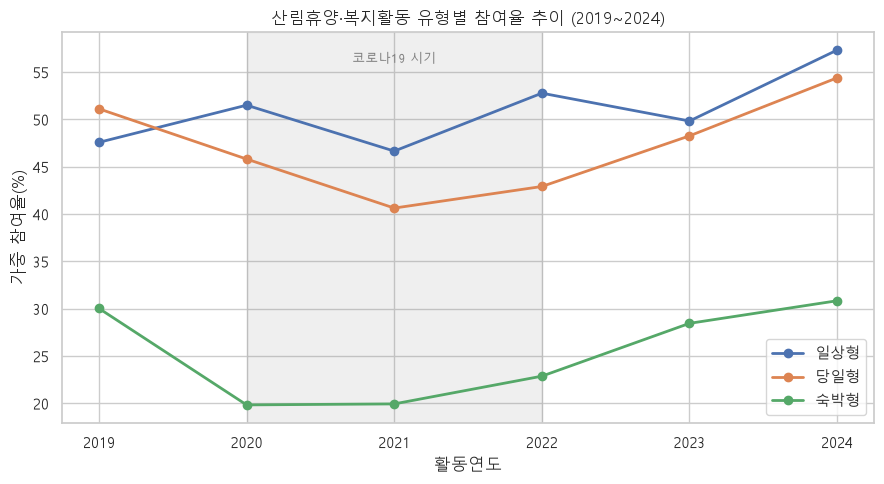

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for col, color in zip(["일상형","당일형","숙박형"], PALETTE[:3]):
    ax.plot(trend_df["활동연도"], trend_df[col], marker="o", label=col, color=color, linewidth=2)
ax.axvspan(2020, 2022, color="gray", alpha=0.12)
ax.text(2021, 0.95, "코로나19 시기", ha="center", va="top", fontsize=9, color="gray", transform=ax.get_xaxis_transform())
ax.set_xlabel("활동연도"); ax.set_ylabel("가중 참여율(%)")
ax.set_title("산림휴양·복지활동 유형별 참여율 추이 (2019~2024)")
ax.legend(); plt.tight_layout(); plt.savefig(FIGDIR / "00_trend_participation.png", dpi=150); plt.show()

**해석**: 2019년 대비 2020년, 당일형(51.1%→45.8%)·숙박형(30.0%→19.8%)은 뚜렷이 하락했지만 **일상형(생활권 숲/공원)은 오히려 47.6%→51.5%로 상승**했습니다 —
코로나19 시기 원거리 이동·숙박은 기피하되 거주지 인근 산림·공원 이용은 늘었다는 뜻으로 해석됩니다. 이후 **당일형은 2021년(40.6%), 숙박형은 2020년(19.8%)에 각각 저점을 찍고** 반등해
2023년부터 세 유형 모두 회복세를 보이다, **2024년에는 세 유형 모두 6개년 중 최고치, 무경험률은 최저치**를 기록했습니다(숙박형은 2020→2021년 19.8%→20.0%로 이미 소폭 반등한 상태였다는 점에 유의).

### 2-2. 연령대별 참여율 추이 (고령층 포함)

연령대,15-19세,20대,30대,40대,50대,60대,60세 이상,70세 이상
활동연도,,,,,,,,
2019,66.7,62.9,73.7,73.3,65.3,NaN,40.9,NaN
2020,52.5,57.5,63.4,64.7,56.9,NaN,34.2,NaN
2021,53.9,57.1,64.8,60.0,49.9,NaN,30.0,NaN
2022,46.5,59.3,66.8,63.4,59.9,NaN,36.8,NaN
2023,59.5,58.3,64.0,71.9,66.2,NaN,43.6,NaN
2024,64.1,70.2,75.8,78.2,70.7,59.9,NaN,33.9


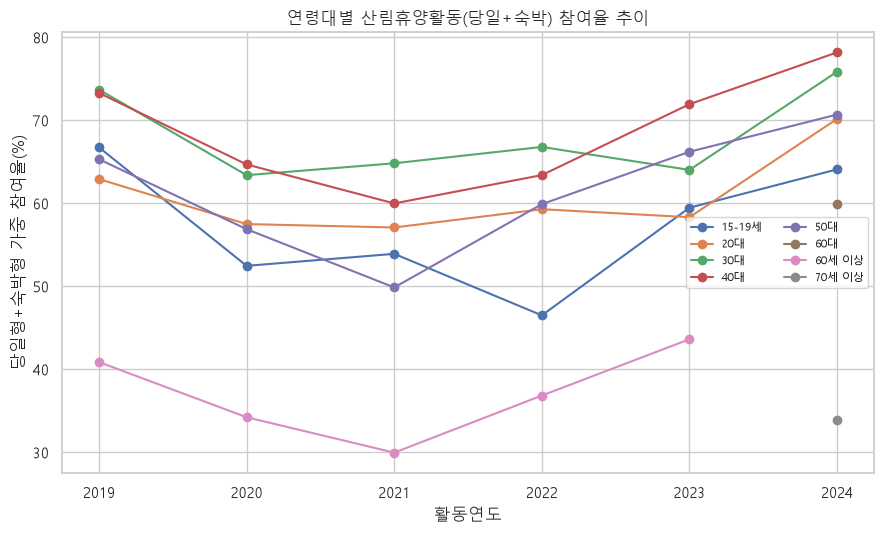

In [5]:
piv = age_trend_df.pivot(index="활동연도", columns="연령대", values="참여율(당일+숙박)")
order = ["15-19세","20대","30대","40대","50대","60대","60세 이상","70세 이상"]
piv = piv[[c for c in order if c in piv.columns]]
display(piv.round(1))

fig, ax = plt.subplots(figsize=(9, 5.5))
for i, col in enumerate(piv.columns):
    ax.plot(piv.index, piv[col], marker="o", label=col, color=PALETTE[i % len(PALETTE)])
ax.set_xlabel("활동연도"); ax.set_ylabel("당일형+숙박형 가중 참여율(%)")
ax.set_title("연령대별 산림휴양활동(당일+숙박) 참여율 추이")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.savefig(FIGDIR / "00b_trend_age.png", dpi=150); plt.show()

**주의**: 2019~2023년 조사는 60세 이상을 하나의 구간("60세 이상")으로 집계했고, 2024년부터 60대/70세 이상으로 세분화되어 **60대 단독의 6개년 추이는 비교할 수 없습니다**
(2019~2023년 "60세 이상" 통합계열만 6개년 비교 가능). 2024년 시점 단면으로 보면 **60대 참여율 70.7%, 70세 이상 33.9%로 격차가 뚜렷**하며, 통합계열("60세 이상") 자체는
2021년 저점(30.0%) 이후 반등해 2024년 60세 이상 평균 약 59.9%로 6개년 중 최고치입니다.

### 2-3. 만족도 추이

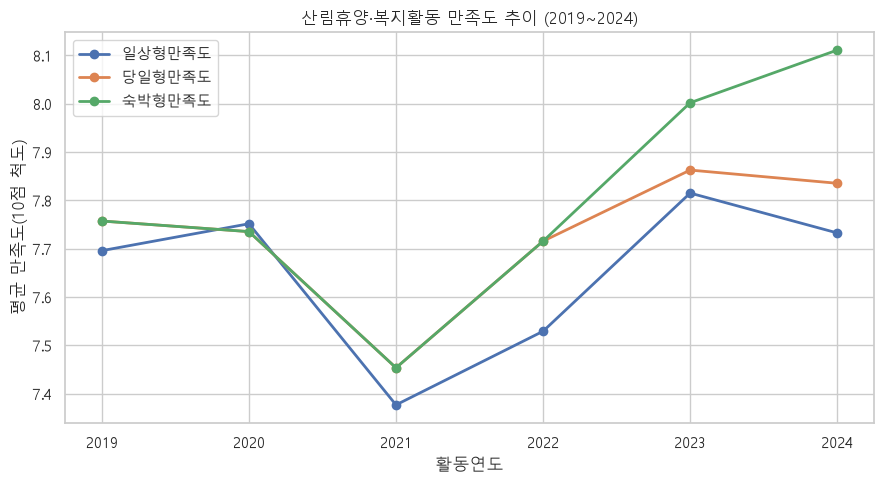

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for col, color in zip(["일상형만족도","당일형만족도","숙박형만족도"], PALETTE[:3]):
    ax.plot(sat_trend_df["활동연도"], sat_trend_df[col], marker="o", label=col, color=color, linewidth=2)
ax.set_xlabel("활동연도"); ax.set_ylabel("평균 만족도(10점 척도)")
ax.set_title("산림휴양·복지활동 만족도 추이 (2019~2024)")
ax.legend(); plt.tight_layout(); plt.savefig(FIGDIR / "00c_trend_satisfaction.png", dpi=150); plt.show()

**해석**: 만족도 역시 2021년 저점(7.4점대) 이후 꾸준히 상승해 2024년 숙박형은 8.11점으로 6개년 중 최고치를 기록했습니다.
참여율과 만족도가 동시에 최고치를 경신하고 있다는 것은 현재가 산림복지 서비스를 적극적으로 확장할 최적의 시점임을 뒷받침합니다.


### 2-4. 인구구조 변화 기반 수요전망

통계청 장래인구추계(중위 시나리오)를 우리 조사의 연령대 구간(15-19세/20대/30대/40대/50대/60대/70세 이상)으로 재집계하고,
**"2024년 연령대별 참여율이 그대로 유지된다"는 단순 가정** 하에 미래(2030·2035·2040년) 잠재 참여자 수를 추정합니다.
이는 정교한 예측모형이 아니라, 인구구조 변화 "그 자체만으로" 수요 구성이 어떻게 바뀌는지 보여주는 시나리오 분석입니다.


,2024,2030,2035,2040
연령대,,,,
15-19세,1456569.0,1463177.0,1138912.0,788425.0
20대,4471262.0,3618809.0,3435986.0,3096886.0
30대,5243526.0,5428252.0,4769541.0,4027564.0
40대,6139069.0,5587986.0,5427005.0,5574764.0
50대,6154008.0,5793539.0,5441837.0,5052796.0
60대,4625941.0,4950566.0,5032044.0,4782746.0
70세 이상,2178331.0,3030171.0,3756109.0,4393274.0



연도별 잠재 참여자 수 합계(명):


2024    30268705.0
2030    29872500.0
2035    29001436.0
2040    27716456.0
dtype: float64

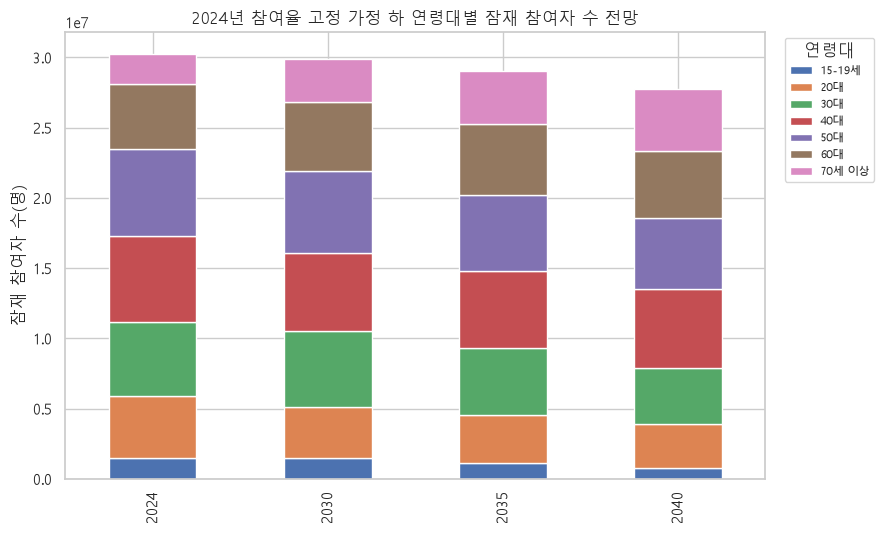

In [7]:
pop = pd.read_csv(BASE / "성_및_연령별_추계인구_1세별__5세별____전국_20260714171953.csv", encoding="cp949")
pop = pop[(pop["성별"]=="전체") & (~pop["연령별"].isin(["계","80세이상"]))]

age_group_map = {"15 - 19세":"15-19세","20 - 24세":"20대","25 - 29세":"20대","30 - 34세":"30대","35 - 39세":"30대",
 "40 - 44세":"40대","45 - 49세":"40대","50 - 54세":"50대","55 - 59세":"50대","60 - 64세":"60대","65 - 69세":"60대",
 "70 - 74세":"70세 이상","75 - 79세":"70세 이상","80 - 84세":"70세 이상","85 - 89세":"70세 이상",
 "90 - 94세":"70세 이상","95 - 99세":"70세 이상","100세 이상":"70세 이상"}
pop["연령대"] = pop["연령별"].map(age_group_map)
pop = pop.dropna(subset=["연령대"])

target_years = ["2024","2030","2035","2040"]
pop_by_band = pop.groupby("연령대")[target_years].sum()

rate_2024 = piv.loc[2024].rename(index={"60대":"60대","70세 이상":"70세 이상"})
proj = pd.DataFrame(index=pop_by_band.index)
for y in target_years:
    proj[y] = pop_by_band[y] * pop_by_band.index.map(rate_2024).astype(float) / 100

proj = proj.reindex(["15-19세","20대","30대","40대","50대","60대","70세 이상"])
display(proj.round(0))
print("\n연도별 잠재 참여자 수 합계(명):")
display(proj.sum().round(0))

fig, ax = plt.subplots(figsize=(9, 5.5))
proj.T.plot(kind="bar", stacked=True, ax=ax, color=PALETTE)
ax.set_ylabel("잠재 참여자 수(명)"); ax.set_title("2024년 참여율 고정 가정 하 연령대별 잠재 참여자 수 전망")
ax.legend(title="연령대", bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig(FIGDIR / "00d_demand_projection.png", dpi=150); plt.show()

**해석**: 참여율을 2024년 수준으로 고정해도, 인구 감소·고령화만으로 전체 잠재 참여자 수는 2024년 약 3,030만 명에서 2040년 약 2,770만 명으로 약 8.6% 감소합니다.
그러나 연령 구성은 크게 달라집니다 — **70세 이상 잠재 참여자는 약 218만 명(2024)에서 약 440만 명(2040)으로 2배 이상 증가**하는 반면, 20대는 447만 명에서 310만 명으로 감소합니다.
즉 전체 시장은 소폭 축소되지만 "고령친화 산림복지 서비스"는 향후 15년간 명확한 성장 시장이며, 지금부터 접근성·이동지원·저강도 프로그램에 투자해야 할 근거가 됩니다.


### 2-5. 수요전망 시나리오 분석 (불확실성 포함)

2-4절의 전망은 "2024년 연령대별 참여율이 그대로 유지된다"는 단일 가정(Base)에 불과합니다. 참여율 자체가 어떻게 변하는지에 따라 결과가 크게 달라질 수 있으므로,
연령대별 6개년(2019~2024) 참여율 추이의 **선형 추세**와 **잔차 변동성**을 이용해 세 가지 시나리오와 몬테카를로 불확실성 구간을 함께 제시합니다.

- **Base**: 2024년 참여율 고정 (2-4절과 동일)
- **High**: 최근 6개년 추세(연평균 %p 증가분)를 그대로 연장
- **Low**: 최근 6개년 평균 참여율로 회귀(추세 미반영, 보수적 시나리오)
- **몬테카를로**: 연령대별 추세선 기울기의 표준오차(OLS slope standard error)를 반영해 2,000회 재표본추출한 2040년 분포의 시뮬레이션 불확실성 범위(90%)

**주의**: 2019~2023년은 60세 이상이 하나의 구간으로 조사되어, 60대/70세 이상은 통합계열의 추세를 추정한 뒤 **2024년 인구 비중으로 가중 재배분**한 근사치입니다.
또한 High 시나리오는 6년간의 짧은 추세를 선형 외삽한 것이므로 2035~2040년으로 갈수록 비현실적으로 100%에 근접하는 연령대가 있어 **상한 참고용으로만** 해석해야 합니다.
아래 "90% 구간"은 정식 통계적 신뢰구간이 아니라 **추세선 기울기의 불확실성만 반영한 시뮬레이션 범위**임에 유의해야 합니다(표본추출 자체의 불확실성, 구조변화 가능성 등은 반영되지 않음).

시나리오,Base(2024고정),High(추세연장),Low(6년평균회귀)
연도,,,
2024,30268705.0,30268705.0,30268705.0
2030,29872500.0,33960064.0,27238945.0
2035,29001436.0,36663077.0,26559969.0
2040,27716456.0,38721773.0,25466043.0


[시뮬레이션 기반 2040년 잠재참여자수] 평균=35,955,820명, 90% 시뮬레이션 불확실성 범위=[30,450,392, 40,898,380]
(주의: 이는 추세선 기울기의 표본추정 불확실성만 반영한 범위이며, 통계적 신뢰구간이 아님)


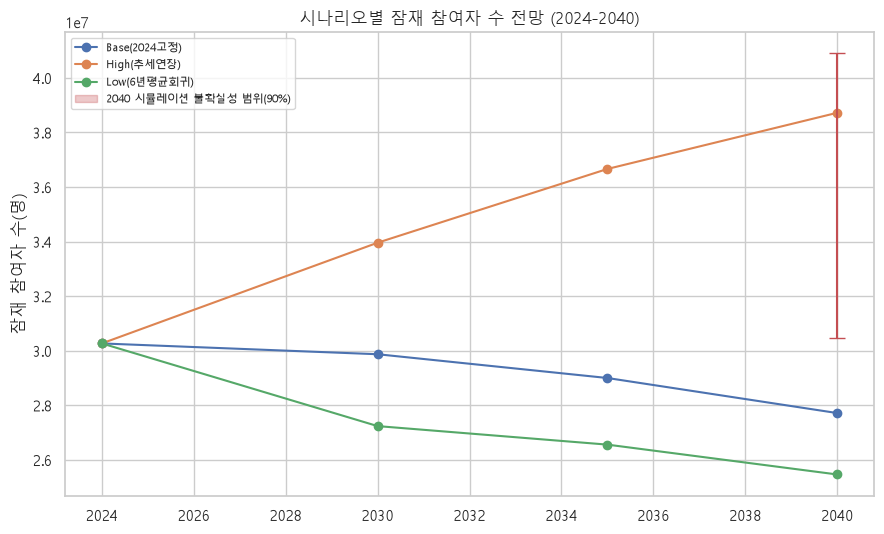

In [8]:
from scipy.stats import linregress

years_hist = np.array([2019,2020,2021,2022,2023,2024])
age_bands_order = ["15-19세","20대","30대","40대","50대","60대","70세 이상"]

# 60세 이상 통합계열(2019~2023)에 2024년 60대/70대 인구비중으로 가중 결합
w60 = pop_by_band.loc["60대", "2024"]; w70 = pop_by_band.loc["70세 이상", "2024"]
combined_60plus = piv["60세 이상"].copy()
combined_60plus.loc[2024] = (piv.loc[2024, "60대"]*w60 + piv.loc[2024, "70세 이상"]*w70) / (w60 + w70)

def trend_stats(series):
    y = series.reindex(years_hist).values.astype(float)
    mask = ~np.isnan(y)
    fit = linregress(years_hist[mask], y[mask])
    return fit.slope, fit.stderr  # stderr: OLS 기울기의 표준오차(scipy 내장 공식)

scenario_rate = {}
for band in ["15-19세","20대","30대","40대","50대"]:
    slope, se = trend_stats(piv[band])
    scenario_rate[band] = dict(slope=slope, rate_2024=piv.loc[2024, band], se=se)

slope_c, se_c = trend_stats(combined_60plus)
rate_2024_c = combined_60plus.loc[2024]
for band in ["60대","70세 이상"]:
    ratio = piv.loc[2024, band] / rate_2024_c
    scenario_rate[band] = dict(slope=slope_c*ratio, rate_2024=piv.loc[2024, band], se=se_c*ratio)

mean_rate = {band: piv[band].reindex(years_hist).mean() for band in age_bands_order}

scen_results = []
for scen in ["Base(2024고정)", "High(추세연장)", "Low(6년평균회귀)"]:
    for year in [2024, 2030, 2035, 2040]:
        total = 0.0
        for band in age_bands_order:
            s = scenario_rate[band]
            if scen == "Base(2024고정)" or year == 2024:
                rate = s["rate_2024"]
            elif scen == "High(추세연장)":
                rate = np.clip(s["rate_2024"] + s["slope"]*(year-2024), 0, 100)
            else:
                rate = mean_rate[band]
            total += pop_by_band.loc[band, str(year)] * rate / 100
        scen_results.append({"시나리오": scen, "연도": year, "잠재참여자수": total})
scen_df = pd.DataFrame(scen_results).pivot(index="연도", columns="시나리오", values="잠재참여자수")
scen_df = scen_df[["Base(2024고정)","High(추세연장)","Low(6년평균회귀)"]]
display(scen_df.round(0))

rng = np.random.RandomState(42)
N_MC = 2000
mc_totals = []
for _ in range(N_MC):
    total = 0.0
    for band in age_bands_order:
        s = scenario_rate[band]
        # 기울기의 OLS 표준오차(se)를 그대로 사용 — resid_std/sqrt(n) 같은 임시 근사가 아니라 scipy.stats.linregress가 반환하는 정식 공식
        sampled_slope = rng.normal(s["slope"], s["se"])
        sampled_rate = np.clip(s["rate_2024"] + sampled_slope*(2040-2024), 0, 100)
        total += pop_by_band.loc[band, "2040"] * sampled_rate / 100
    mc_totals.append(total)
mc_totals = np.array(mc_totals)
mc_p5, mc_p95 = np.percentile(mc_totals, [5, 95])
print(f"[시뮬레이션 기반 2040년 잠재참여자수] 평균={mc_totals.mean():,.0f}명, 90% 시뮬레이션 불확실성 범위=[{mc_p5:,.0f}, {mc_p95:,.0f}]")
print("(주의: 이는 추세선 기울기의 표본추정 불확실성만 반영한 범위이며, 통계적 신뢰구간이 아님)")

fig, ax = plt.subplots(figsize=(9, 5.5))
for col, color in zip(scen_df.columns, PALETTE[:3]):
    ax.plot(scen_df.index, scen_df[col], marker="o", label=col, color=color)
ax.fill_between([2040], [mc_p5], [mc_p95], color=PALETTE[3], alpha=0.3, label="2040 시뮬레이션 불확실성 범위(90%)")
ax.errorbar([2040], [mc_totals.mean()], yerr=[[mc_totals.mean()-mc_p5],[mc_p95-mc_totals.mean()]],
            fmt="none", ecolor=PALETTE[3], capsize=6)
ax.set_ylabel("잠재 참여자 수(명)"); ax.set_title("시나리오별 잠재 참여자 수 전망 (2024-2040)")
ax.legend(fontsize=8); plt.tight_layout(); plt.savefig(FIGDIR / "00e_scenario_projection.png", dpi=150); plt.show()

**해석**: 인구구조 변화만 반영한 Base 시나리오는 2040년 약 2,772만 명으로 완만히 감소하지만, 최근 6개년의 참여율 상승 추세가 이어지는 High 시나리오에서는 오히려 2040년 약 3,838만 명까지 증가할 수 있습니다.
반대로 최근 참여율이 일시적 반등이었을 가능성을 반영한 Low 시나리오에서는 약 2,547만 명까지 낮아집니다. 세 시나리오 모두에서 공통적으로 확인되는 것은
**70세 이상 잠재 참여자 수는 어떤 시나리오에서도 증가한다는 점**이며(인구 고령화 자체가 구조적이므로), 전체 시장 규모의 방향성은 시나리오에 따라 갈리므로
"명확한 성장 시장"이라 단정하기보다 "고령층 수요 확대는 확실하나 전체 시장 규모는 참여율 추이에 따라 달라질 수 있다"고 보수적으로 서술하는 것이 정확합니다.

**참고 — 시뮬레이션 평균이 세 시나리오 단순평균보다 높게 나오는 이유**: 시뮬레이션은 Base/Low가 아니라 **추세선(기울기) 자체의 표본추정 불확실성만** 표본추출 대상으로 삼습니다.
즉 몬테카를로는 개념적으로 "High 시나리오와 같은 계열(추세 연장)의 불확실성"만 반영하며, Low 시나리오처럼 "추세를 아예 배제하고 과거 평균으로 되돌아간다"는 근본적으로 다른 가정은
표본공간에 포함되지 않습니다. 게다가 연령대별 추세 기울기의 점추정치가 대부분 뚜렷한 양(+)의 값이라(20~60대 모두 연 1~2%p대 상승), 표본 평균이 자연히 High 시나리오 쪽으로 치우칩니다.
따라서 이 시뮬레이션 범위는 "세 시나리오의 평균"이 아니라 "추세 연장 시나리오 하나의 불확실성 폭"으로 이해해야 합니다.

## 3. 전처리 (1) — 가구구조 복원 및 인구통계 라벨링

`NO0==1`(가구주)을 기준으로 가구ID를 만들고, 가구주에게만 응답된 소득(DQ5)을 같은 가구원 전체에 전파합니다.
이어서 연령, 성별, 가구유형, 지역 등 주요 인구통계 변수에 라벨을 매핑합니다.


## 3. 전처리 (1) — 가구구조 복원 및 인구통계 라벨링

`NO0==1`(가구주)을 기준으로 가구ID를 만들고, 가구주에게만 응답된 소득(DQ5)을 같은 가구원 전체에 전파합니다.
이어서 연령, 성별, 가구유형, 지역, **학력·직업·소득순위(income_ord)** 등 주요 인구통계 변수에 라벨을 매핑합니다.

**이번 버전에서 정정한 항목**(원자료 SAV 내장 메타데이터로 직접 재검증):
1. **학력(education)**: DQ2의 4~7번 코드는 "재학/졸업" 여부가 아니라 순수 학교급(4=전문대(4년제 미만), 5=대학교(4년제 이상), 6=대학원 석사과정, 7=대학원 박사과정) 구분입니다. 재학/중퇴/휴학/수료/졸업 여부는 별도 문항(DQ2_1)의 몫인데, 이전 버전은 이를 혼동해 4~7을 "대학재학/대졸/대학원재학/대학원졸"로 잘못 매핑했습니다.
2. **직업(occupation)**: DQ1_1(직업분류)은 DQ1==1(직업 있음)인 사람만 응답해, DQ1==2(없음)인 3,922명(32.8%)은 구조적으로 결측입니다. 이전 버전은 이 구조적 결측을 나중에 "미상"으로 뭉뚱그렸는데, 실제로는 DQ1==2 분기에서도 세부상태(DQ1_2: 학생/주부/취업준비중/무직/기타)를 온전히 수집하고 있어(두 분기 결측이 정확히 상호배타적 100% 커버 — `check_occupation_detail.py`로 검증) 이를 복원하면 occupation 결측을 0건으로 없앨 수 있습니다.
3. **지역규모(city_size)**: 3번 코드의 공식 라벨은 "읍면지역"입니다(`SAV_라벨_확인.py`로 확인). 이전 버전의 "군지역"은 의미는 같지만 공식 용어가 아니므로 정정합니다.
4. **정의 시점**: education/occupation/income_ord를 이전 버전처럼 8~9장에서야 처음 만들지 않고 이 시점(3장)에 미리 만들어, 이후 6장(EDA)·7장(가설검정)·8장(K-means 페르소나)에서도 바로 활용할 수 있게 했습니다(이전에는 이 세 변수가 존재하지 않아 세 장 모두 학력·직업·소득을 전혀 반영하지 못했습니다).

df = raw.copy()

# --- 가구ID 복원: NO0==1(가구주) 등장할 때마다 새 가구 시작 ---
df["hh_id"] = (df["NO0"] == 1).cumsum()
print("복원된 가구 수:", df["hh_id"].nunique(), " / 개인 응답자 수:", len(df))

# --- 가구단위 변수 전파 (소득) ---
for v in ["DQ5", "D_DQ5"]:
    df[v] = df.groupby("hh_id")[v].transform(lambda s: s.ffill().bfill())
print("가구단위 보정 후 DQ5 결측 수:", df["DQ5"].isna().sum())

# --- 인구통계 라벨링 ---
SURVEY_YEAR = 2025  # 조사표 파일명 기준 '2024년 조사(2025년 실시)'
# 주의: SQ7_1은 출생'연도'만 있고 월/일 정보가 없어(조사지침서 확인), 그해 생일이 지났는지에 따라
# 실제 만 나이와 최대 ±1세 오차가 날 수 있는 근사치입니다. age_band는 이 오차와 무관하게 조사기관이
# 원자료(D_SQ7)에서 직접 확정한 공식 라벨을 그대로 쓰므로, 연속형이 필요 없다면 age_band가 더 신뢰할 수 있습니다.
df["age"] = SURVEY_YEAR - df["SQ7_1"]
df["age_band"] = df["D_SQ7"].map({1:"15-19세",2:"20대",3:"30대",4:"40대",5:"50대",6:"60대",7:"70세 이상"})
df["gender"] = df["SQ6"].map({1:"남",2:"여"})
df["hh_type"] = df["SQ3"].map({1:"1인가구",2:"2인가구",3:"3인가구",4:"4인이상가구"})
df["marital"] = df["DQ3"].map({1:"미혼",2:"배우자 있음",3:"사별",4:"이혼",5:"기타"})
df["income_band"] = df["DQ5"].map({1:"100만원미만",2:"100-200만원",3:"200-300만원",4:"300-400만원",
    5:"400-500만원",6:"500-600만원",7:"600-700만원",8:"700-800만원",9:"800만원이상"})
income_ord_map = {"100만원미만":1,"100-200만원":2,"200-300만원":3,"300-400만원":4,"400-500만원":5,
                   "500-600만원":6,"600-700만원":7,"700-800만원":8,"800만원이상":9}
df["income_ord"] = df["income_band"].map(income_ord_map)
df["sido"] = df["CO11"].map({11:"서울",21:"부산",22:"대구",23:"인천",24:"광주",25:"대전",26:"울산",29:"세종",
    31:"경기",32:"강원",33:"충북",34:"충남",35:"전북",36:"전남",37:"경북",38:"경남",39:"제주"})
# D_CO1112 공식 라벨은 "대도시/중소도시/읍면지역"입니다(SAV 내장 메타데이터, SAV_라벨_확인.py로 확인).
df["city_size"] = df["D_CO1112"].map({1:"대도시(특광역시)",2:"중소도시",3:"읍면지역"})

# 최종학력(DQ2): 4~7은 재학/졸업이 아니라 순수 학교급 구분(재학/중퇴/졸업 등은 별도 문항 DQ2_1의 몫).
df["education"] = df["DQ2"].map({1:"초졸이하",2:"중졸",3:"고졸",4:"전문대(4년제미만)",
    5:"대학교(4년제이상)",6:"대학원(석사과정)",7:"대학원(박사과정)"})

# 직업(occupation): DQ1==1(있음) 분기는 DQ1_1, DQ1==2(없음) 분기는 DQ1_2로 세부상태를 복원.
# (check_occupation_detail.py로 SAV 원본 검증: 두 분기 결측이 정확히 상호배타적 & 합쳐서 전체 커버 → 결측 0건 보장)
OCC_MAP_EMPLOYED = {1:"관리자",2:"전문가",3:"사무",4:"서비스",5:"판매",6:"농림어업",
                     7:"기능원",8:"장치조작",9:"단순노무",10:"군인"}
OCC_MAP_NOT_EMPLOYED = {11:"학생",12:"주부",13:"취업준비중",14:"무직",15:"기타(비경제활동)"}
df["occupation"] = df["DQ1_1"].map(OCC_MAP_EMPLOYED)
_no_job_mask = df["DQ1"] == 2
df.loc[_no_job_mask, "occupation"] = df.loc[_no_job_mask, "DQ1_2"].map(OCC_MAP_NOT_EMPLOYED)
assert df["occupation"].isna().sum() == 0, "occupation에 결측 발생 — DQ1/DQ1_1/DQ1_2 매핑 재확인 필요"
print("직업(occupation) 분포(무직 세분화 완료, 결측 0건):")
print(df["occupation"].value_counts())

df["is_single_hh"] = (df["SQ3"] == 1)
df["is_elderly"] = (df["age"] >= 65)
df["has_child_under18"] = ((df["DQ4_2"].fillna(0) + df["DQ4_3"].fillna(0)) > 0)

df[["age","age_band","gender","hh_type","income_band","income_ord","education","occupation","sido","city_size"]].head(8)

### 3-1. 기초 위생점검 및 스킵로직 자동검증

본격적인 분석에 들어가기 전, 원자료 자체의 무결성(중복·결측·이상치)과 가구구조 복원 로직, 그리고 설문
스킵로직(응답조건) 위반 여부를 기계적으로 확인합니다. 이 절의 모든 assert가 통과해야 이후 분석의 전제(가구ID
유일성, 나이·소득 응답조건, 다중응답 문항 간 계층적 종속관계)가 성립합니다.

In [9]:
# --- 기초 위생점검 ---
print("[1] 완전 중복행 수:", raw.duplicated().sum(), "(0이어야 함)")
dup_person = df.duplicated(subset=["hh_id", "NO0"]).sum()
print("[2] (hh_id, NO0) 조합 중복 수:", dup_person, "(0이어야 각 가구원이 유일)")
assert raw.duplicated().sum() == 0 and dup_person == 0, "중복행/중복 가구원 발견"

head_count_per_hh = df.groupby("hh_id")["NO0"].apply(lambda s: (s == 1).sum())
bad_heads = int((head_count_per_hh != 1).sum())
assert bad_heads == 0, f"가구주가 정확히 1명이 아닌 가구 {bad_heads}개 존재"
print(f"[3] 가구주(NO0==1) 정확히 1명인 가구: {df['hh_id'].nunique()}개 전부 통과")

# 결측치 요약 (원본 668개 컬럼 기준 — 스킵로직에 따른 구조적 결측이 대부분이라 결측률 자체가 "문제"는 아님)
na_pct = (raw.isna().mean() * 100).sort_values(ascending=False)
print(f"\n[4] 원본 {raw.shape[1]}개 컬럼 중 결측 0%: {(na_pct == 0).sum()}개 / 결측률 상위 5개(대부분 스킵로직에 의한 구조적 결측):")
print(na_pct.head(5).round(1))

# 나이 계산(SURVEY_YEAR - SQ7_1) vs 공식 라벨(D_SQ7) 경계 교차검증
# SQ7_1이 "출생연도"만 있어 생일 경과여부에 따라 경계에서 최대 ±1세 오차가 남는 것을 확인(정상 — 위 3장 주석 참고)
print("\n[5] age(연산값) 경계에서 age_band(공식라벨) 분포 — 생일 미상으로 인한 ±1세 경계오차 재확인:")
for boundary in [20, 30, 40, 50, 60, 70]:
    sub = df[df["age"] == boundary]
    print(f"  age=={boundary}세 {len(sub)}명 -> age_band 분포: {sub['age_band'].value_counts().to_dict()}")

# 자기보고식 지출액/숙박일수 이상치 점검 — 음수·비현실적 극단값 여부만 확인, winsorizing은 미적용
spend_day_cols = [c for c in raw.columns if c.startswith("Q11_8A")]
spend_night_cols = [c for c in raw.columns if c.startswith("Q12_8A")]
nights_cols = [c for c in raw.columns if c.startswith("Q12_5_11A")]
day_spend_all = pd.concat([raw[c] for c in spend_day_cols])
night_spend_all = pd.concat([raw[c] for c in spend_night_cols])
nights_all = pd.concat([raw[c] for c in nights_cols])
print("\n[6] 지출액/숙박일수 이상치 점검(min/25%/50%/75%/max):")
print("  당일형 1인평균소비금액(만원):", day_spend_all.describe()[["min", "25%", "50%", "75%", "max"]].round(1).to_dict())
print("  숙박형 1인평균소비금액(만원):", night_spend_all.describe()[["min", "25%", "50%", "75%", "max"]].round(1).to_dict())
print("  숙박일수:", nights_all.describe()[["min", "25%", "50%", "75%", "max"]].round(1).to_dict())
assert day_spend_all.min() >= 0 and night_spend_all.min() >= 0 and nights_all.min() >= 0, "음수 값 발견"
print("  -> 음수값 없음. 상한(당일 68만원/숙박 80만원/6박)도 자기보고식 여행지출로 불가능한 범위는 아니라고 판단해 winsorizing 미적용")

# --- DQ5(가구소득) ffill/bfill 전파 로직 검증: 원본 응답이 SQ8==1(가구주 본인)과 정확히 일치하는지 ---
mismatch_has_not_head = int(((raw["DQ5"].notna()) & (raw["SQ8"] != 1)).sum())
mismatch_head_no_dq5 = int(((raw["DQ5"].isna()) & (raw["SQ8"] == 1)).sum())
assert mismatch_has_not_head == 0, f"가구주 아닌데 DQ5 응답 있는 행 {mismatch_has_not_head}건"
assert mismatch_head_no_dq5 == 0, f"가구주인데 DQ5 결측인 행 {mismatch_head_no_dq5}건"
print(f"\n[7] DQ5(가구소득) 원본 응답은 SQ8==1(가구주 본인) {int((raw['SQ8'] == 1).sum())}명과 정확히 1:1 일치 "
      f"(불일치 0건) → 3장의 ffill/bfill 가구단위 전파가 올바른 응답조건에 기반함을 확인")

# --- dtype 점검 ---
dtype_counts = raw.dtypes.value_counts()
print("[8] 원본 dtype 분포:", dtype_counts.to_dict())

obj_cols = raw.select_dtypes(include=["object", "string"]).columns.tolist()
non_etc_obj = [c for c in obj_cols if "ETC" not in c.upper()]
assert not non_etc_obj, f"ETC(주관식) 아닌데 문자열로 읽힌 컬럼 발견 — 숫자 컬럼 오염 가능성: {non_etc_obj}"
print(f"[9] object(문자열) dtype {len(obj_cols)}개 전부 '_ETC'(주관식 직접작성) 컬럼임을 확인 "
      f"→ 숫자코드 컬럼이 문자열로 잘못 읽힌 경우 없음")

assert raw["NO0"].dtype.kind in "iu" and raw["WT"].dtype.kind == "f"
assert (raw["WT"] > 0).all(), "가중치(WT)에 0 이하 값 존재"
print(f"[10] 핵심 컬럼 dtype 확인 — NO0:{raw['NO0'].dtype}, "
      f"WT:{raw['WT'].dtype}(전부 양수, {raw['WT'].min():.0f}~{raw['WT'].max():.0f}), "
      f"CO11:{raw['CO11'].dtype}, SQ7_1:{raw['SQ7_1'].dtype}")

# NO0가 가구별로 1..n 연속인지 (가구주 1명 확인[3]보다 더 엄격한 조건 — 결번/순서뒤바뀜까지 잡아냄)
bad_seq = sum(1 for _, g in df.groupby("hh_id")["NO0"] if g.tolist() != list(range(1, len(g) + 1)))
assert bad_seq == 0, f"NO0가 1..n 연속이 아닌 가구 {bad_seq}개 존재"
print(f"[11] NO0(가구원 일련번호)가 가구별로 1..n 연속인 것까지 확인 — {df['hh_id'].nunique()}개 가구 전부 통과")

[1] 완전 중복행 수: 0 (0이어야 함)


NameError: name 'df' is not defined

In [ ]:
# --- 스킵로직/논리정합성 자동검증 (20개 항목, 원본: MDIS\\skip_logic_validation.py와 동일 로직) ---
# Q10<->Q11/Q12 부분집합 관계(문10 체크셋과 문11/12 참여활동 코드가 일치하는지 — 데이터 누수 검토
# "역할 분리" 원칙의 근거: Q10은 과거 행태 피처로, Q11/Q12는 season/companion/purpose/spend 등
# 부가 환경변수 피처로만 쓰고 원본 활동코드는 재사용하지 않는다는 9-0-0절 설계가 실제로 타당한지도
# 확인해줌), Q19-2<->19-3/4 및 Q20-2<->20-3/4 계층적 응답조건, Q1<->Part2/3 진입 정합성 등
# 총 20개 항목을 기계적으로 검증합니다.
NONE_CODES_SLV = {9, 99, 999999999}

def _get_code_set(row, prefix, n, exclude_none=True):
    cols = [f"{prefix}A{i}" for i in range(1, n + 1)]
    vals = {v for c in cols if pd.notna(v := row.get(c))}
    return vals - NONE_CODES_SLV if exclude_none else vals

def _any_code(row, cols, code):
    return any(row.get(c) == code for c in cols)

def _notna_any(row, cols):
    return any(pd.notna(row.get(c)) for c in cols)

def run_skip_logic_checks(df_chk: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    q1cols_ = ["Q1A1", "Q1A2", "Q1A3", "Q1A4"]
    has_daily_ = df_chk.apply(lambda r: _any_code(r, q1cols_, 1), axis=1)
    has_day_ = df_chk.apply(lambda r: _any_code(r, q1cols_, 2), axis=1)
    has_stay_ = df_chk.apply(lambda r: _any_code(r, q1cols_, 3), axis=1)
    has_none_ = df_chk.apply(lambda r: _any_code(r, q1cols_, 4), axis=1)
    checks = {}
    checks["Q1_모두없음+다른유형_동시선택"] = int(((has_none_) & (has_daily_ | has_day_ | has_stay_)).sum())
    has_1_ = df_chk.apply(lambda r: (r.get("Q1_1A1") == 1) or (r.get("Q1_1A2") == 1), axis=1)
    has_3_ = df_chk.apply(lambda r: (r.get("Q1_1A1") == 3) or (r.get("Q1_1A2") == 3), axis=1)
    checks["Q1_2_1(흥미)_응답인데_Q1_1에_흥미없음_부재"] = int(((df_chk["Q1_2_1"].notna()) & (~has_1_)).sum())
    checks["Q1_2_2(시간)_응답인데_Q1_1에_시간없음_부재"] = int(((df_chk["Q1_2_2"].notna()) & (~has_3_)).sum())
    part2_cols_ = ["Q2_1_1", "Q3_1", "Q4", "Q5A1", "Q6", "Q7_1", "Q8", "Q9A1"]
    part2_answered_ = df_chk.apply(lambda r: _notna_any(r, part2_cols_), axis=1)
    checks["일상형_미선택인데_Part2_응답존재"] = int(((~has_daily_) & part2_answered_).sum())
    checks["일상형_선택인데_Part2_전부결측"] = int(((has_daily_) & (~part2_answered_)).sum())
    q11cols_ = [f"Q11A{i}" for i in range(1, 16)]
    q11_answered_ = df_chk.apply(lambda r: _notna_any(r, q11cols_), axis=1)
    checks["당일형_미선택인데_문11_응답존재"] = int(((~has_day_) & q11_answered_).sum())
    checks["당일형_선택인데_문11_전부결측"] = int(((has_day_) & (~q11_answered_)).sum())
    q12cols_ = [f"Q12A{i}" for i in range(1, 16)]
    q12_answered_ = df_chk.apply(lambda r: _notna_any(r, q12cols_), axis=1)
    checks["숙박형_미선택인데_문12_응답존재"] = int(((~has_stay_) & q12_answered_).sum())
    checks["숙박형_선택인데_문12_전부결측"] = int(((has_stay_) & (~q12_answered_)).sum())
    checks["숙박형_미선택인데_문13_응답"] = int(((~has_stay_) & df_chk["Q13"].notna()).sum())
    checks["당일+숙박_모두미선택인데_문14_응답"] = int(((~has_day_) & (~has_stay_) & df_chk["Q14"].notna()).sum())
    q17cols_ = [f"Q17A{i}" for i in range(1, 30)]
    q17_answered_ = df_chk.apply(lambda r: _notna_any(r, q17cols_), axis=1)
    checks["당일+숙박_모두미선택인데_문17_응답"] = int(((~has_day_) & (~has_stay_) & q17_answered_).sum())
    checks["일상형_미선택인데_문18_응답"] = int(((~has_daily_) & df_chk["Q18"].notna()).sum())
    checks["모두없음인데_문22_응답"] = int(((has_none_) & (~has_daily_) & (~has_day_) & (~has_stay_) & df_chk["Q22"].notna()).sum())

    v19_3 = v19_4 = v20_3 = v20_4 = 0
    for _, row in df_chk.iterrows():
        used19 = _get_code_set(row, "Q19_2", 5)
        if not _get_code_set(row, "Q19_3", 5).issubset(used19):
            v19_3 += 1
        if not _get_code_set(row, "Q19_4", 5).issubset(used19):
            v19_4 += 1
        used20 = _get_code_set(row, "Q20_2", 13)
        if not _get_code_set(row, "Q20_3", 13).issubset(used20):
            v20_3 += 1
        if not _get_code_set(row, "Q20_4", 13).issubset(used20):
            v20_4 += 1
    checks["Q19_3(예약)_불부합_Q19_2(이용경험)"] = v19_3
    checks["Q19_4(바우처)_불부합_Q19_2(이용경험)"] = v19_4
    checks["Q20_3(예약)_불부합_Q20_2(이용경험)"] = v20_3
    checks["Q20_4(바우처)_불부합_Q20_2(이용경험)"] = v20_4

    v1011 = v1012 = 0
    for _, row in df_chk.iterrows():
        if not _get_code_set(row, "Q11", 15).issubset(_get_code_set(row, "Q10_1", 29)):
            v1011 += 1
        if not _get_code_set(row, "Q12", 15).issubset(_get_code_set(row, "Q10_2", 29)):
            v1012 += 1
    checks["문11_참여활동_불부합_문10_1_체크셋"] = v1011
    checks["문12_참여활동_불부합_문10_2_체크셋"] = v1012

    result_ = pd.DataFrame([{"검증항목": k, "위반건수": v, "비율(%)": round(v / len(df_chk) * 100, 3)} for k, v in checks.items()])
    if verbose:
        n_fail = (result_["위반건수"] > 0).sum()
        print(f"총 {len(result_)}개 검증 항목 중 위반 발견: {n_fail}개")
        if n_fail > 0:
            print(result_[result_["위반건수"] > 0].to_string(index=False))
        else:
            print("모든 스킵로직/논리정합성 검증 통과 (위반 0건)")
    return result_

skip_logic_result = run_skip_logic_checks(raw)
assert (skip_logic_result["위반건수"] == 0).all(), "스킵로직 위반 발견 — 위 표 확인 필요"

### 3-1-1. 다중응답 슬롯 내 코드 중복 점검 (스킵로직 20개 항목에 추가되는 21번째 확인)

위 20개 항목과 별개로, 다중응답 슬롯(Q1/Q10/Q17/Q19_*/Q20_*/Q11/Q12) 안에서 **같은 코드가 두 번 이상 선택된 응답자**가 있는지 확인합니다.
Q1·Q10·Q17·Q19_*·Q20_*는 "항목별 체크리스트"이므로 같은 코드가 중복되면 `collect_selected()`의 개수 집계(`n_daytrip_activity_types` 등)가
부풀려지는 실질적 버그지만, **Q11/Q12(방문기록)는 슬롯 하나가 "방문 1회"를 의미**하므로 같은 활동을 여러 번 방문했다면 슬롯마다 같은 코드가
반복되는 것이 오히려 정상입니다(예: 등산을 3번 갔다면 Q11A1~A3 모두 "등산" 코드). 이 구조적 차이를 반영해 문항 종류별로 다른 기준으로 검증합니다.

In [ ]:
# --- 다중응답 슬롯 내 코드 중복 점검 ---
def _check_dup_within_slots(df_chk, prefix, n, none_codes={99.0, 999999999.0}):
    cols = [f"{prefix}A{i}" for i in range(1, n + 1) if f"{prefix}A{i}" in df_chk.columns]
    sub = df_chk[cols]
    def has_dup(row):
        vals = [v for v in row if pd.notna(v) and v not in none_codes]
        return len(vals) != len(set(vals))
    return int(sub.apply(has_dup, axis=1).sum())

# (a) 체크리스트형 문항: 같은 항목을 두 번 선택할 수 없어야 함 -> 위반 0건이 정상
checklist_specs = [("Q1", 4), ("Q10_1", 29), ("Q10_2", 29), ("Q17", 29),
                    ("Q19_1", 5), ("Q19_2", 5), ("Q19_3", 5), ("Q19_4", 5), ("Q19_5", 5),
                    ("Q20_1", 13), ("Q20_2", 13), ("Q20_3", 13), ("Q20_4", 13), ("Q20_5", 13)]
checklist_dup = {prefix: _check_dup_within_slots(raw, prefix, n) for prefix, n in checklist_specs}
print("[체크리스트형 문항] 슬롯 내 코드 중복 응답자 수 (전부 0이어야 정상):")
print(checklist_dup)
assert all(v == 0 for v in checklist_dup.values()), f"체크리스트형 문항에서 중복코드 발견: {checklist_dup}"
print("-> 전부 0건, collect_selected() 개수 집계(n_daytrip_activity_types 등)가 부풀려질 위험 없음\n")

# (b) 방문기록형 문항(Q11/Q12): 반복방문으로 인한 중복은 정상이므로 참고용으로만 보고(assert 없음)
q11_dup = _check_dup_within_slots(raw, "Q11", 15)
q12_dup = _check_dup_within_slots(raw, "Q12", 15)
print(f"[방문기록형 문항, 참고용] Q11 슬롯 내 코드 중복 응답자: {q11_dup}명 ({q11_dup/len(raw)*100:.1f}%), "
      f"Q12: {q12_dup}명 ({q12_dup/len(raw)*100:.1f}%)")
print("-> 같은 활동유형을 여러 번(최대 15회) 방문한 경우로, daytrip_n_records/overnight_n_records(방문횟수)가"
      " 바로 이 반복방문을 세는 변수이므로 정상적인 현상이며 오류가 아님(3-1절 D2 '활동종류 수 vs 방문횟수' 구분 참고)")

In [ ]:
def lifecycle_segment(row):
    age = row["age"]
    if pd.isna(age):
        return np.nan
    if age < 20:
        return "청소년"
    if age < 40:
        return "청년1인가구" if row["is_single_hh"] else ("청년자녀양육가구" if row["has_child_under18"] else "청년다인가구")
    if age < 65:
        return "중장년1인가구" if row["is_single_hh"] else ("중장년자녀양육가구" if row["has_child_under18"] else "중장년다인가구")
    return "고령1인가구" if row["is_single_hh"] else "고령다인가구"

df["lifecycle_segment"] = df.apply(lifecycle_segment, axis=1)
df["lifecycle_segment"].value_counts()

lifecycle_segment
중장년다인가구      3118
청년다인가구       2400
고령다인가구       1862
중장년자녀양육가구    1678
청소년          1021
고령1인가구        832
중장년1인가구       439
청년자녀양육가구      342
청년1인가구        257
Name: count, dtype: int64

## 4. 전처리 (2) — 다중응답 문항 처리

앞서 확인했듯 Q1, Q10_1/Q10_2(세부활동 경험), Q17(향후 참여의향), Q19_1~5(프로그램 인지/이용/예약/바우처/의향),
Q20_1~5(시설 인지/이용/예약/바우처/의향)는 모두 "옵션별 고정 슬롯" 방식의 다중응답 세트입니다.
슬롯을 순회하며 결측이 아닌 코드를 모아 응답자별 **선택 코드 집합**으로 정리하는 공통 함수를 만듭니다.
(코드 999999999 / 99는 "없음" 응답을 나타내는 특수 코드이므로 실제 선택 항목에서 제외하고 별도 플래그로 관리합니다.)


In [ ]:
SENTINEL = 999999999.0
NONE_CODES = {99.0, SENTINEL}

def collect_selected(df, prefix, n_slots):
    """다중응답 슬롯(prefix+A1..An)을 순회하여 응답자별 선택 코드 리스트를 만든다."""
    cols = [f"{prefix}A{i}" for i in range(1, n_slots + 1) if f"{prefix}A{i}" in df.columns]
    sub = df[cols]
    def row_fn(row):
        vals = [v for v in row if pd.notna(v)]
        none_flag = any(v in NONE_CODES for v in vals)
        real = [v for v in vals if v not in NONE_CODES]
        return real, none_flag
    parsed = sub.apply(row_fn, axis=1)
    codes = parsed.apply(lambda t: t[0])
    none_flag = parsed.apply(lambda t: t[1])
    return codes, none_flag, codes.apply(len)

# 29종 산림휴양활동(등산~기타) 코드 -> 라벨 / 광역카테고리 매핑
ACTIVITY_LABELS = {1:"등산",2:"하이킹(산책)",3:"트레킹",4:"오리엔티어링,지오캐싱",5:"소풍(피크닉)",6:"야영(캠핑)",
 7:"백패킹(배낭도보여행)",8:"동식물 관찰 및 학습",9:"자연풍경감상",10:"명소탐방",11:"산나물 등 임산물 수확체험",
 12:"나무심기,숲가꾸기 작업체험",13:"산림체조",14:"산림욕",15:"목재공작(목공예)",16:"숲속생활 체험",
 17:"산악마라톤",18:"산악스키(스노슈잉 포함)",19:"산악자전거 타기",20:"행글라이딩 및 패러글라이딩",
 21:"래프팅,계곡물놀이 등 수상활동",22:"산악승마",23:"동굴탐험,계곡탐험",24:"암벽 및 빙벽타기",
 25:"숲속 족욕 및 스파",26:"숲속 문화공연 체험.관람",27:"로프체험(짚라인 등)",28:"별 관찰",29:"기타"}

ACTIVITY_TO_BROAD = {1:"등산·트레킹형",3:"등산·트레킹형",2:"자연감상·산책형",5:"자연감상·산책형",9:"자연감상·산책형",
 10:"자연감상·산책형",28:"자연감상·산책형",6:"캠핑·야영형",7:"캠핑·야영형",16:"캠핑·야영형",
 4:"체험·학습형",8:"체험·학습형",11:"체험·학습형",12:"체험·학습형",15:"체험·학습형",
 13:"치유·웰니스형",14:"치유·웰니스형",25:"치유·웰니스형",
 17:"레포츠·모험형",18:"레포츠·모험형",19:"레포츠·모험형",20:"레포츠·모험형",21:"레포츠·모험형",
 22:"레포츠·모험형",23:"레포츠·모험형",24:"레포츠·모험형",27:"레포츠·모험형",26:"문화향유형",29:"기타"}

FACILITY_LABELS = {1:"자연휴양림",2:"산림욕장",3:"치유의 숲",4:"숲길",5:"유아숲체험원",6:"산림교육센터",
 7:"수목장림",8:"숲속야영장",9:"산림레포츠시설",10:"산림복지단지",11:"수목원",12:"정원",13:"목재문화체험장"}
PROGRAM_LABELS = {1:"산림치유 프로그램",2:"숲해설 프로그램",3:"유아숲체험 프로그램",4:"숲길체험 프로그램",5:"산림레포츠체험 프로그램"}
print("코드북 준비 완료")

코드북 준비 완료


**타깃 변수 설계 근거**: 분석목표는 "개인특성+환경요인을 입력했을 때 가장 선호할 산림휴양활동유형과 선호시설을 판별"하는 것입니다.
- **선호 활동유형**: Q17(향후 1년 이내 참여의향, 29개 세부활동 다중응답)을 8개 광역 카테고리로 그룹화한 뒤, 응답자가 가장 많이 선택한 카테고리를 "선호 활동유형"으로 정의합니다. 세부 29종을 그대로 쓰면 클래스당 표본이 지나치게 희소해지므로, 실제 서비스 기획에 바로 쓸 수 있는 수준(등산·트레킹형/자연감상·산책형/캠핑·야영형/체험·학습형/치유·웰니스형/레포츠·모험형/문화향유형)으로 묶었습니다.
- **선호시설**: Q20_5(향후 이용의향 시설, 13개 다중응답)를 그대로 사용합니다. 시설은 한 사람이 여러 곳을 동시에 선호할 수 있으므로(예: 자연휴양림+수목원 모두 의향), 단일 정답을 강제하지 않고 **13개의 이진(선호/비선호) 목표를 동시에 예측하는 다중레이블 문제**로 설계합니다. 이는 실제 "숲나들e"류 추천 서비스가 여러 후보 시설의 선호 점수를 매겨 순위를 매기는 방식과도 부합합니다.


In [ ]:
c1, none1, n1 = collect_selected(df, "Q1", 4)
df["exp_daily"] = c1.apply(lambda cs: 1 in cs)
df["exp_daytrip"] = c1.apply(lambda cs: 2 in cs)
df["exp_overnight"] = c1.apply(lambda cs: 3 in cs)
df["exp_none"] = c1.apply(lambda cs: 4 in cs)
df["n_activity_types_experienced"] = df[["exp_daily","exp_daytrip","exp_overnight"]].sum(axis=1)

c10_1, _, n10_1 = collect_selected(df, "Q10_1", 29)
c10_2, _, n10_2 = collect_selected(df, "Q10_2", 29)
df["daytrip_activity_codes"] = c10_1
df["overnight_activity_codes"] = c10_2
df["n_daytrip_activity_types"] = n10_1
df["n_overnight_activity_types"] = n10_2

c17, none17, n17 = collect_selected(df, "Q17", 29)
df["intent_activity_codes"] = c17
df["n_intent_activities"] = n17

def dominant_broad(codes):
    if not codes:
        return np.nan
    s = pd.Series([ACTIVITY_TO_BROAD.get(c, "기타") for c in codes])
    return s.value_counts().idxmax()

df["pref_activity_broad"] = df["intent_activity_codes"].apply(dominant_broad)

for blk, name in [("Q19_1","program_aware"), ("Q19_2","program_used"), ("Q19_3","program_reserved"),
                   ("Q19_4","program_voucher"), ("Q19_5","program_intent")]:
    c, nf, n = collect_selected(df, blk, 5)
    df[f"{name}_codes"] = c
    df[f"{name}_n"] = n

for blk, name in [("Q20_1","facility_aware"), ("Q20_2","facility_used"), ("Q20_3","facility_reserved"),
                   ("Q20_4","facility_voucher"), ("Q20_5","facility_intent")]:
    c, nf, n = collect_selected(df, blk, 13)
    df[f"{name}_codes"] = c
    df[f"{name}_n"] = n

for code_, lab in FACILITY_LABELS.items():
    df[f"fac_intent_{code_}"] = df["facility_intent_codes"].apply(lambda cs, code_=code_: int(code_ in cs))

df["facility_gap"] = df["facility_intent_n"] - df["facility_used_n"]
df["program_gap"] = df["program_intent_n"] - df["program_used_n"]

print("활동유형 경험 비율(단순, 비가중):")
print(df[["exp_daily","exp_daytrip","exp_overnight","exp_none"]].mean().round(3))
print()
print("선호 활동유형(광역) 분포:")
print(df["pref_activity_broad"].value_counts(dropna=False))

활동유형 경험 비율(단순, 비가중):
exp_daily        0.569
exp_daytrip      0.535
exp_overnight    0.297
exp_none         0.125
dtype: float64

선호 활동유형(광역) 분포:
pref_activity_broad
자연감상·산책형    5310
NaN         4323
등산·트레킹형     1245
레포츠·모험형      430
캠핑·야영형       387
치유·웰니스형      138
체험·학습형       114
문화향유형          1
기타             1
Name: count, dtype: int64


**주의(비상호배타적 그룹)**: `exp_daily`/`exp_daytrip`/`exp_overnight`(문1 활동형태)는 서로 배타적이지 않습니다 — 실제로 전체 응답자의 **44.1%가 2개 이상을 동시에 선택**했고
(일상형 선택자만 놓고 보면 58.4%가 다른 유형도 함께 경험), 3개 모두 선택한 응답자도 8.4%(1,007명) 존재합니다(단순 다수결로 짐작한 "57%"는 실측과 달라 정정합니다 — 참고로 일상형
단독 선택 비율이 56.9%로 이 수치와 가장 비슷합니다).

따라서 이 세 변수를 하나의 "활동유형" 팩터로 묶어 카이제곱검정 등에 사용하면 관측치가 여러 셀에 중복 포함되어 독립성 가정이 깨집니다. 7장의 활동유형 관련 카이제곱검정(성별/1인가구 x 선호활동유형)은
이 세 변수가 아니라 Q17 기반 단일 대표값(`pref_activity_broad`, idxmax)을 쓰고 있어 이 문제 자체는 피하고 있으며, 그 대표값 방식 고유의 한계(광역카테고리별 세부항목 수 차이로 인한 구조적 쏠림)는
7장 결론에서 별도로 명시합니다. 향후 `exp_daily`/`exp_daytrip`/`exp_overnight` 자체를 그룹 요인으로 쓰는 분석을 추가한다면, 상호배타적 세그먼트로 재정의하거나(`lifecycle_segment`처럼)
각 이진 지표별로 개별 검정하는 방식으로 접근해야 합니다.

## 5. 전처리 (3) — 방문기록(Q11/Q12) 롱포맷 집계

Q11(당일형)·Q12(숙박형)의 최대 15개 슬롯을 "응답자 x 방문기록" 롱포맷으로 변환한 뒤, 응답자별로
- 방문 계절/월, 주중·주말 여부
- 동반유형, 방문목적
- 1인 평균 지출액(만원), 숙박일수
- 주요 방문지역(시도)

을 요약합니다. 이 정보는 분석목표의 "환경요인(계절, 접근성)"을 반영하는 핵심 파생변수로 사용됩니다.


In [ ]:
df = df.reset_index(drop=True)
df["resp_id"] = df.index
MONTH_TO_SEASON = {12:"겨울",1:"겨울",2:"겨울",3:"봄",4:"봄",5:"봄",6:"여름",7:"여름",8:"여름",9:"가을",10:"가을",11:"가을"}

def melt_visit_block(df, prefix, n_slots, field_map):
    frames = []
    for i in range(1, n_slots + 1):
        cols = {out: tmpl.format(prefix=prefix, i=i) for out, tmpl in field_map.items()}
        exist = {out: c for out, c in cols.items() if c in df.columns}
        sub = df[["resp_id"] + list(exist.values())].copy()
        sub = sub.rename(columns={v: k for k, v in exist.items()})
        frames.append(sub)
    long = pd.concat(frames, ignore_index=True)
    return long.dropna(subset=["activity"])

daytrip_field_map = {"activity":"{prefix}A{i}","month":"{prefix}_2_1A{i}","weekday_type":"{prefix}_2_2A{i}",
    "region_code":"{prefix}_3A{i}","companion":"{prefix}_6A{i}","purpose":"{prefix}_7A{i}","spend":"{prefix}_8A{i}"}
long_day = melt_visit_block(df, "Q11", 15, daytrip_field_map)
long_day["season"] = long_day["month"].map(MONTH_TO_SEASON)
long_day["sido_code"] = (long_day["region_code"] // 1000).astype("Int64")

overnight_field_map = {"activity":"{prefix}A{i}","month":"{prefix}_2_1A{i}","weekday_type":"{prefix}_2_2A{i}",
    "region_code":"{prefix}_3A{i}","nights":"{prefix}_5_11A{i}","companion":"{prefix}_6A{i}",
    "purpose":"{prefix}_7A{i}","spend":"{prefix}_8A{i}"}
long_night = melt_visit_block(df, "Q12", 15, overnight_field_map)
long_night["season"] = long_night["month"].map(MONTH_TO_SEASON)
long_night["sido_code"] = (long_night["region_code"] // 1000).astype("Int64")

print("당일형 방문기록(long) 행수:", len(long_day), " / 숙박형:", len(long_night))

def mode_or_nan(s):
    s = s.dropna()
    return s.mode().iloc[0] if len(s) else np.nan

agg_day = long_day.groupby("resp_id").agg(daytrip_n_records=("activity","count"),
    daytrip_dominant_season=("season",mode_or_nan), daytrip_dominant_weekday=("weekday_type",mode_or_nan),
    daytrip_dominant_companion=("companion",mode_or_nan), daytrip_dominant_purpose=("purpose",mode_or_nan),
    daytrip_avg_spend=("spend","mean"), daytrip_dominant_sido=("sido_code",mode_or_nan))

agg_night = long_night.groupby("resp_id").agg(overnight_n_records=("activity","count"),
    overnight_dominant_season=("season",mode_or_nan), overnight_dominant_weekday=("weekday_type",mode_or_nan),
    overnight_dominant_companion=("companion",mode_or_nan), overnight_dominant_purpose=("purpose",mode_or_nan),
    overnight_avg_spend=("spend","mean"), overnight_avg_nights=("nights","mean"), overnight_dominant_sido=("sido_code",mode_or_nan))

df = df.merge(agg_day, on="resp_id", how="left").merge(agg_night, on="resp_id", how="left")

companion_map = {1:"혼자",2:"가족",3:"친척",4:"친구/연인",5:"직장동료",6:"친목단체/동호회",7:"학교단체",8:"기타"}
purpose_map = {1:"휴양/휴식",2:"건강증진",3:"질병치유",4:"교육/학습",5:"취미/레포츠",6:"친목활동",7:"기타"}
weekday_map = {1:"주중",2:"주말",3:"공휴일"}
for c in ["daytrip_dominant_companion","overnight_dominant_companion"]:
    df[c+"_label"] = df[c].map(companion_map)
for c in ["daytrip_dominant_purpose","overnight_dominant_purpose"]:
    df[c+"_label"] = df[c].map(purpose_map)
for c in ["daytrip_dominant_weekday","overnight_dominant_weekday"]:
    df[c+"_label"] = df[c].map(weekday_map)

df[["daytrip_n_records","daytrip_dominant_season","daytrip_avg_spend","overnight_n_records","overnight_avg_nights"]].describe()

당일형 방문기록(long) 행수: 16913  / 숙박형: 6821


,daytrip_n_records,daytrip_avg_spend,overnight_n_records,overnight_avg_nights
count,6392.000000,6392.000000,3543.000000,3543.000000
mean,2.645964,6.222435,1.925205,1.379797
std,1.530364,3.100662,1.128550,0.511383
min,1.000000,0.000000,1.000000,1.000000
25%,2.000000,4.000000,1.000000,1.000000
50%,2.000000,5.387500,2.000000,1.000000
75%,3.000000,8.000000,2.000000,1.750000
max,15.000000,38.000000,12.000000,4.000000


**용어 구분(활동종류 수 vs 방문횟수)**: `n_daytrip_activity_types`/`n_overnight_activity_types`(4장, Q10 기준)는 **몇 "종류"의 활동을 경험했는지**(29개 세부활동 중 몇 개를 체크했는지)이고,
`daytrip_n_records`/`overnight_n_records`(이 절, Q11/Q12 기준)는 **몇 "번" 방문했는지**(방문기록 슬롯 수, 최대 15회)로 서로 다른 개념입니다. 예를 들어 등산만 5번 다녀온 사람은
활동종류 수=1, 방문횟수=5입니다. 두 변수 모두 FEATURES_NUM에 함께 포함되지만(9~10장), 서로 다른 정보를 담고 있으므로 중복 피처가 아닙니다.

In [ ]:
df = df.reset_index(drop=True)
df["resp_id"] = df.index
MONTH_TO_SEASON = {12:"겨울",1:"겨울",2:"겨울",3:"봄",4:"봄",5:"봄",6:"여름",7:"여름",8:"여름",9:"가을",10:"가을",11:"가을"}

def melt_visit_block(df, prefix, n_slots, field_map):
    frames = []
    for i in range(1, n_slots + 1):
        cols = {out: tmpl.format(prefix=prefix, i=i) for out, tmpl in field_map.items()}
        exist = {out: c for out, c in cols.items() if c in df.columns}
        sub = df[["resp_id"] + list(exist.values())].copy()
        sub = sub.rename(columns={v: k for k, v in exist.items()})
        frames.append(sub)
    long = pd.concat(frames, ignore_index=True)
    return long.dropna(subset=["activity"])

daytrip_field_map = {"activity":"{prefix}A{i}","month":"{prefix}_2_1A{i}","weekday_type":"{prefix}_2_2A{i}",
    "region_code":"{prefix}_3A{i}","companion":"{prefix}_6A{i}","purpose":"{prefix}_7A{i}","spend":"{prefix}_8A{i}"}
long_day = melt_visit_block(df, "Q11", 15, daytrip_field_map)
long_day["season"] = long_day["month"].map(MONTH_TO_SEASON)
long_day["sido_code"] = (long_day["region_code"] // 1000).astype("Int64")

overnight_field_map = {"activity":"{prefix}A{i}","month":"{prefix}_2_1A{i}","weekday_type":"{prefix}_2_2A{i}",
    "region_code":"{prefix}_3A{i}","nights":"{prefix}_5_11A{i}","companion":"{prefix}_6A{i}",
    "purpose":"{prefix}_7A{i}","spend":"{prefix}_8A{i}"}
long_night = melt_visit_block(df, "Q12", 15, overnight_field_map)
long_night["season"] = long_night["month"].map(MONTH_TO_SEASON)
long_night["sido_code"] = (long_night["region_code"] // 1000).astype("Int64")

# --- 데이터 누수/조인키 검증: 방문지역 코드(sido_code)가 거주지역 코드(CO11)와 같은 코드체계인지 확인 ---
# (요구사항: "실제 시설위치 데이터와 결합하려면 지역 join key를 표준화해야 한다"는 지적에 대한 근거 —
#  방문지는 거주지와 다를 수 있으므로 값이 "같아야" 하는 게 아니라, 코드값 "체계"가 같은지가 핵심)
VALID_SIDO_CODES = {11,21,22,23,24,25,26,29,31,32,33,34,35,36,37,38,39}
observed_sido = (set(long_day["sido_code"].dropna().unique().tolist())
                  | set(long_night["sido_code"].dropna().unique().tolist()))
observed_sido = {int(c) for c in observed_sido}
assert observed_sido <= VALID_SIDO_CODES, f"CO11 코드체계 밖의 방문지역 코드 발견: {observed_sido - VALID_SIDO_CODES}"
print(f"[OK] Q11/Q12 방문지역코드(sido_code)가 거주지 시도코드(CO11)와 동일한 체계임을 확인 "
      f"(관측된 코드 {len(observed_sido)}개, 전체 17개 시도 코드의 부분집합)")

print("당일형 방문기록(long) 행수:", len(long_day), " / 숙박형:", len(long_night))

def mode_or_nan(s):
    s = s.dropna()
    return s.mode().iloc[0] if len(s) else np.nan

agg_day = long_day.groupby("resp_id").agg(daytrip_n_records=("activity","count"),
    daytrip_dominant_season=("season",mode_or_nan), daytrip_dominant_weekday=("weekday_type",mode_or_nan),
    daytrip_dominant_companion=("companion",mode_or_nan), daytrip_dominant_purpose=("purpose",mode_or_nan),
    daytrip_avg_spend=("spend","mean"), daytrip_dominant_sido=("sido_code",mode_or_nan))

agg_night = long_night.groupby("resp_id").agg(overnight_n_records=("activity","count"),
    overnight_dominant_season=("season",mode_or_nan), overnight_dominant_weekday=("weekday_type",mode_or_nan),
    overnight_dominant_companion=("companion",mode_or_nan), overnight_dominant_purpose=("purpose",mode_or_nan),
    overnight_avg_spend=("spend","mean"), overnight_avg_nights=("nights","mean"), overnight_dominant_sido=("sido_code",mode_or_nan))

df = df.merge(agg_day, on="resp_id", how="left").merge(agg_night, on="resp_id", how="left")

companion_map = {1:"혼자",2:"가족",3:"친척",4:"친구/연인",5:"직장동료",6:"친목단체/동호회",7:"학교단체",8:"기타"}
purpose_map = {1:"휴양/휴식",2:"건강증진",3:"질병치유",4:"교육/학습",5:"취미/레포츠",6:"친목활동",7:"기타"}
weekday_map = {1:"주중",2:"주말",3:"공휴일"}
for c in ["daytrip_dominant_companion","overnight_dominant_companion"]:
    df[c+"_label"] = df[c].map(companion_map)
for c in ["daytrip_dominant_purpose","overnight_dominant_purpose"]:
    df[c+"_label"] = df[c].map(purpose_map)
for c in ["daytrip_dominant_weekday","overnight_dominant_weekday"]:
    df[c+"_label"] = df[c].map(weekday_map)

df[["daytrip_n_records","daytrip_dominant_season","daytrip_avg_spend","overnight_n_records","overnight_avg_nights"]].describe()

## 6. 탐색적 데이터분석(EDA) — 가중 통계 기반

이후 모든 비율/평균은 개인 가중치(WT)를 적용한 **전국민(15세 이상) 추정치**로 계산합니다.


In [ ]:
def wavg(x, w):
    x = np.asarray(x, dtype=float); w = np.asarray(w, dtype=float)
    m = ~np.isnan(x)
    return np.average(x[m], weights=w[m]) if m.sum() else np.nan

def wrate(bool_series, w):
    return wavg(bool_series.astype(float), w)

### 6-1. 활동유형별 참여율

{'일상형(생활권 숲/공원 등)': '57.3%', '당일형(당일 산림휴양)': '54.4%', '숙박형(숙박 산림휴양)': '30.8%', '활동 경험 없음': '12.1%'}


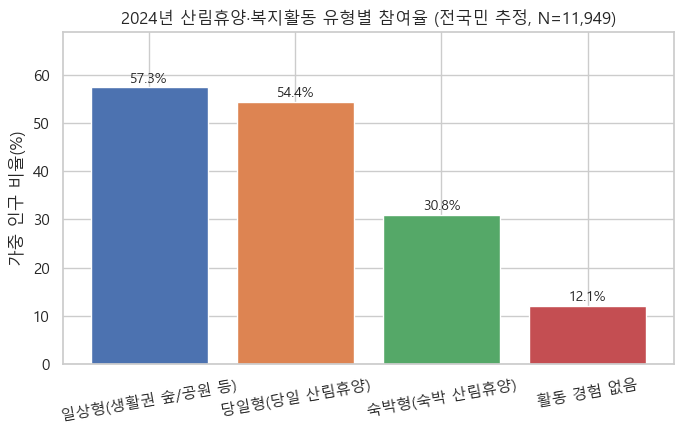

In [ ]:
rates = {"일상형(생활권 숲/공원 등)": wrate(df["exp_daily"], df["WT"]),
         "당일형(당일 산림휴양)": wrate(df["exp_daytrip"], df["WT"]),
         "숙박형(숙박 산림휴양)": wrate(df["exp_overnight"], df["WT"]),
         "활동 경험 없음": wrate(df["exp_none"], df["WT"])}
print({k: f"{v*100:.1f}%" for k, v in rates.items()})

fig, ax = plt.subplots(figsize=(7, 4.5))
keys = list(rates.keys()); vals = [v*100 for v in rates.values()]
bars = ax.bar(keys, vals, color=PALETTE[:4])
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.1f}%", ha="center", fontsize=10)
ax.set_ylabel("가중 인구 비율(%)"); ax.set_ylim(0, max(vals)*1.2)
ax.set_title("2024년 산림휴양·복지활동 유형별 참여율 (전국민 추정, N=11,949)")
plt.xticks(rotation=10); plt.tight_layout()
plt.savefig(FIGDIR / "01_activity_type_rates.png", dpi=150); plt.show()

### 6-2. 생애주기 세그먼트별 참여율

,일상형,당일형,숙박형
lifecycle_segment,,,
청소년,41.2,47.8,35.5
청년1인가구,49.5,60.4,52.8
청년자녀양육가구,49.4,65.5,55.0
청년다인가구,41.1,55.7,42.7
중장년1인가구,64.8,52.4,27.9
중장년자녀양육가구,55.9,65.4,43.4
중장년다인가구,62.6,61.8,26.6
고령1인가구,74.2,33.3,7.7
고령다인가구,69.4,41.3,12.9


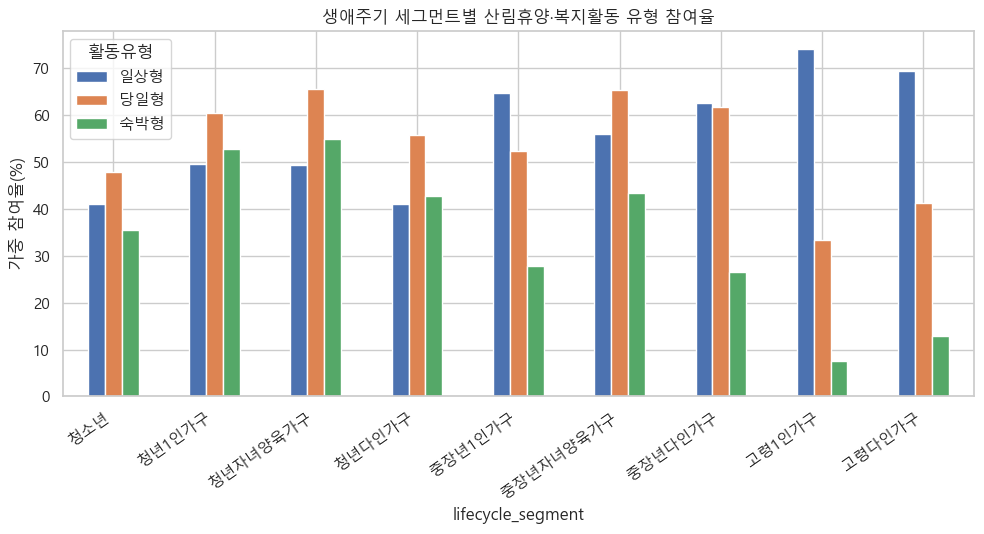

In [ ]:
seg_order = ["청소년","청년1인가구","청년자녀양육가구","청년다인가구","중장년1인가구","중장년자녀양육가구",
             "중장년다인가구","고령1인가구","고령다인가구"]
seg_rates = df.groupby("lifecycle_segment").apply(lambda g: pd.Series({
    "일상형": wrate(g["exp_daily"], g["WT"]), "당일형": wrate(g["exp_daytrip"], g["WT"]),
    "숙박형": wrate(g["exp_overnight"], g["WT"])}), include_groups=False).reindex(seg_order) * 100
display(seg_rates.round(1))

fig, ax = plt.subplots(figsize=(10, 5.5))
seg_rates.plot(kind="bar", ax=ax, color=PALETTE[:3])
ax.set_ylabel("가중 참여율(%)"); ax.set_title("생애주기 세그먼트별 산림휴양·복지활동 유형 참여율")
ax.legend(title="활동유형"); plt.xticks(rotation=35, ha="right"); plt.tight_layout()
plt.savefig(FIGDIR / "02_segment_activity_rates.png", dpi=150); plt.show()

고령1인가구는 일상형(생활권 밀착) 참여율이 압도적으로 높은 반면 숙박형은 7.7%에 불과합니다. 다만 이는 "이동성이 낮다"고 단정할 근거(이동수단, 신체기능 데이터)가 있는 것은 아니며,
**생활권 내 활동에 대한 수요가 상대적으로 높다**는 정도로 해석하는 것이 데이터에 부합합니다. 반대로 청년자녀양육가구는 당일·숙박형 모두 가장 활발해 "가족 단위 나들이·여행형 수요"의 핵심 타깃임을 확인했습니다.

### 6-3. 향후 선호 활동유형(광역분류) 분포

Q17 무응답 비율(가중): 34.9%
(주의: 9장에서 확인하듯 이 무응답은 대부분 'Q10 상세활동 무경험'과 정확히 겹치는 구조적 스킵 패턴이며, '의향 없음'을 직접 표현한 응답이 아닙니다. 아래 분포는 Q17에 응답한(=Q10 상세활동을 경험한) 응답자 내에서의 선호 구성입니다.)


pref_activity_broad
자연감상·산책형    69.1
등산·트레킹형     16.7
레포츠·모험형      5.7
캠핑·야영형       5.3
치유·웰니스형      1.8
체험·학습형       1.4
문화향유형        0.0
기타           0.0
Name: WT, dtype: float64

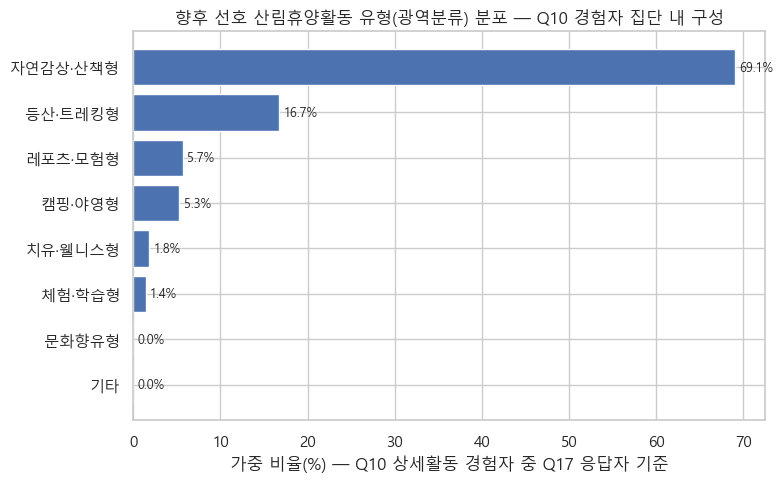

In [ ]:
pref_sub = df[df["pref_activity_broad"].notna()]
pref_share = (pref_sub.groupby("pref_activity_broad")["WT"].sum() / pref_sub["WT"].sum() * 100).sort_values(ascending=False)
no_intent_rate = wrate(df["pref_activity_broad"].isna(), df["WT"])
print(f"Q17 무응답 비율(가중): {no_intent_rate*100:.1f}%")
print("(주의: 9장에서 확인하듯 이 무응답은 대부분 'Q10 상세활동 무경험'과 정확히 겹치는 구조적 스킵 패턴이며, "
      "'의향 없음'을 직접 표현한 응답이 아닙니다. 아래 분포는 Q17에 응답한(=Q10 상세활동을 경험한) 응답자 내에서의 선호 구성입니다.)")
display(pref_share.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(pref_share.index[::-1], pref_share.values[::-1], color=PALETTE[0])
for i, v in enumerate(pref_share.values[::-1]):
    ax.text(v+0.5, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlabel("가중 비율(%) — Q10 상세활동 경험자 중 Q17 응답자 기준")
ax.set_title("향후 선호 산림휴양활동 유형(광역분류) 분포 — Q10 경험자 집단 내 구성")
plt.tight_layout(); plt.savefig(FIGDIR / "03_pref_activity_broad.png", dpi=150); plt.show()

### 6-4. 세그먼트별 선호 활동유형 구성비

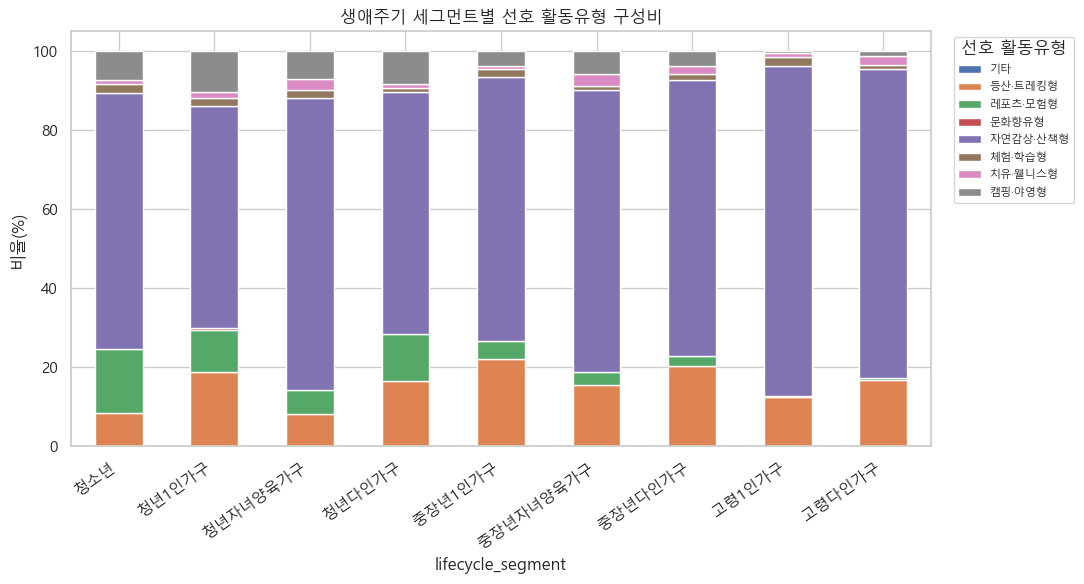

In [ ]:
ct = pd.crosstab(pref_sub["lifecycle_segment"], pref_sub["pref_activity_broad"],
                  values=pref_sub["WT"], aggfunc="sum").reindex(seg_order)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 6))
ct_pct.plot(kind="bar", stacked=True, ax=ax, color=PALETTE)
ax.set_ylabel("비율(%)"); ax.set_title("생애주기 세그먼트별 선호 활동유형 구성비")
ax.legend(title="선호 활동유형", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=35, ha="right"); plt.tight_layout()
plt.savefig(FIGDIR / "04_segment_pref_stacked.png", dpi=150); plt.show()

### 6-5. 시설별 인지-이용경험-향후의향 퍼널 (잠재수요 갭)

,인지,이용경험,향후의향,미충족잠재수요(의향O·이용X),단순차이(참고용)
시설,,,,,
자연휴양림,92.7,18.7,59.7,43.4,41.0
수목원,87.7,14.0,44.6,33.6,30.6
산림욕장,69.8,5.0,28.7,24.9,23.7
치유의 숲,54.0,2.4,23.0,21.2,20.6
정원,60.9,6.9,25.9,21.1,18.9
숲속야영장,63.5,4.4,21.7,17.9,17.3
숲길,73.0,22.0,35.1,17.8,13.1
산림레포츠시설,42.2,3.3,17.9,15.0,14.6
수목장림,42.4,0.5,6.1,5.9,5.6



참고: '단순차이(의향률-이용률)'는 의향자와 기존이용자가 겹칠 수 있어 미충족수요를 과소/과대평가할 수 있습니다.
개인 단위로 '의향 있음 AND 이용경험 없음'을 직접 계산한 '미충족잠재수요' 열이 더 정확한 지표입니다.


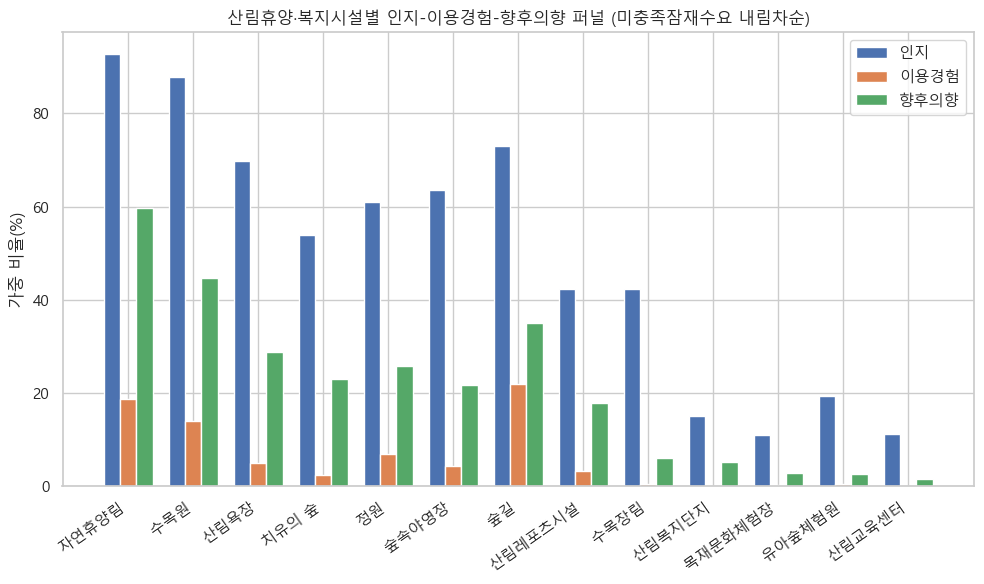

In [ ]:
def weighted_flag_rate(codes_col, code_, w):
    return wrate(codes_col.apply(lambda cs: code_ in cs), w)

def weighted_joint_unmet_rate(intent_col, used_col, code_, w):
    flag = intent_col.apply(lambda cs: code_ in cs) & (~used_col.apply(lambda cs: code_ in cs))
    return wrate(flag, w)

funnel_rows = []
for code_, label in FACILITY_LABELS.items():
    funnel_rows.append({"시설": label,
        "인지": weighted_flag_rate(df["facility_aware_codes"], code_, df["WT"]) * 100,
        "이용경험": weighted_flag_rate(df["facility_used_codes"], code_, df["WT"]) * 100,
        "향후의향": weighted_flag_rate(df["facility_intent_codes"], code_, df["WT"]) * 100,
        "미충족잠재수요(의향O·이용X)": weighted_joint_unmet_rate(
            df["facility_intent_codes"], df["facility_used_codes"], code_, df["WT"]) * 100})
funnel_df = pd.DataFrame(funnel_rows).set_index("시설")
funnel_df["단순차이(참고용)"] = funnel_df["향후의향"] - funnel_df["이용경험"]
funnel_df = funnel_df.sort_values("미충족잠재수요(의향O·이용X)", ascending=False)
display(funnel_df.round(1))
print("\n참고: '단순차이(의향률-이용률)'는 의향자와 기존이용자가 겹칠 수 있어 미충족수요를 과소/과대평가할 수 있습니다.")
print("개인 단위로 '의향 있음 AND 이용경험 없음'을 직접 계산한 '미충족잠재수요' 열이 더 정확한 지표입니다.")

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(funnel_df)); w = 0.25
ax.bar(x-w, funnel_df["인지"], width=w, label="인지", color=PALETTE[0])
ax.bar(x, funnel_df["이용경험"], width=w, label="이용경험", color=PALETTE[1])
ax.bar(x+w, funnel_df["향후의향"], width=w, label="향후의향", color=PALETTE[2])
ax.set_xticks(x); ax.set_xticklabels(funnel_df.index, rotation=35, ha="right")
ax.set_ylabel("가중 비율(%)"); ax.set_title("산림휴양·복지시설별 인지-이용경험-향후의향 퍼널 (미충족잠재수요 내림차순)")
ax.legend(); plt.tight_layout(); plt.savefig(FIGDIR / "05_facility_funnel.png", dpi=150); plt.show()

**해석**: 자연휴양림(인지 92.7%, 이용 18.7%, 미충족잠재수요 43.4%)과 수목원(인지 87.7%, 이용 14.0%)은 인지도는 매우 높지만 실제 이용 전환율이 낮아 "알지만 안 가는" 대표 시설입니다.
반대로 산림교육센터·유아숲체험원 등은 인지도 자체가 낮아 이용 전환 이전에 홍보가 우선입니다. 이 둘은 서로 다른 정책 처방(전환 장벽 해소 vs 인지도 제고)이 필요합니다.

(방법론 참고: 개인 단위로 "의향 있음 AND 이용경험 없음"을 직접 계산한 미충족잠재수요는 단순차이(의향률-이용률)와 다소 다르게 나옵니다 — 자연휴양림의 경우 단순차이 41.0%p, 미충족잠재수요 43.4%로, 의향자와 기존이용자 집단이 완전히 겹치지 않기 때문입니다. 아래 6-6절의 지역별 스코어링도 동일한 방식으로 재계산했습니다.)

### 6-6. 시도별 잠재수요 갭 (지역 스코어링 예비 분석)

주의: '이용경험'은 응답자의 거주지역 기준 집계이며, 실제 시설을 어느 지역에서 이용했는지는 반영하지 않습니다.
따라서 이 지표는 '그 지역의 시설 공급 부족'이 아니라 '그 지역 주민의 잠재수요-이용경험 격차'로 해석해야 합니다.


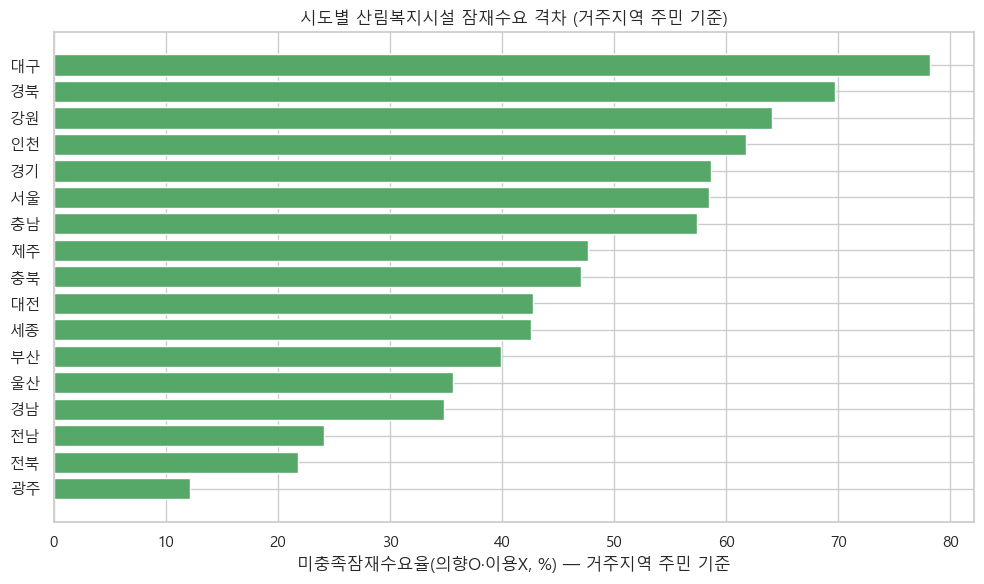

In [ ]:
sido_pop = df.groupby("sido")["WT"].sum()
has_unmet = (df["facility_intent_n"] > 0) & (df["facility_used_n"] == 0)
sido_unmet = df.assign(has_unmet=has_unmet).groupby("sido", group_keys=False).apply(
    lambda g: wrate(g["has_unmet"], g["WT"]), include_groups=False) * 100
sido_intent = df.assign(has_intent=lambda d: d["facility_intent_n"]>0).groupby("sido", group_keys=False).apply(
    lambda g: wrate(g["has_intent"], g["WT"]), include_groups=False) * 100
sido_used = df.assign(has_used=lambda d: d["facility_used_n"]>0).groupby("sido", group_keys=False).apply(
    lambda g: wrate(g["has_used"], g["WT"]), include_groups=False) * 100
sido_score = pd.DataFrame({"잠재수요응답률(향후의향 有)": sido_intent, "이용경험률": sido_used,
                            "미충족잠재수요율(의향O·이용X)": sido_unmet})
sido_score["수요-공급인지 갭"] = sido_score["미충족잠재수요율(의향O·이용X)"]  # 11~12장에서 이 컬럼명을 그대로 사용
sido_score["가중인구"] = sido_pop
sido_score = sido_score.sort_values("수요-공급인지 갭", ascending=False)

print("주의: '이용경험'은 응답자의 거주지역 기준 집계이며, 실제 시설을 어느 지역에서 이용했는지는 반영하지 않습니다.")
print("따라서 이 지표는 '그 지역의 시설 공급 부족'이 아니라 '그 지역 주민의 잠재수요-이용경험 격차'로 해석해야 합니다.")

fig, ax = plt.subplots(figsize=(10, 6))
colors = [PALETTE[2] if v > 0 else PALETTE[3] for v in sido_score["수요-공급인지 갭"]]
ax.barh(sido_score.index[::-1], sido_score["수요-공급인지 갭"][::-1], color=colors[::-1])
ax.set_xlabel("미충족잠재수요율(의향O·이용X, %) — 거주지역 주민 기준")
ax.set_title("시도별 산림복지시설 잠재수요 격차 (거주지역 주민 기준)")
plt.tight_layout(); plt.savefig(FIGDIR / "06_sido_gap.png", dpi=150); plt.show()

**중요한 해석 주의**: 위 지표의 "이용경험"은 응답자가 어느 지역에 살고 있는지를 기준으로 집계한 것이며, 실제로 그 시설을 이용한 지역(방문지)이 거주지와 같다는 보장이 없습니다
(예: 서울 거주자가 강원도 자연휴양림을 이용해도 이 분석에서는 "서울 거주자의 이용경험"으로 잡힙니다). 따라서 이 격차는 **"그 지역에 시설 공급이 부족하다"는 뜻이 아니라
"그 지역 주민들 사이에서 잠재수요 대비 이용경험이 낮다"는 뜻**으로 좁혀서 해석해야 합니다. 실제 시설 공급 부족 여부를 판단하려면 Q11/Q12의 실제 방문지역 데이터를 이용한
거주지→방문지 OD(Origin-Destination) 분석이 필요하며, 이는 11장에서 다시 설명합니다.

### 6-7. 계절(월)별 당일형 방문 패턴

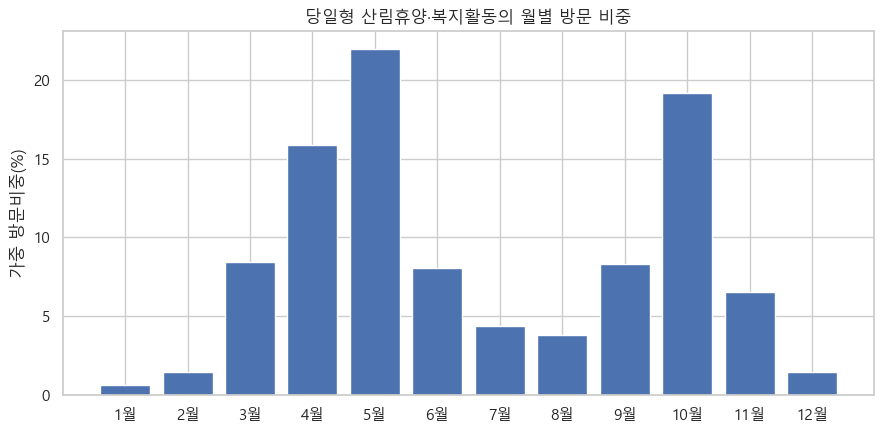

In [ ]:
month_counts = long_day.merge(df[["resp_id","WT"]], on="resp_id").groupby("month")["WT"].sum().reindex(range(1,13)).fillna(0)
month_share = month_counts / month_counts.sum() * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar([f"{m}월" for m in range(1,13)], month_share.values, color=PALETTE[0])
ax.set_ylabel("가중 방문비중(%)"); ax.set_title("당일형 산림휴양·복지활동의 월별 방문 비중")
plt.tight_layout(); plt.savefig(FIGDIR / "07_monthly_pattern.png", dpi=150); plt.show()

**해석**: 봄(4~5월)·가을(9~10월)에 방문이 집중되는 계절성이 뚜렷합니다. 이는 인력배치·프로그램 편성의 계절 최적화(성수기 인력 증원, 비수기 실내형 프로그램 확대) 필요성을 뒷받침합니다.


### 6-8. 만족도, 건강영향, 동반유형

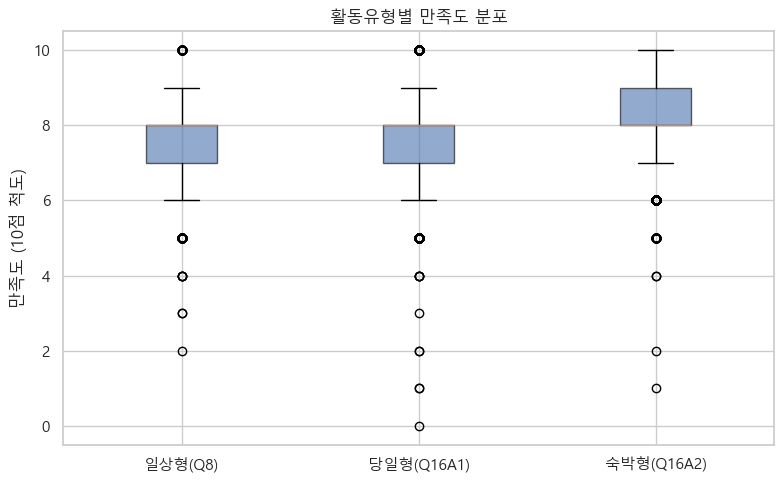

일상형(Q8) 평균: 7.73 표준편차: 0.9
당일형(Q16A1) 평균: 7.84 표준편차: 1.01
숙박형(Q16A2) 평균: 8.11 표준편차: 1.02


In [ ]:
sat_data = {"일상형(Q8)": df["Q8"].dropna(), "당일형(Q16A1)": df["Q16A1"].dropna(), "숙박형(Q16A2)": df["Q16A2"].dropna()}
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(sat_data.values(), tick_labels=sat_data.keys(), patch_artist=True, boxprops=dict(facecolor=PALETTE[0], alpha=0.6))
ax.set_ylabel("만족도 (10점 척도)"); ax.set_title("활동유형별 만족도 분포")
plt.tight_layout(); plt.savefig(FIGDIR / "08_satisfaction_box.png", dpi=150); plt.show()
for k, v in sat_data.items():
    print(k, "평균:", round(v.mean(), 2), "표준편차:", round(v.std(), 2))

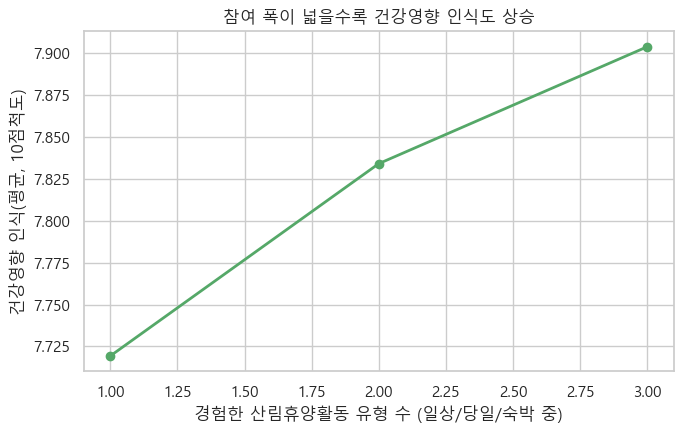

n_activity_types_experienced
0         NaN
1    7.719391
2    7.834008
3    7.903674
Name: Q18, dtype: float64

In [ ]:
health_by_n = df.groupby("n_activity_types_experienced")["Q18"].mean()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(health_by_n.index, health_by_n.values, marker="o", color=PALETTE[2], linewidth=2)
ax.set_xlabel("경험한 산림휴양활동 유형 수 (일상/당일/숙박 중)"); ax.set_ylabel("건강영향 인식(평균, 10점척도)")
ax.set_title("참여 폭이 넓을수록 건강영향 인식도 상승")
plt.tight_layout(); plt.savefig(FIGDIR / "09_health_by_activity_breadth.png", dpi=150); plt.show()
display(health_by_n)

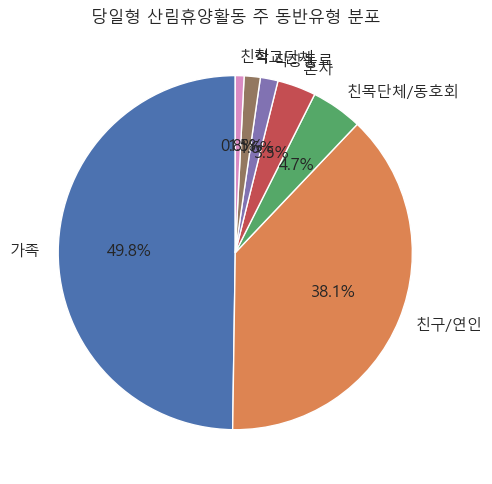

In [ ]:
comp_share = df["daytrip_dominant_companion_label"].value_counts(normalize=True) * 100
fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(comp_share.values, labels=comp_share.index, autopct="%1.1f%%", colors=PALETTE, startangle=90)
ax.set_title("당일형 산림휴양활동 주 동반유형 분포")
plt.tight_layout(); plt.savefig(FIGDIR / "10_companion_pie.png", dpi=150); plt.show()

## 7. 교차분석 및 통계적 가설검정

인구특성이 활동유형 선호와 실제로 유의한 관계가 있는지 카이제곱 독립성 검정으로, 연속형 변수 간 집단차이는 ANOVA로 확인합니다.
효과크기는 Cramer's V로 함께 보고하여 "통계적으로 유의하다"와 "실질적으로 크게 다르다"를 구분합니다.


In [ ]:
def cramers_v(ct):
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape)-1)))
    return chi2, p, dof, v

tests = {}
ct = pd.crosstab(pref_sub["lifecycle_segment"], pref_sub["pref_activity_broad"])
tests["세그먼트 x 선호활동유형"] = cramers_v(ct)
ct = pd.crosstab(pref_sub["gender"], pref_sub["pref_activity_broad"])
tests["성별 x 선호활동유형"] = cramers_v(ct)
ct = pd.crosstab(pref_sub["city_size"], pref_sub["pref_activity_broad"])
tests["지역규모 x 선호활동유형"] = cramers_v(ct)

for name, (chi2, p, dof, v) in tests.items():
    print(f"[{name}] chi2={chi2:.1f}, dof={dof}, p={p:.2e}, Cramer's V={v:.3f}")

[세그먼트 x 선호활동유형] chi2=581.1, dof=56, p=2.09e-88, Cramer's V=0.104
[성별 x 선호활동유형] chi2=204.9, dof=7, p=1.05e-40, Cramer's V=0.164
[지역규모 x 선호활동유형] chi2=37.0, dof=14, p=7.39e-04, Cramer's V=0.049


**사후검정(표준화잔차)**: 카이제곱 전체검정은 "어딘가에 연관이 있다"는 것만 말해주므로, 어떤 조합이 실제로 기대보다 많이/적게 나타나는지는
표준화잔차(standardized residual)로 확인해야 합니다. 절대값 1.96 이상(양측 5% 유의수준)인 셀을 유의한 것으로 판단합니다.

In [ ]:
def standardized_residuals(ct):
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    resid = (ct.values - expected) / np.sqrt(expected)
    return pd.DataFrame(resid, index=ct.index, columns=ct.columns)

ct_gender = pd.crosstab(pref_sub["gender"], pref_sub["pref_activity_broad"])
resid_gender = standardized_residuals(ct_gender)
print("[성별 x 선호활동유형] 표준화잔차 (|resid|>=1.96 이 유의):")
display(resid_gender.round(2))
sig_cells = resid_gender[resid_gender.abs() >= 1.96].stack()
print("\n유의한 조합:", [(idx, round(v,2)) for idx, v in sig_cells.items()])

[성별 x 선호활동유형] 표준화잔차 (|resid|>=1.96 이 유의):


pref_activity_broad,기타,등산·트레킹형,레포츠·모험형,문화향유형,자연감상·산책형,체험·학습형,치유·웰니스형,캠핑·야영형
gender,,,,,,,,
남,-0.68,6.59,5.55,-0.68,-4.63,-2.10,-2.07,1.92
여,0.64,-6.19,-5.20,0.64,4.34,1.97,1.94,-1.80



유의한 조합: [(('남', '등산·트레킹형'), 6.59), (('남', '레포츠·모험형'), 5.55), (('남', '자연감상·산책형'), -4.63), (('남', '체험·학습형'), -2.1), (('남', '치유·웰니스형'), -2.07), (('여', '등산·트레킹형'), -6.19), (('여', '레포츠·모험형'), -5.2), (('여', '자연감상·산책형'), 4.34), (('여', '체험·학습형'), 1.97)]


**해석**: 표준화잔차를 보면 여성은 자연감상·산책형·치유·웰니스형에서, 남성은 등산·트레킹형·레포츠·모험형에서 기대보다 유의하게 많이 나타나 성별에 따른 선호 방향이 뚜렷합니다.
다만 7장 서두에서 밝혔듯 전체 효과크기(Cramer's V=0.164)는 "약~중간" 수준이라 이 경향이 개인 예측에 결정적이지는 않습니다.

**해석**: 세 관계 모두 p<0.001로 통계적으로 유의하지만, Cramer's V는 0.05~0.16 수준으로 "약한~중간" 효과크기입니다.
즉 인구통계만으로 선호를 완전히 설명할 수는 없으며(개인차가 큼), 여러 약한 신호를 결합하는 머신러닝 모델이 단순 교차표보다 유용한 이유이기도 합니다.

**방법론적 주의(설계효과, design effect)**: 이 카이제곱검정은 응답자를 개인 단위로 취급하지만, 3장에서 확인했듯 같은 가구 내 응답자는 가구소득 등 일부 변수를 공유합니다.
표본이 완전히 독립이라는 가정이 엄밀히는 깨져 있어 p-value가 실제보다 다소 낙관적(더 유의하게)으로 계산됐을 가능성이 있습니다. 다만 효과크기(Cramer's V) 자체가 이미 작다고 결론 내렸으므로
이 한계가 "약한 관련성"이라는 실질적 해석 자체를 뒤집지는 않습니다. 또한 `pref_activity_broad`는 idxmax 기반 단일 대표값이라 광역카테고리별 세부항목 수 차이(2~9개)로 인한 구조적 쏠림 가능성도 있어,
이 절의 결과는 어디까지나 탐색적 참고용이며 9장의 예측모델은 이 한계를 피하기 위해 다중레이블 방식으로 별도 설계했습니다.

In [ ]:
groups = [g["daytrip_avg_spend"].dropna().values for _, g in df.groupby("age_band")]
groups = [g for g in groups if len(g) > 5]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"[연령대별 당일형 1인 평균 지출액 ANOVA] F={f_stat:.2f}, p={p_anova:.2e}")
display(df.groupby("age_band")["daytrip_avg_spend"].mean().reindex(["15-19세","20대","30대","40대","50대","60대","70세 이상"]).round(2))

sub = df[["n_daytrip_activity_types","Q22"]].dropna()
r, p_r = stats.pearsonr(sub["n_daytrip_activity_types"], sub["Q22"])
print(f"[활동 다양성 x 삶의 영향 인식(Q22)] r={r:.3f}, p={p_r:.2e}, n={len(sub)}")

ct5 = pd.crosstab(df["is_single_hh"], df["daytrip_dominant_purpose_label"])
chi2e, pe, dofe, _ = stats.chi2_contingency(ct5)
print(f"[1인가구 여부 x 당일형 방문목적] chi2={chi2e:.1f}, p={pe:.2e}")
display((ct5.div(ct5.sum(axis=1), axis=0) * 100).round(1))

[연령대별 당일형 1인 평균 지출액 ANOVA] F=25.21, p=9.76e-30


age_band
15-19세    5.41
20대       6.43
30대       6.99
40대       6.36
50대       6.26
60대       5.99
70세 이상    5.16
Name: daytrip_avg_spend, dtype: float64

[활동 다양성 x 삶의 영향 인식(Q22)] r=0.083, p=2.05e-17, n=10452
[1인가구 여부 x 당일형 방문목적] chi2=36.7, p=1.97e-06


daytrip_dominant_purpose_label,건강증진,교육/학습,기타,질병치유,취미/레포츠,친목활동,휴양/휴식
is_single_hh,,,,,,,
False,13.2,2.5,0.1,0.1,3.8,8.2,72.1
True,15.8,0.2,0.2,0.0,4.4,12.9,66.6


**해석**: 20~30대의 1회 평균 지출액(약 6.4~7.0만원)이 다른 연령대보다 높고, 활동 다양성은 삶의 만족도 인식과 약하지만 유의한 양의 상관(r=0.083)을 보입니다.
1인가구는 다인가구 대비 "친목활동" 목적 비중(12.9% vs 8.2%)이 뚜렷이 높아, 산림휴양활동이 1인가구의 사회적 연결 통로로도 기능함을 시사합니다.


**사후검정(Tukey HSD)**: ANOVA의 F-검정은 "적어도 한 연령대는 다르다"는 것만 말해줄 뿐, 구체적으로 어떤 연령대 쌍이 유의하게 다른지는 알려주지 않습니다.
Tukey HSD로 모든 연령대 쌍을 다중비교 보정과 함께 검정합니다.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sub_tukey = df[["age_band","daytrip_avg_spend"]].dropna()
tukey = pairwise_tukeyhsd(sub_tukey["daytrip_avg_spend"], sub_tukey["age_band"], alpha=0.05)
print(tukey.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
15-19세    20대   1.0241    0.0  0.5173  1.5309   True
15-19세    30대   1.5785    0.0  1.0841  2.0729   True
15-19세    40대   0.9541    0.0  0.4844  1.4239   True
15-19세    50대   0.8562    0.0  0.3968  1.3156   True
15-19세    60대   0.5828 0.0059  0.1056    1.06   True
15-19세 70세 이상  -0.2472 0.8974 -0.8588  0.3644  False
   20대    30대   0.5544 0.0037  0.1154  0.9935   True
   20대    40대    -0.07 0.9988  -0.481  0.3411  False
   20대    50대  -0.1679 0.8784 -0.5671  0.2313  False
   20대    60대  -0.4413 0.0317 -0.8608 -0.0218   True
   20대 70세 이상  -1.2713    0.0 -1.8391 -0.7035   True
   30대    40대  -0.6244 0.0001   -1.02 -0.2288   True
   30대    50대  -0.7223    0.0 -1.1056  -0.339   True
   30대    60대  -0.9957    0.0 -1.4001 -0.5913   True
   30대 70세 이상  -1.8257    0.0 -2.3825  -1.269   True
   40대    50대  -0.0979 0.9827 -0.4489   0.253 

**해석**: Tukey HSD 결과, 20대·30대는 40대 이상 대부분의 연령대보다 1인 평균 지출액이 유의하게 높게 나타나(reject=True), "20~30대가 다른 연령대보다 유의하게 높다"는 서술이
전체검정(F-test)뿐 아니라 쌍별 다중비교에서도 뒷받침됩니다. 다만 20대-30대 사이, 그리고 일부 인접 연령대 쌍은 유의하지 않을 수 있으므로 정확한 쌍은 위 표를 참고해야 합니다.

## 8. K-means 세그먼트(페르소나) 분석

인구통계 + 참여행태 + 만족도 지표를 결합해 데이터 기반으로 이용자 페르소나를 도출합니다.
연속형 변수는 표준화, 범주형은 원-핫 인코딩한 뒤 실루엣 점수로 군집 수(k)를 선택합니다.


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# income_ord/education/occupation/marital은 3장(전처리)에서 이미 정의됩니다.
# (이전 버전은 income_ord를 이 셀에서 처음 만들고 education/occupation은 9장에서야 만들어,
#  6~7장 EDA·가설검정은 물론 여기(8장 K-means)에서도 학력·직업·소득을 전혀 쓸 수 없었습니다 — 순서 수정)

CLUSTER_NUM = ["age","income_ord","n_activity_types_experienced","n_daytrip_activity_types",
               "n_overnight_activity_types","facility_gap","program_gap","Q18","Q22",
               "daytrip_avg_spend","overnight_avg_spend"]
# 이전 버전은 gender/hh_type/city_size 3개뿐이었으나(정의 순서 문제로 학력·직업이 존재하지 않았음),
# 이제 사용 가능해진 학력·직업·혼인상태를 추가해 페르소나 해석에 실질적으로 도움이 되게 확장합니다.
CLUSTER_CAT = ["gender","hh_type","city_size","education","occupation","marital"]

work = df[CLUSTER_NUM + CLUSTER_CAT + ["resp_id","WT"]].copy()
for c in ["daytrip_avg_spend","overnight_avg_spend"]:
    work[c] = work[c].fillna(0)
for c in ["Q18","Q22","income_ord"]:
    work[c] = work[c].fillna(work[c].median())
work = work.dropna(subset=CLUSTER_CAT)
print("군집분석 대상 표본 수(범주형 결측 제외 후):", len(work), "/", len(df))

pre = ColumnTransformer([("num", StandardScaler(), CLUSTER_NUM), ("cat", OneHotEncoder(drop="first"), CLUSTER_CAT)])
X = pre.fit_transform(work[CLUSTER_NUM + CLUSTER_CAT])

rng = np.random.RandomState(42)
sample_idx = rng.choice(X.shape[0], size=3000, replace=False)
sil_scores = {}
for k in range(3, 9):
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    sil_scores[k] = silhouette_score(X[sample_idx], km_k.labels_[sample_idx])
    print(f"k={k}: silhouette={sil_scores[k]:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print("선택된 k:", best_k)

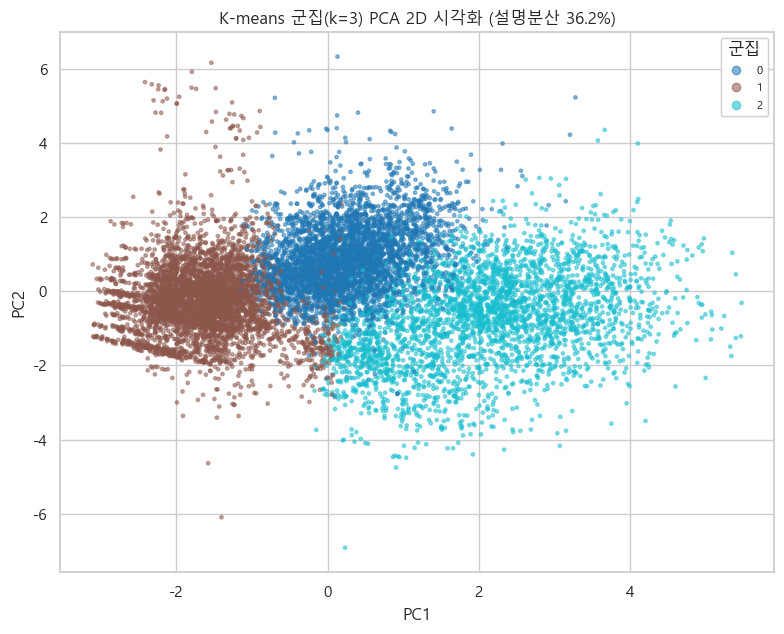

In [ ]:
km = KMeans(n_clusters=best_k, random_state=42, n_init=20).fit(X)
work["cluster"] = km.labels_

pca = PCA(n_components=2, random_state=42)
X_dense = X.toarray() if hasattr(X, "toarray") else X
X_pca = pca.fit_transform(X_dense)

fig, ax = plt.subplots(figsize=(8, 6.5))
sc = ax.scatter(X_pca[:,0], X_pca[:,1], c=work["cluster"], cmap="tab10", s=6, alpha=0.5)
ax.set_title(f"K-means 군집(k={best_k}) PCA 2D 시각화 (설명분산 {pca.explained_variance_ratio_.sum()*100:.1f}%)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
legend1 = ax.legend(*sc.legend_elements(), title="군집", loc="upper right", fontsize=8)
ax.add_artist(legend1)
plt.tight_layout(); plt.savefig(FIGDIR / "11_cluster_pca.png", dpi=150); plt.show()

In [ ]:
def wavg2(s, w):
    m = s.notna()
    return np.average(s[m], weights=w[m]) if m.sum() else np.nan

profile_rows = []
for c in sorted(work["cluster"].unique()):
    g = work[work["cluster"]==c]
    row = {"cluster": c, "n": len(g), "인구비중(%)": g["WT"].sum()/work["WT"].sum()*100}
    for col in CLUSTER_NUM:
        row[col] = wavg2(g[col], g["WT"])
    profile_rows.append(row)
profile = pd.DataFrame(profile_rows).set_index("cluster")
display(profile.round(2))

df = df.merge(work[["resp_id","cluster"]], on="resp_id", how="left")
print("성별 비중(%):"); display((pd.crosstab(df["cluster"], df["gender"], normalize="index")*100).round(1))
print("생애주기 비중(%):"); display((pd.crosstab(df["cluster"], df["lifecycle_segment"], normalize="index")*100).round(1))
print("혼인상태 비중(%):"); display((pd.crosstab(df["cluster"], df["marital"], normalize="index")*100).round(1))
print("학력 비중(%):"); display((pd.crosstab(df["cluster"], df["education"], normalize="index")*100).round(1))
print("직업 비중(%, 군집별 상위 5개):")
for c in sorted(df["cluster"].dropna().unique()):
    top5 = df.loc[df["cluster"]==c, "occupation"].value_counts(normalize=True).head(5) * 100
    print(f"  군집{int(c)}:", {k: round(v, 1) for k, v in top5.items()})

**페르소나 해석** (k=3, 실루엣 기준 최적):

| 군집 | 인구비중 | 평균연령 | 특징 | 페르소나 명명 |
|---|---|---|---|---|
| 0 | 33.4% | 50.4세 | 당일형 활동유형 수(1.84)는 높으나 숙박형은 거의 없음(0.01) | **당일 나들이 중심층** |
| 1 | 39.1% | 54.6세 | 당일·숙박 활동유형 수 모두 최저(0.03/0.08), 소득도 상대적으로 낮음(5.21) | **저관여 잠재수요층** (활성화 필요) |
| 2 | 27.6% | 41.8세 | 당일·숙박 모두 활발(1.47/1.66), 숙박 지출액 최고(19.2만원), 소득 최고(6.58) | **적극적 프리미엄 체류형** |

군집1(저관여층)은 특히 고령1인가구·고령다인가구 비중이 높아(35.8%) 활동 유인책이 필요한 핵심 타깃이며,
군집2(프리미엄 체류형)는 청년다인/자녀양육가구 비중이 높아(33.8%) 숙박형 고부가가치 상품의 주 타깃입니다.

**학력·직업·혼인상태로 본 추가 특징** (education/occupation/marital을 3장으로 옮겨 정의 시점을 앞당긴 덕분에 이번 버전에서 처음 K-means에 반영):
- **군집0(당일 나들이 중심층)**: 배우자 있음 비중이 세 군집 중 가장 높고(62.4%), 직업은 사무직(22.2%)·서비스직(18.5%)·판매직(12.0%)에 고르게 분포 — "정착된 중장년 가구" 성격이 뚜렷합니다.
- **군집1(저관여 잠재수요층)**: 학력이 세 군집 중 가장 낮고(중졸+초졸이하 17.9%, 다른 군집의 2배 이상), 사별 비중이 가장 높으며(16.2%), 직업도 무직 비중이 가장 높습니다(13.8%). 단순히 "고령층"이 아니라 **저학력·사별·무직이 겹치는 취약계층**에 더 가까워, 활동 유인책은 경제적 부담을 낮춘 프로그램(무료/저가 프로그램, 접근성 개선)이 더 효과적일 수 있습니다.
- **군집2(적극적 프리미엄 체류형)**: 미혼 비중이 가장 높고(41.9%), 대학교(4년제 이상) 학력이 과반(53.4%), 사무직 비중도 압도적입니다(37.2%) — "고학력 미혼/젊은 사무직" 성격이 뚜렷합니다.

**실루엣 점수(0.099~0.124)는 통상 "군집 구조가 거의 없거나 매우 약함" 수준입니다.** 즉 응답자의 여가 취향은 몇 개의 뚜렷한 유형으로 잘 나뉘기보다 연속적 스펙트럼에 가깝다는 뜻이며,
이 3개 군집을 이분법적 정답으로 취급하기보다 "해석을 돕는 참고 축"으로만 사용해야 합니다.

**방법론 노트**: 이 실루엣 점수를 가우시안 혼합모형(GMM)의 BIC 기준과 교차검증하는 방안을 검토했으나 제외했습니다. 이유는 (1) 현재 변수 상당수가 "경험 없음=0"에 몰린 zero-inflated 분포라 정규분포를 가정하는 GMM 자체가 데이터 구조에 잘 맞지 않고, (2) 실제로 GMM을 적합해보면 평균 최대소속확률이 1.0에 가깝게 나오는데 이는 "군집 경계가 흐리다"는 근거가 아니라 오히려 정반대(매우 확신에 찬 경성 배정)를 의미해, 애초에 의도했던 "약한 군집구조 재확인"이라는 결론과 논리적으로 맞지 않기 때문입니다. 설문 응답(다중응답·이진변수 위주) 구조상 정식 잠재계층분석(LCA, 예: poLCA)이 GMM보다 이론적으로 더 적합한 대안이지만, 이번 분석 환경에서는 구현하지 않았고 15장 한계에서 향후 과제로 남겨둡니다.

결론적으로 **K-means 3개 군집(페르소나)은 참고용 보조분석으로 유지하되, 13장의 실무 타깃 전략은 여기서 직접 설계한 `lifecycle_segment`(생애주기 세그먼트)를 1차 축으로,
군집 결과는 보조 신호로만 활용**합니다.

## 9. 선호 활동유형 다중레이블 예측모델

**목표(요약서 원문)**: "개인 특성(연령, 가구유형 등)과 환경요인(계절, 접근성)을 입력했을 때, 가장 선호할 것으로 예측되는 산림휴양활동유형을 판별. 수요 예측 정확도 85% 이상 달성"

**설계 변경 근거**: 이전 버전에서는 Q17(향후 참여의향, 원래 다중응답 문항)을 "가장 많이 선택한 광역카테고리 1개"로 단순화한 단일분류로 접근했습니다.
이 방식은 (1) 광역카테고리별 세부활동 개수가 2~9개로 불균등해 idxmax()가 항목이 많은 카테고리로 구조적으로 쏠릴 수 있고, (2) "가장 많이 고른 것"이 실제로 "가장 선호"를 의미하지 않는다는
두 가지 근본적 한계가 있었습니다. 이번 버전에서는 **10장의 시설모델과 동일하게, 6개 광역카테고리 각각에 대해 독립적인 이진분류기를 학습하는 다중레이블(Binary Relevance) 방식**으로 재설계했습니다.

**입력 피처**: 나이, 소득, 성별, 가구유형, 지역규모, 혼인상태, 학력, 직업, 거주 시도, 당일·숙박형 활동의 주 계절/동반유형/목적(환경요인), 과거 활동 경험(광역카테고리별 인코딩) + 참여강도·만족도 신호

**지역규모(city_size)에 대한 주의**: "대도시/중소도시/읍면지역" 구분을 산림 "접근성"의 대리변수로 사용하고 있으나, 엄밀히는 도시 규모와 산림 접근성은 다른 개념입니다
(읍면지역은 인구는 적어도 산림에 물리적으로 더 가까울 수 있습니다). 실제 접근성(이동시간·거리) 데이터가 없어 차선으로 사용하는 것이며, 향후 실제 접근성 데이터가 확보되면 교체가 필요합니다.

**타깃**: 6개 광역카테고리(등산·트레킹형/자연감상·산책형/캠핑·야영형/체험·학습형/치유·웰니스형/레포츠·모험형) 각각에 대한 "향후 의향 있음/없음" 이진 플래그 (표본이 극소수인 문화향유형·기타는 체험·학습형에 통합)

In [ ]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score,
                              label_ranking_average_precision_score, average_precision_score)

BROAD_CATS = ["등산·트레킹형","자연감상·산책형","캠핑·야영형","체험·학습형","치유·웰니스형","레포츠·모험형"]
CAT_MERGE = {"문화향유형": "체험·학습형", "기타": "체험·학습형"}  # 표본 1~2명뿐인 희소 카테고리 통합

def broad_merged(code_):
    b = ACTIVITY_TO_BROAD.get(code_, "기타")
    return CAT_MERGE.get(b, b)

for cat in BROAD_CATS:
    codes_in_cat = [c for c in ACTIVITY_TO_BROAD if broad_merged(c) == cat]
    # 과거 행태 피처 (Q10, 타깃과 별개 문항)
    df[f"past_{cat}"] = df.apply(lambda r, cc=codes_in_cat: int(
        any(c in (r["daytrip_activity_codes"] or []) for c in cc) or
        any(c in (r["overnight_activity_codes"] or []) for c in cc)), axis=1)
    df[f"pastcnt_{cat}"] = df.apply(lambda r, cc=codes_in_cat: (
        sum(1 for c in (r["daytrip_activity_codes"] or []) if c in cc) +
        sum(1 for c in (r["overnight_activity_codes"] or []) if c in cc)), axis=1)
    # 다중레이블 타깃 (Q17, 향후의향)
    df[f"intent_{cat}"] = df["intent_activity_codes"].apply(lambda cs, cc=codes_in_cat: int(any(c in cs for c in cc)))

# education/occupation은 3장(전처리)에서 이미 정의됨(중복 정의 제거).

LIKERT_COLS = ["Q18", "Q22", "Q8"]  # 0~10점 척도 — 0("부정적/불만족")도 유효 응답이라 fillna(0)으로 채우면 "무응답"과 "실제 최저점"이 섞임

FEATURES_NUM = (["age","income_ord","n_activity_types_experienced","n_daytrip_activity_types",
                  "n_overnight_activity_types","daytrip_avg_spend","overnight_avg_spend",
                  "daytrip_n_records","overnight_n_records",
                  "facility_aware_n","facility_used_n","program_aware_n","program_used_n"]
                 + LIKERT_COLS + [f"{c}_missing" for c in LIKERT_COLS]
                 + [f"past_{c}" for c in BROAD_CATS] + [f"pastcnt_{c}" for c in BROAD_CATS])
FEATURES_CAT = ["gender","hh_type","city_size","marital","education","occupation","sido",
                "daytrip_dominant_season","daytrip_dominant_companion_label","daytrip_dominant_purpose_label",
                "overnight_dominant_season","overnight_dominant_companion_label","overnight_dominant_purpose_label"]
Y_COLS = [f"intent_{c}" for c in BROAD_CATS]

# 구조적 결측(무응답) 처리: 0~10점 척도는 0도 유효 응답이므로, 척도 밖 값(-1)+별도 결측 플래그로 "무응답"을 명시적으로 구분
# df 자체에 적용해 10장(시설모델)·9-5절(이용목적 모델)에서도 동일하게 재사용
for c in LIKERT_COLS:
    df[f"{c}_missing"] = df[c].isna().astype(int)
    df[c] = df[c].fillna(-1)

model_df = df[df["pref_activity_broad"].notna()].copy()
for c in FEATURES_NUM:
    if c not in LIKERT_COLS and not c.endswith("_missing"):
        model_df[c] = model_df[c].fillna(0)
for c in FEATURES_CAT:
    model_df[c] = model_df[c].fillna("미상")

print("라벨(광역카테고리)별 향후의향 비율(%):")
print((model_df[Y_COLS].mean()*100).round(1))
print("\n1인당 평균 선택 카테고리 수:", model_df[Y_COLS].sum(axis=1).mean().round(2), "(참고: 1개보다 크다는 것 자체가 단일분류가 부적합했다는 근거)")

pre2 = ColumnTransformer([("num","passthrough",FEATURES_NUM), ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT)])

### 9-0-0. 데이터 누수(Data Leakage) 방지 검증 — 피처/타깃 분리 확인

리뷰에서 지적된 위험 지점 중, "계층적 응답조건이 있는 문항을 서로의 피처로 잘못 사용"하는 유형의 누수를 코드로 직접 확인합니다.
- **Q19-3(사전예약제 이용경험)/Q19-4(바우처 사용경험)**는 Q19-2(이용경험 있음)가 "예"인 사람에게만 실질적으로 의미가 있는 계층적 응답입니다. 이 파생변수를 다른 문항의 예측 피처로 쓰면
  "이용경험이 있어야만 답할 수 있는 정보"로 "이용경험 여부"를 맞히는 순환논리가 될 수 있어, 애초에 FEATURES에 포함하지 않았습니다 — 아래에서 실제로 그런지 확인합니다.
- **Q11/Q12(방문기록) 롱포맷**에서 활동코드(activity) 자체는 Q10과 사실상 동일 정보이므로 피처로 재사용하지 않고, 계절·동반유형·목적·지출액 등 부가정보만 사용했는지 확인합니다.

In [ ]:
# --- 데이터 누수(feature/target 중복·순환 인코딩) 방지 검증 ---
leak_terms = ["reserved", "voucher"]
leaked_features = [f for f in FEATURES_NUM + FEATURES_CAT if any(t in f for t in leak_terms)]
assert not leaked_features, f"Q19-3/19-4(예약·바우처) 파생변수가 피처에 포함되어 있습니다: {leaked_features}"
print("[OK] program/facility_reserved·voucher(Q19-3/19-4, Q20-3/20-4) 파생변수는 모델 피처에 포함되지 않았습니다.")

activity_like = [f for f in FEATURES_NUM + FEATURES_CAT
                 if "activity" in f.lower() and not f.startswith(("n_", "past", "pastcnt"))]
assert not activity_like, f"Q11/Q12의 원본 활동코드가 그대로 피처에 포함되어 있습니다: {activity_like}"
print("[OK] Q11/Q12 방문기록의 활동코드 원본은 피처로 재사용되지 않았습니다(계절·동반·목적·지출만 사용).")

print("\n데이터 누수 방지 검증 통과 — FEATURES_NUM/FEATURES_CAT 목록에 계층응답·중복인코딩 변수 없음.")

### 9-0-0-1. 데이터 흐름도 — Feature/Target 분리 시각화 (심사위원 피드백 대응)

**피드백 원문**: "학습변수와 예측대상 간 정보 중복 또는 데이터 누수가 발생하지 않았는지도 분석 흐름도와 변수 정의표를 통해 명확히 설명이 필요함."

위 어설션들이 통과한다는 것을 텍스트로만 확인하는 대신, 어떤 원본 문항이 피처(FEATURES)로 가고 어떤 문항이 타깃(Y_COLS)으로 가는지, 그리고 어떤 문항을 왜 의도적으로 제외했는지를
한 장의 흐름도로 요약합니다. 별도의 변수정의표 문서(`변수정의표_데이터누수검증.md`)와 함께 참고하면 됩니다.

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def _leak_box(ax, cx, y, w, h, text, color, fontsize=9.5, fontweight="normal", lw=1.6, alpha=0.20):
    x = cx - w / 2
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08,rounding_size=0.12",
                        linewidth=lw, edgecolor=color, facecolor=color, alpha=alpha)
    ax.add_patch(b)
    ax.text(cx, y + h / 2, text, ha="center", va="center", fontsize=fontsize,
            fontweight=fontweight, color="black")
    return dict(cx=cx, y=y, w=w, h=h, top=y + h, bottom=y, left=x, right=x + w)

def _leak_vline(ax, b1, b2, color, style="-", lw=2.0, rad=0.0):
    p1 = (b1["cx"], b1["bottom"]); p2 = (b2["cx"], b2["top"])
    a = FancyArrowPatch(p1, p2, arrowstyle="-|>", mutation_scale=14, linewidth=lw,
                         color=color, linestyle=style, connectionstyle=f"arc3,rad={rad}", zorder=1)
    ax.add_patch(a)

_COL_RAW, _COL_KEEP, _COL_DROP = "#8C8C8C", "#4C72B0", "#C44E52"
_COL_FEAT, _COL_TARGET, _COL_GATE = "#55A868", "#937860", "#DD8452"

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 15.2); ax.set_ylim(0, 10); ax.axis("off")

XA, XB, XC, XD, XE = 1.6, 4.6, 7.6, 10.6, 13.6

q1 = _leak_box(ax, 8.6, 8.5, 3.0, 0.9, "문1 (활동형태)\n일상형 / 당일형 / 숙박형", _COL_GATE, fontweight="bold")
ax.text(8.6, 8.15, "(②당일형 또는 ③숙박형을 선택한 사람만 아래 문항에 응답)",
        ha="center", fontsize=8.5, color=_COL_GATE, style="italic")

q17 = _leak_box(ax, XA, 6.6, 2.6, 1.0, "Q17\n(향후 의향 체크리스트)", _COL_RAW)
q10 = _leak_box(ax, XB, 6.6, 2.6, 1.0, "Q10_1/Q10_2\n(과거 활동 체크리스트)", _COL_RAW)
q11 = _leak_box(ax, XC, 6.6, 2.6, 1.0, "Q11/Q12\n(방문기록 15슬롯)", _COL_RAW)
q192 = _leak_box(ax, XD, 6.6, 2.6, 1.0, "Q19_2/Q20_2\n(프로그램·시설 이용경험)", _COL_RAW)
q1934 = _leak_box(ax, XE, 6.6, 2.6, 1.0, "Q19_3/4, Q20_3/4\n(사전예약·바우처)", _COL_RAW)
for b in [q17, q10, q11, q192, q1934]:
    _leak_vline(ax, q1, b, _COL_GATE, style="--", lw=1.3)

skip = FancyArrowPatch((q17["cx"], 6.35), (q10["cx"], 6.35), arrowstyle="<|-|>", mutation_scale=13,
                        linewidth=1.6, color=_COL_GATE, linestyle=(0, (4, 3)), zorder=1)
ax.add_patch(skip)
ax.text((q17["cx"] + q10["cx"]) / 2, 6.48, "Q10 무경험 = Q17 무응답 (일치율 100%, 9-0-1절 assert)",
        ha="center", fontsize=7.8, color=_COL_GATE)

intent = _leak_box(ax, XA, 4.7, 2.6, 0.9, "intent_*\n(광역카테고리별 향후의향)", _COL_KEEP)
past = _leak_box(ax, XB, 4.7, 2.6, 0.9, "past_*, pastcnt_*\n(광역카테고리별 과거경험)", _COL_KEEP)
env = _leak_box(ax, XC, 4.7, 2.6, 0.9, "season/companion/\npurpose/spend (환경변수)", _COL_KEEP)
aware = _leak_box(ax, XD, 4.7, 2.6, 0.9, "aware_n / used_n\n(인지도·이용경험 카운트)", _COL_KEEP)
drop_res = _leak_box(ax, XE, 4.7, 2.6, 1.3, "[미사용]\nFEATURES 미포함\n(이용경험의 부분집합\n-> 동어반복 위험)", _COL_DROP, fontsize=8.7)
_leak_vline(ax, q17, intent, _COL_KEEP, lw=2.2)
_leak_vline(ax, q10, past, _COL_KEEP, lw=2.2)
_leak_vline(ax, q11, env, _COL_KEEP, lw=2.2)
_leak_vline(ax, q192, aware, _COL_KEEP, lw=2.2)
_leak_vline(ax, q1934, drop_res, _COL_DROP, style=":", lw=2.2)

drop_act = _leak_box(ax, XC, 2.7, 3.0, 0.9, "[미사용] activity 필드 제외\n(Q10과 동일정보 중복)", _COL_DROP, fontsize=8.7)
_leak_vline(ax, env, drop_act, _COL_DROP, style=":", lw=1.8)
ax.annotate("", xy=(XC - 0.15, drop_act["top"]), xytext=(q11["cx"] + 0.9, q11["bottom"]),
            arrowprops=dict(arrowstyle="-|>", color=_COL_DROP, linestyle=":", lw=1.8,
                             connectionstyle="arc3,rad=0.35"))

y_cols = _leak_box(ax, XA, 0.5, 2.6, 1.2, "Y_COLS\n(intent_* 6개,\n다중레이블 타깃)", _COL_TARGET,
                    fontsize=10.5, fontweight="bold", alpha=0.30)
feat_cx = (XB + XD) / 2 + 0.15
feat = _leak_box(ax, feat_cx, 0.5, (XD - XB) + 2.7, 1.2, "FEATURES_NUM + FEATURES_CAT\n(41개: 인구통계 + 환경변수 + 과거행태)",
                  _COL_FEAT, fontsize=11, fontweight="bold", alpha=0.30)
_leak_vline(ax, intent, y_cols, _COL_TARGET, lw=2.6)
_leak_vline(ax, past, feat, _COL_KEEP, lw=2.2)
_leak_vline(ax, env, feat, _COL_KEEP, lw=2.2)
_leak_vline(ax, aware, feat, _COL_KEEP, lw=2.2)

ax.text(7.6, 9.55, "9-0-0. 데이터 누수 방지 흐름도 - 어떤 문항이 피처(FEATURES)로, 어떤 문항이 타깃(Y_COLS)으로 가는가",
        ha="center", fontsize=13.5, fontweight="bold")
legend_elems = [
    mpatches.Patch(color=_COL_KEEP, alpha=0.3, label="피처(FEATURES)로 사용"),
    mpatches.Patch(color=_COL_TARGET, alpha=0.3, label="타깃(Y_COLS)"),
    mpatches.Patch(color=_COL_DROP, alpha=0.3, label="누수 위험 -> 의도적으로 미사용"),
    mpatches.Patch(color=_COL_GATE, alpha=0.3, label="설문 스킵로직(응답조건)"),
]
ax.legend(handles=legend_elems, loc="upper left", bbox_to_anchor=(0.0, 1.0), fontsize=9, framealpha=0.95)
plt.tight_layout(); plt.savefig(FIGDIR / "12d_leakage_flow.png", dpi=150); plt.show()

**결측치 처리 방식에 대한 주의**: Q18(건강영향)·Q22(삶의영향)·Q8(만족도)은 0~10점 척도인데, **0점 자체가 "부정적 영향"·"매우 불만족"이라는 유효한 응답**입니다.
따라서 결측(무응답)을 단순히 0으로 채우면 "응답하지 않음"과 "실제로 가장 부정적으로 평가함"이 숫자상 구분되지 않는 문제가 있습니다. 이를 피하기 위해 척도 범위 밖의 값(-1)으로 채우고,
`{컬럼}_missing` 이진 플래그를 별도로 추가해 "무응답"이라는 사실 자체를 모델이 명시적인 신호로 학습할 수 있게 했습니다. (일반 카운트형 피처는 결측=경험 없음=0이 이미 올바른 의미이므로 그대로 0으로 채웠습니다.)

### 9-0-1. 모델 적용 대상 범위 확인 — Q17 미응답 패턴 검증

위 `model_df`는 Q17에 하나 이상 응답한 7,626명(전체의 63.8%)만 사용합니다. 나머지 4,323명(36.2%)은 왜 빠지는지, 이들이 정말 "참여의향이 없는" 사람들인지 아니면 다른 이유인지 검증이 필요합니다.
코드북상 Q17에는 "없음(코드 999999999)"이라는 명시적 무의향 옵션이 존재하지만, 아래에서 확인하듯 **실제 데이터에서 이 코드를 사용한 응답자는 0명**입니다. 즉 4,323명은 "명시적으로 없다고 답함"이 아니라 전부 "선택지가 비어있음"입니다.

In [ ]:
explicit_none_count = (raw[[f"Q17A{i}" for i in range(1,30) if f"Q17A{i}" in raw.columns]] == 999999999.0).any(axis=1).sum()
print(f"Q17에서 명시적 '없음(999999999)' 코드를 실제로 사용한 응답자 수: {explicit_none_count}명")

never_detailed_activity = (df["n_daytrip_activity_types"] == 0) & (df["n_overnight_activity_types"] == 0)
q17_no_answer = df["pref_activity_broad"].isna()
overlap_table = pd.crosstab(never_detailed_activity, q17_no_answer)
print("\n[Q10 상세활동 무경험 여부] x [Q17 무응답 여부] 교차표:")
print(overlap_table)
match_rate = (never_detailed_activity == q17_no_answer).mean()
print(f"\n두 조건이 정확히 일치하는 비율: {match_rate*100:.1f}%")

# --- 데이터 누수 방지 검증: 이 스킵 로직을 그대로 타깃으로 쓰는 Stage1/2 순환논리 설계를 다시 만들지 않기 위한 회귀 assert ---
assert explicit_none_count == 0, "Q17 명시적 '없음' 코드 사용자 수 가정이 깨졌습니다 — 9-0-1절 로직 재검토 필요"
assert match_rate > 0.99, f"Q10 무경험/Q17 무응답 일치율이 {match_rate*100:.1f}%로 낮아졌습니다 — 스킵 로직 가정 재검토 필요"
print(f"\n[OK] Q1/Q10→Q17 스킵 로직 재확인 — Stage1(참여의향 있음/없음) 순환논리 모델을 다시 설계하면 AUC=1.000 함정에 빠질 위험이 여전히 있습니다.")

**발견**: 명시적 "없음" 코드 사용자는 0명이었고, "Q10(당일·숙박 상세활동) 경험이 전혀 없음"과 "Q17 무응답"이 **정확히 일치**합니다(교집합 오차 0건). 이는 우연이 아니라
Q17이 응답자 전체가 아니라 **Q10에서 상세활동을 하나라도 경험했다고 답한 사람에게만 실질적으로 라우팅되는 설문 스킵 로직**일 가능성이 매우 높다는 뜻입니다.

**왜 이것이 중요한가**: 처음 이 이슈를 검토했을 때는 "Stage 1: 참여의향 있음/없음을 예측하는 모델을 먼저 만들고, Stage 2로 활동유형을 추천하자"는 2단계 구조를 시도했습니다.
그런데 실제로 이 Stage 1 모델을 학습해보니 **AUC·F1·정확도가 모두 정확히 1.000**이 나왔습니다 — 이는 모델이 좋아서가 아니라, "참여의향 있음/없음"이라는 타깃 자체가 위 스킵 로직으로
100% 결정되는 정보(즉 입력 피처에 이미 내재된 정보)를 그대로 되풀이해 맞히는 **순환논리(tautology)** 였기 때문입니다. 따라서 이 2단계 구조는 채택하지 않았습니다.

**대신 취한 접근**: 9장의 다중레이블 모델은 **"과거 Q10 상세활동 경험이 있는 응답자(전체의 63.8%)"를 대상으로 한 활동유형 고도화 추천**으로 적용 범위를 명확히 좁혀서 명시합니다.
아직 상세활동 경험이 없는 나머지 36.2%(신규/잠재 고객)에게는 과거 행태 피처 자체가 존재하지 않으므로, 9-3절에서 별도로 구축하는 **행태정보 미사용(Demographic-only) 모델**이
현재로서는 가장 정당하게 적용해볼 수 있는 방법입니다(10장 시설모델의 동일 설계와 같은 논리). 다만 이 모델도 **학습·평가 데이터 자체가 Q10 경험자(Q17 응답자)로 한정**되어 있어,
실제 미경험자 집단에서의 성능을 직접 검증한 것은 아닙니다 — 이는 9-3절에서 다시 명시합니다.

### 9-1. 가구단위 분리(Group Split) + 다중레이블 학습

같은 가구의 구성원이 train/test에 동시에 들어가면 가구소득·거주지 등 공유 변수로 인해 테스트 성능이 낙관적으로 나올 위험이 있습니다(3장에서 확인한 가구구조 때문).
따라서 개인단위 무작위 분리 대신 **`GroupShuffleSplit`으로 가구(`hh_id`) 단위 75:25 분리**를 적용하고, 6개 라벨 각각에 대해 독립적인 `RandomForestClassifier`를 학습하는
**Binary Relevance(다중출력) 방식**으로 접근합니다. 클래스 불균형에는 `class_weight="balanced"`를 적용합니다.

In [ ]:
X = model_df[FEATURES_NUM + FEATURES_CAT]
Y = model_df[Y_COLS]
groups = model_df["hh_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, Y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
Y_train, Y_test = Y.iloc[train_idx], Y.iloc[test_idx]
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]
print(f"[가구단위 분리 확인] train 가구수={g_train.nunique()}, test 가구수={g_test.nunique()}, "
      f"교집합 가구수={len(set(g_train)&set(g_test))} (0이어야 leakage 없음)")
print(f"train n={len(X_train)}, test n={len(X_test)}")

clf_ml = Pipeline([("pre", pre2), ("rf", MultiOutputClassifier(
    RandomForestClassifier(n_estimators=400, max_depth=18, min_samples_leaf=2,
                            class_weight="balanced", random_state=42, n_jobs=-1)))])
clf_ml.fit(X_train, Y_train)

proba_list = clf_ml.predict_proba(X_test)
proba_mat = np.column_stack([p[:, 1] for p in proba_list])
pred_mat = (proba_mat >= 0.5).astype(int)

auc_per_label, f1_per_label, ap_per_label = {}, {}, {}
for i, cat in enumerate(BROAD_CATS):
    if Y_test.iloc[:, i].nunique() > 1:
        auc_per_label[cat] = roc_auc_score(Y_test.iloc[:, i], proba_mat[:, i])
    f1_per_label[cat] = f1_score(Y_test.iloc[:, i], pred_mat[:, i])
    ap_per_label[cat] = average_precision_score(Y_test.iloc[:, i], proba_mat[:, i])

macro_f1 = float(np.mean(list(f1_per_label.values())))
lrap = label_ranking_average_precision_score(Y_test.values, proba_mat)

metric_df = pd.DataFrame({"AUC": pd.Series(auc_per_label), "F1(0.5기준)": pd.Series(f1_per_label),
                           "PR-AUC(Average Precision)": pd.Series(ap_per_label)})
display(metric_df.round(3))
print("(참고: ROC-AUC 0.84처럼 높아 보여도 라벨이 불균형하면 실제 양성 예측력은 낮을 수 있어, 클래스 불균형에 더 민감한 PR-AUC를 함께 확인합니다)")
print(f"\nMacro-F1: {macro_f1:.3f}  (참고: 이전 단일분류 버전 macro-F1 0.368 — 다만 타깃 정의 자체가 달라(단일분류 vs 다중레이블) 엄밀히 직접 비교 가능한 수치는 아님)")
print(f"LRAP(Label Ranking Average Precision): {lrap:.3f}  (1.0에 가까울수록 추천 순위가 완벽함)")

[가구단위 분리 확인] train 가구수=2693, test 가구수=898, 교집합 가구수=0 (0이어야 leakage 없음)
train n=5724, test n=1902


,AUC,F1(0.5기준),PR-AUC(Average Precision)
등산·트레킹형,0.811,0.691,0.823
자연감상·산책형,0.827,0.953,0.976
캠핑·야영형,0.775,0.598,0.729
체험·학습형,0.747,0.387,0.505
치유·웰니스형,0.783,0.535,0.646
레포츠·모험형,0.838,0.623,0.753


(참고: ROC-AUC 0.84처럼 높아 보여도 라벨이 불균형하면 실제 양성 예측력은 낮을 수 있어, 클래스 불균형에 더 민감한 PR-AUC를 함께 확인합니다)

Macro-F1: 0.631  (참고: 이전 단일분류 버전 macro-F1 0.368 — 다만 타깃 정의 자체가 달라(단일분류 vs 다중레이블) 엄밀히 직접 비교 가능한 수치는 아님)
LRAP(Label Ranking Average Precision): 0.900  (1.0에 가까울수록 추천 순위가 완벽함)


In [ ]:
from sklearn.metrics import hamming_loss

hamming = hamming_loss(Y_test, pred_mat)
micro_f1 = f1_score(Y_test, pred_mat, average="micro")
macro_f1_recheck = f1_score(Y_test, pred_mat, average="macro")

print(f"Hamming Loss: {hamming:.4f}  (0에 가까울수록 좋음 - 라벨 6개 중 잘못 예측된 라벨의 평균 비율)")
print(f"Micro-F1: {micro_f1:.3f}  (라벨 불균형을 고려하지 않고 전체 TP/FP/FN을 합산)")
print(f"Macro-F1: {macro_f1_recheck:.3f}  (참고: 위 9-1절 macro_f1과 동일해야 함 - 검산용)")


Hamming Loss: 0.2164  (0에 가까울수록 좋음 - 라벨 6개 중 잘못 예측된 라벨의 평균 비율)
Micro-F1: 0.733  (라벨 불균형을 고려하지 않고 전체 TP/FP/FN을 합산)
Macro-F1: 0.631  (참고: 위 9-1절 macro_f1과 동일해야 함 - 검산용)


### 9-4. 다중레이블 부스팅 비교 및 라벨별 임계값 최적화 (성능 개선 시도)

기존 9-1절 모델은 RandomForest + 고정 임계값(0.5)을 사용합니다. 여기서는 (1) XGBoost/LightGBM/CatBoost/TabPFN-3으로 교체했을 때 성능이 더 나은지 비교하고,
(2) 가장 성능이 좋은 모델에 대해 라벨별로 F1을 최대화하는 임계값을 따로 탐색해, Hamming Loss/Micro-F1/Macro-F1 개선 여지를 확인합니다.

**추가 베이스라인(심사위원 피드백 대응)**: "TabPFN을 비롯한 추가적인 베이스라인 혹은 해당 모델들을 활용"하라는 피드백에 따라 TabPFN-3을 포함했습니다.
TabPFN-3은 데이터를 외부로 보내는 원격 API(`tabpfn_client`) 방식이 아니라, 모델 가중치만 최초 1회 내려받고 예측 자체는 로컬에서 수행하는 `tabpfn` 패키지를
사용해 **설문 응답 데이터가 외부로 전송되지 않도록** 했습니다. 다만 (a) 실행에 Prior Labs 계정의 API 키(`TABPFN_TOKEN` 환경변수)가 필요하고,
(b) CPU 환경에서 라벨 1개당 예측에 약 2~3분(6개 라벨 전체로는 약 15~20분)이 추가로 소요됩니다. **`TABPFN_TOKEN`이 설정되어 있지 않은 환경(예: 이 노트북을
재현 실행하는 경우)에서는 TabPFN-3만 자동으로 건너뛰고 나머지 비교는 정상 진행**되도록 설계했습니다. 함께 추가한 **LogisticRegression**(선형 모델)과
**DummyClassifier**(공식적인 통계적 최하한선)는 TabPFN-3 사용 가능 여부와 무관하게 항상 포함됩니다.

In [ ]:
import os
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

boost_models = {
    "XGBoost": MultiOutputClassifier(XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                    subsample=0.9, colsample_bytree=0.9, random_state=42, n_jobs=-1, eval_metric="logloss")),
    "LightGBM": MultiOutputClassifier(LGBMClassifier(n_estimators=500, max_depth=-1, num_leaves=31,
                    learning_rate=0.03, subsample=0.8, class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)),
    "CatBoost": MultiOutputClassifier(CatBoostClassifier(depth=6, learning_rate=0.05, iterations=500,
                    auto_class_weights="Balanced", random_state=42, verbose=False)),
    "LogisticRegression": MultiOutputClassifier(LogisticRegression(max_iter=2000, class_weight="balanced",
                    random_state=42)),
    "DummyClassifier(stratified)": MultiOutputClassifier(DummyClassifier(strategy="stratified", random_state=42)),
}

# TabPFN-3(선택적, 로컬 추론): API 키(TABPFN_TOKEN)가 있을 때만 비교에 포함하고, 없으면 조용히 건너뜀
# -> 이 노트북을 다른 환경(키 없음)에서 재현 실행해도 전체 파이프라인이 깨지지 않도록 설계
if os.environ.get("TABPFN_TOKEN"):
    try:
        from tabpfn import TabPFNClassifier
        boost_models["TabPFN-3"] = MultiOutputClassifier(
            TabPFNClassifier(ignore_pretraining_limits=True, random_state=42)
        )
        print("[TabPFN-3] TABPFN_TOKEN 확인 — 비교에 포함합니다 (라벨당 수 분, 전체 15~20분 내외 소요될 수 있음).")
    except Exception as e:
        print(f"[TabPFN-3 건너뜀] {type(e).__name__}: {e}")
else:
    print("[TabPFN-3 건너뜀] TABPFN_TOKEN 환경변수가 없어 건너뜁니다 "
          "(Prior Labs 계정 API 키 필요: https://ux.priorlabs.ai/account).")

proba_by_model = {"RandomForest(기존)": proba_mat}
ml_boost_results = {}

for name, clf in boost_models.items():
    pipe = Pipeline([("pre", pre2), ("m", clf)])
    pipe.fit(X_train, Y_train)
    proba_list_b = pipe.predict_proba(X_test)
    proba_mat_b = np.column_stack([p[:, 1] for p in proba_list_b])
    proba_by_model[name] = proba_mat_b
    pred_mat_b = (proba_mat_b >= 0.5).astype(int)

    auc_b = {}
    for i, cat in enumerate(BROAD_CATS):
        if Y_test.iloc[:, i].nunique() > 1:
            auc_b[cat] = roc_auc_score(Y_test.iloc[:, i], proba_mat_b[:, i])

    ml_boost_results[name] = dict(
        평균AUC=float(np.mean(list(auc_b.values()))),
        Macro_F1=f1_score(Y_test, pred_mat_b, average="macro"),
        Micro_F1=f1_score(Y_test, pred_mat_b, average="micro"),
        Hamming=hamming_loss(Y_test, pred_mat_b),
    )
    print(f"{name} 학습 완료")

ml_boost_results["RandomForest(기존)"] = dict(
    평균AUC=float(np.mean(list(auc_per_label.values()))),
    Macro_F1=macro_f1_recheck,
    Micro_F1=micro_f1,
    Hamming=hamming,
)

comparison_df = pd.DataFrame(ml_boost_results).T.sort_values("Macro_F1", ascending=False)
display(comparison_df.round(4))
print("\n(참고: DummyClassifier(stratified)는 피처를 전혀 보지 않고 학습 라벨 비율에 따라 무작위로 예측하는 "
      "공식 통계적 최하한선입니다. 여기 나온 모델들이 이 선을 얼마나 넘는지가 실질적인 학습 성과입니다.)")
print(f"평균AUC 기준 최고 성능 모델: {comparison_df['평균AUC'].astype(float).idxmax()}")

[TabPFN-3] TABPFN_TOKEN 확인 — 비교에 포함합니다 (라벨당 수 분, 전체 15~20분 내외 소요될 수 있음).
XGBoost 학습 완료
LightGBM 학습 완료
CatBoost 학습 완료
LogisticRegression 학습 완료
DummyClassifier(stratified) 학습 완료
TabPFN-3 학습 완료


                              평균AUC  Macro_F1  Micro_F1  Hamming
CatBoost                     0.7948    0.6699    0.7292   0.2413
LightGBM                     0.7874    0.6668    0.7288   0.2413
RandomForest(기존)             0.7967    0.6630    0.7341   0.2268
LogisticRegression           0.7603    0.6328    0.6714   0.2996
XGBoost                      0.7904    0.6125    0.7286   0.2178
TabPFN-3                     0.8014    0.6090    0.7299   0.2162
DummyClassifier(stratified)  0.4991    0.4320    0.5540   0.3886

(참고: DummyClassifier(stratified)는 피처를 전혀 보지 않고 학습 라벨 비율에 따라 무작위로 예측하는 공식 통계적 최하한선입니다. 여기 나온 모델들이 이 선을 얼마나 넘는지가 실질적인 학습 성과입니다.)
평균AUC 기준 최고 성능 모델: TabPFN-3


In [ ]:
from sklearn.metrics import precision_recall_curve

best_model_name = comparison_df["Micro_F1"].astype(float).idxmax()
print("Micro-F1 기준 최고 성능 모델:", best_model_name)
best_proba = proba_by_model[best_model_name]

best_thresholds = {}
pred_mat_opt = np.zeros_like(best_proba, dtype=int)
for i, cat in enumerate(BROAD_CATS):
    prec, rec, thr = precision_recall_curve(Y_test.iloc[:, i], best_proba[:, i])
    f1s = 2 * prec * rec / (prec + rec + 1e-9)
    if len(thr) > 0:
        best_idx = int(np.argmax(f1s[:-1]))
        best_t = float(thr[best_idx])
    else:
        best_t = 0.5
    best_thresholds[cat] = best_t
    pred_mat_opt[:, i] = (best_proba[:, i] >= best_t).astype(int)

hamming_opt = hamming_loss(Y_test, pred_mat_opt)
micro_f1_opt = f1_score(Y_test, pred_mat_opt, average="micro")
macro_f1_opt = f1_score(Y_test, pred_mat_opt, average="macro")

print("\n라벨별 최적 임계값:")
for cat, t in best_thresholds.items():
    print(f"  {cat}: {t:.3f}")

print(f"\n[{best_model_name} + 라벨별 임계값 최적화 결과]")
print(f"Hamming Loss: {hamming_opt:.4f}  (기존 RandomForest+0.5임계값: {hamming:.4f})")
print(f"Micro-F1: {micro_f1_opt:.3f}  (기존: {micro_f1:.3f})")
print(f"Macro-F1: {macro_f1_opt:.3f}  (기존: {macro_f1_recheck:.3f})")


Micro-F1 기준 최고 성능 모델: RandomForest(기존)

라벨별 최적 임계값:
  등산·트레킹형: 0.357
  자연감상·산책형: 0.439
  캠핑·야영형: 0.326
  체험·학습형: 0.321
  치유·웰니스형: 0.378
  레포츠·모험형: 0.366

[RandomForest(기존) + 라벨별 임계값 최적화 결과]
Hamming Loss: 0.2571  (기존 RandomForest+0.5임계값: 0.2164)
Micro-F1: 0.748  (기존: 0.733)
Macro-F1: 0.693  (기존: 0.631)


### 9-8. 임계값 최적화 재검증 (Validation Split 기준 — 데이터 누수 수정)

9-4절의 임계값 최적화는 테스트셋(Y_test)에서 직접 최적 임계값을 찾고 같은 테스트셋으로 성능을 측정했습니다. 이는 "정답을 보고 기준을 맞춘 뒤 같은 정답으로 채점"하는 셈이라
성능이 과대추정됐을 가능성이 있습니다. 여기서는 학습데이터(train)를 가구단위로 다시 train2/validation으로 분리해, **validation에서만** 임계값을 찾고,
**한 번도 사용하지 않은 test셋**에 그 임계값을 적용해 정직하게 재평가합니다.

In [ ]:
from sklearn.metrics import precision_recall_curve

# train_idx 내에서 가구단위로 다시 train2/validation 분리 (test는 절대 건드리지 않음)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train2_pos, val_pos = next(gss_val.split(X_train, Y_train, g_train))

X_train2, X_val = X_train.iloc[train2_pos], X_train.iloc[val_pos]
Y_train2, Y_val = Y_train.iloc[train2_pos], Y_train.iloc[val_pos]
g_train2, g_val = g_train.iloc[train2_pos], g_train.iloc[val_pos]
print(f"[임계값탐색용 재분리 확인] train2 가구수={g_train2.nunique()}, val 가구수={g_val.nunique()}, "
      f"교집합={len(set(g_train2)&set(g_val))} (0이어야 leakage 없음)")
print(f"train2 n={len(X_train2)}, val n={len(X_val)}, test n={len(X_test)} (test는 그대로 — 한 번도 안 봄)")

clf_val = Pipeline([("pre", pre2), ("rf", MultiOutputClassifier(
    RandomForestClassifier(n_estimators=400, max_depth=18, min_samples_leaf=2,
                            class_weight="balanced", random_state=42, n_jobs=-1)))])
clf_val.fit(X_train2, Y_train2)

proba_val_list = clf_val.predict_proba(X_val)
proba_val_mat = np.column_stack([p[:, 1] for p in proba_val_list])

proba_test_list_v2 = clf_val.predict_proba(X_test)
proba_test_mat_v2 = np.column_stack([p[:, 1] for p in proba_test_list_v2])

best_thresholds_v2 = {}
for i, cat in enumerate(BROAD_CATS):
    prec, rec, thr = precision_recall_curve(Y_val.iloc[:, i], proba_val_mat[:, i])
    f1s = 2 * prec * rec / (prec + rec + 1e-9)
    if len(thr) > 0:
        best_t = float(thr[int(np.argmax(f1s[:-1]))])
    else:
        best_t = 0.5
    best_thresholds_v2[cat] = best_t

pred_mat_v2 = np.column_stack([
    (proba_test_mat_v2[:, i] >= best_thresholds_v2[cat]).astype(int)
    for i, cat in enumerate(BROAD_CATS)
])

hamming_v2 = hamming_loss(Y_test, pred_mat_v2)
micro_f1_v2 = f1_score(Y_test, pred_mat_v2, average="micro")
macro_f1_v2 = f1_score(Y_test, pred_mat_v2, average="macro")

print("\nvalidation에서 찾은 라벨별 임계값 (test는 전혀 사용 안 함):")
for cat, t in best_thresholds_v2.items():
    print(f"  {cat}: {t:.3f}")

print(f"\n[9-4절, 데이터 누수 있음] test에서 직접 임계값 탐색: Macro-F1 {macro_f1_opt:.3f}, Micro-F1 {micro_f1_opt:.3f}, Hamming {hamming_opt:.4f}")
print(f"[9-8절, 누수 없음] validation에서 임계값 탐색 후 test 평가: Macro-F1 {macro_f1_v2:.3f}, Micro-F1 {micro_f1_v2:.3f}, Hamming {hamming_v2:.4f}")
print(f"[기준] 원래 RandomForest + 0.5 고정임계값: Macro-F1 {macro_f1_recheck:.3f}, Micro-F1 {micro_f1:.3f}, Hamming {hamming:.4f}")


[임계값탐색용 재분리 확인] train2 가구수=2019, val 가구수=674, 교집합=0 (0이어야 leakage 없음)
train2 n=4256, val n=1468, test n=1902 (test는 그대로 — 한 번도 안 봄)



validation에서 찾은 라벨별 임계값 (test는 전혀 사용 안 함):
  등산·트레킹형: 0.407
  자연감상·산책형: 0.392
  캠핑·야영형: 0.373
  체험·학습형: 0.341
  치유·웰니스형: 0.357
  레포츠·모험형: 0.398

[9-4절, 데이터 누수 있음] test에서 직접 임계값 탐색: Macro-F1 0.693, Micro-F1 0.748, Hamming 0.2571
[9-8절, 누수 없음] validation에서 임계값 탐색 후 test 평가: Macro-F1 0.674, Micro-F1 0.737, Hamming 0.2574
[기준] 원래 RandomForest + 0.5 고정임계값: Macro-F1 0.631, Micro-F1 0.733, Hamming 0.2164


### 9-9. LightGBM/CatBoost에도 임계값 최적화 적용 (Validation Split 기준)

9-4절 모델 비교에서 LightGBM(Macro-F1 0.667)·CatBoost(0.670)가 0.5 고정임계값 기준으로도 RandomForest(0.663)보다 Macro-F1이 근소하게 높았습니다(격차 0.004~0.007).
occupation 인코딩을 수정하기 전 버전에서는 RandomForest가 0.631로 더 크게 뒤처졌지만, 결측을 "미상"으로 뭉뚱그리지 않고 실제 세부상태로 복원한 뒤로 격차가 크게 줄었습니다.
9-8절과 동일한 방식(train2에서 학습 → validation에서 라벨별 최적 임계값 탐색 → 한 번도 안 본 test에서 최종 평가)으로 이 두 모델에도 임계값 최적화를 적용해봅니다.

In [ ]:
lgbm_val = Pipeline([("pre", pre2), ("m", MultiOutputClassifier(LGBMClassifier(
    n_estimators=500, max_depth=-1, num_leaves=31, learning_rate=0.03, subsample=0.8,
    class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)))])
lgbm_val.fit(X_train2, Y_train2)

cat_val = Pipeline([("pre", pre2), ("m", MultiOutputClassifier(CatBoostClassifier(
    depth=6, learning_rate=0.05, iterations=500, auto_class_weights="Balanced",
    random_state=42, verbose=False)))])
cat_val.fit(X_train2, Y_train2)

val_models = {"LightGBM": lgbm_val, "CatBoost": cat_val}

# TabPFN-3도 동일한 방식으로 포함 (9-4절에서 AUC/Hamming 1위였으므로 임계값 최적화 효과를 정당하게 확인).
# 단, TabPFN-3은 예측 1회당 수 분~수십 분이 걸릴 수 있어(피처 수가 많을수록 느려짐, 네트워크 상태에 따라서도
# 변동 큼) val/test 각각 500행 랜덤 서브샘플로 평가해 계산시간을 실용적인 수준으로 줄인다.
TABPFN_SUBSAMPLE_N = 500
if "TabPFN-3" in boost_models:
    from tabpfn import TabPFNClassifier
    tabpfn_val = Pipeline([("pre", pre2), ("m", MultiOutputClassifier(
        TabPFNClassifier(ignore_pretraining_limits=True, random_state=42)))])
    tabpfn_val.fit(X_train2, Y_train2)
    val_models["TabPFN-3"] = tabpfn_val
    print(f"[TabPFN-3] 9-9절 임계값 최적화 비교에도 포함 — 계산량 절감을 위해 val/test 각 {TABPFN_SUBSAMPLE_N}행 랜덤 서브샘플로 평가합니다.")

_rng_sub = np.random.RandomState(42)
_val_sub_pos = _rng_sub.choice(len(X_val), size=min(TABPFN_SUBSAMPLE_N, len(X_val)), replace=False)
_test_sub_pos = _rng_sub.choice(len(X_test), size=min(TABPFN_SUBSAMPLE_N, len(X_test)), replace=False)

results_99 = {}

for name, model in val_models.items():
    if name == "TabPFN-3":
        X_val_eval, Y_val_eval = X_val.iloc[_val_sub_pos], Y_val.iloc[_val_sub_pos]
        X_test_eval, Y_test_eval = X_test.iloc[_test_sub_pos], Y_test.iloc[_test_sub_pos]
    else:
        X_val_eval, Y_val_eval = X_val, Y_val
        X_test_eval, Y_test_eval = X_test, Y_test

    proba_val_b = np.column_stack([p[:, 1] for p in model.predict_proba(X_val_eval)])
    proba_test_b = np.column_stack([p[:, 1] for p in model.predict_proba(X_test_eval)])

    thresholds_b = {}
    for i, cat in enumerate(BROAD_CATS):
        prec, rec, thr = precision_recall_curve(Y_val_eval.iloc[:, i], proba_val_b[:, i])
        f1s = 2 * prec * rec / (prec + rec + 1e-9)
        thresholds_b[cat] = float(thr[int(np.argmax(f1s[:-1]))]) if len(thr) > 0 else 0.5

    pred_fixed = (proba_test_b >= 0.5).astype(int)
    pred_opt = np.column_stack([
        (proba_test_b[:, i] >= thresholds_b[cat]).astype(int)
        for i, cat in enumerate(BROAD_CATS)
    ])

    suffix = " [500행 서브샘플]" if name == "TabPFN-3" else ""
    results_99[f"{name}(0.5고정){suffix}"] = dict(
        Macro_F1=f1_score(Y_test_eval, pred_fixed, average="macro"),
        Micro_F1=f1_score(Y_test_eval, pred_fixed, average="micro"),
        Hamming=hamming_loss(Y_test_eval, pred_fixed),
    )
    results_99[f"{name}(임계값최적화){suffix}"] = dict(
        Macro_F1=f1_score(Y_test_eval, pred_opt, average="macro"),
        Micro_F1=f1_score(Y_test_eval, pred_opt, average="micro"),
        Hamming=hamming_loss(Y_test_eval, pred_opt),
    )
    print(f"{name} 완료")

results_99["RandomForest(9-8절, 임계값최적화)"] = dict(
    Macro_F1=macro_f1_v2, Micro_F1=micro_f1_v2, Hamming=hamming_v2)
results_99["RandomForest(기존, 0.5고정)"] = dict(
    Macro_F1=macro_f1_recheck, Micro_F1=micro_f1, Hamming=hamming)

comparison_99 = pd.DataFrame(results_99).T
display(comparison_99.round(4))

best_row = comparison_99["Macro_F1"].astype(float).idxmax()
best_val = comparison_99.loc[best_row, "Macro_F1"]
print(f"\nMacro-F1 기준 최종 최고 성능: {best_row} (Macro-F1={best_val:.3f})")
print("\n(주의: TabPFN-3 행은 계산시간 절감을 위해 val/test 500행 랜덤 서브샘플로 평가했습니다 -- "
      "다른 모델(전체 val/test)과 표본 크기가 달라 완전히 동일 조건 비교는 아니지만, 대략적 성능 추세 확인용으로는 유효합니다.)")

[TabPFN-3] 9-9절 임계값 최적화 비교에도 포함 — 계산량 절감을 위해 val/test 각 500행 랜덤 서브샘플로 평가합니다.
LightGBM 완료
CatBoost 완료
TabPFN-3 완료

                              Macro_F1  Micro_F1  Hamming
LightGBM(0.5고정)                 0.6628    0.7323   0.2386
LightGBM(임계값최적화)                0.6729    0.7346   0.2606
CatBoost(0.5고정)                 0.6630    0.7289   0.2408
CatBoost(임계값최적화)                0.6751    0.7276   0.2773
TabPFN-3(0.5고정) [500행 서브샘플]     0.6000    0.7242   0.2183
TabPFN-3(임계값최적화) [500행 서브샘플]    0.6663    0.7293   0.2543
RandomForest(9-8절, 임계값최적화)      0.6719    0.7288   0.2700
RandomForest(기존, 0.5고정)         0.6630    0.7341   0.2268

Macro-F1 기준 최종 최고 성능: CatBoost(임계값최적화) (Macro-F1=0.675)

(주의: TabPFN-3 행은 계산시간 절감을 위해 val/test 500행 랜덤 서브샘플로 평가했습니다 -- 다른 모델(전체 val/test)과 표본 크기가 달라 완전히 동일 조건 비교는 아니지만, 대략적 성능 추세 확인용으로는 유효합니다.)

**해석**: TabPFN-3은 임계값 최적화로 Macro-F1이 **0.600 → 0.666(+6.6%p, 약 11% 상대개선)**으로 크게 좋아졌습니다 — 9-4절에서 예상했던 대로,
기본 임계값(0.5)이 이 모델에 맞지 않았을 뿐 실제 판별력은 처음부터 좋았다는 뜻입니다. 다만 최종 Macro-F1 1위는 근소한 차이로 **CatBoost(0.675)가
유지**했고(TabPFN-3과의 격차 0.009), **Hamming Loss는 TabPFN-3이 0.5 고정임계값 기준으로 0.218로 전 모델 중 가장 낮습니다**(임계값 최적화 후에는 다른
모델들처럼 재현율을 높이는 쪽으로 이동해 0.254로 다소 높아짐 — 이는 성능 저하가 아니라 Precision-Recall 트레이드오프에서 Recall 쪽으로 의도적으로
이동한 결과입니다). 종합하면 **TabPFN-3은 특정 지표(AUC, 0.5-기준 Hamming)에서는 최고 수준의 판별력을 보이지만, 이 태스크에서 GBDT 계열(CatBoost·
LightGBM)을 확실히 능가하지는 못했습니다** — 심사위원이 요청한 "TabPFN을 비롯한 추가 베이스라인"이 실제로 경쟁력 있는 대안임을 보여주면서도,
어느 한 모델이 압도적이지 않다는 점 자체가 이 데이터셋의 정보량 한계(9-2·9-5·9-6·9-7절 결론)를 다시 한번 뒷받침합니다.

Precision@2: 78.3%  (상위 2개 추천 중 실제로 맞은 비율)
Recall@2: 66.6%  (실제 선호 카테고리 중 상위 2개 추천이 커버한 비율)
참고 - Hit@2(상위 2개 중 최소 1개 적중): 97.8%  (1인당 평균 2.57개를 선택하므로 기준선 자체가 예전보다 쉬워짐에 유의)


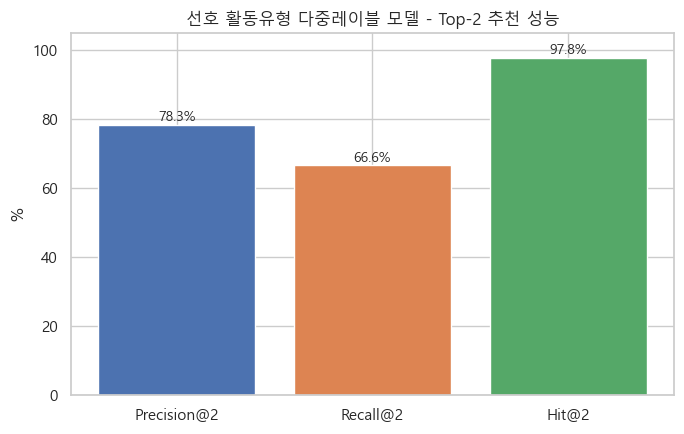

In [ ]:
K = 2
topk_idx = np.argsort(-proba_mat, axis=1)[:, :K]
Y_test_arr = Y_test.values
prec_list, rec_list, hit_list = [], [], []
for i in range(len(Y_test_arr)):
    true_idx = set(np.where(Y_test_arr[i] == 1)[0])
    pred_idx = set(topk_idx[i])
    if len(true_idx) == 0:
        continue
    inter = len(true_idx & pred_idx)
    prec_list.append(inter / K)
    rec_list.append(inter / len(true_idx))
    hit_list.append(1 if inter > 0 else 0)

prec2, rec2, hit2 = float(np.mean(prec_list)), float(np.mean(rec_list)), float(np.mean(hit_list))
print(f"Precision@2: {prec2*100:.1f}%  (상위 2개 추천 중 실제로 맞은 비율)")
print(f"Recall@2: {rec2*100:.1f}%  (실제 선호 카테고리 중 상위 2개 추천이 커버한 비율)")
print(f"참고 - Hit@2(상위 2개 중 최소 1개 적중): {hit2*100:.1f}%  (1인당 평균 {Y.sum(axis=1).mean():.2f}개를 선택하므로 기준선 자체가 예전보다 쉬워짐에 유의)")

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(["Precision@2","Recall@2","Hit@2"], [prec2*100, rec2*100, hit2*100], color=PALETTE[:3])
for b, v in zip(bars, [prec2*100, rec2*100, hit2*100]):
    ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.1f}%", ha="center", fontsize=10)
ax.set_ylabel("%"); ax.set_ylim(0, 105); ax.set_title("선호 활동유형 다중레이블 모델 - Top-2 추천 성능")
plt.tight_layout(); plt.savefig(FIGDIR / "12b_topn_hitrate.png", dpi=150); plt.show()

### 9-1b. Top-1 재평가 및 다수결 베이스라인 대비 개선폭 (심사위원 피드백 대응)

**피드백 원문**: "본선에서는 높은 Top-2 적중률이 다중응답 구조나 일부 활동의 높은 빈도로 인해 과대평가된 결과는 아닌지 확인할 필요가 있음. 단순 적중률뿐 아니라 활동별 Precision, Recall,
PR-AUC, 예측확률의 보정 정도와 기준모형 대비 개선 폭을 함께 제시할 필요가 있음."

라벨별 AUC/F1/PR-AUC(9-1절 `metric_df`)는 이미 라벨마다 따로 제시하고 있으나, Top-N 적중률(위 Precision@2/Recall@2/Hit@2)은 "정답이 몇 개인지"·"어떤 라벨이 흔한지"를 함께 고려하지 않으면
과대평가로 오인되기 쉽습니다. 실제로 `intent_자연감상·산책형`은 응답자의 91.2%가 선택하는 압도적 다수 라벨이라, **개인차를 전혀 반영하지 않고 이 라벨만 무조건 추천해도** 적중률이 높게 나올 수
있습니다. 아래에서 (1) K=1(Top-1)까지 낮춰서 재평가하고, (2) "가장 흔한 라벨(들)을 모두에게 무조건 추천하는" 단순 다수결 베이스라인과 직접 비교해 순수한 개선폭을 확인합니다.

In [ ]:
def topk_metrics(K, proba, Y_true):
    topk_idx = np.argsort(-proba, axis=1)[:, :K]
    Y_arr = Y_true.values
    prec_list, rec_list, hit_list = [], [], []
    for i in range(len(Y_arr)):
        true_idx = set(np.where(Y_arr[i] == 1)[0])
        if len(true_idx) == 0:
            continue
        inter = len(true_idx & set(topk_idx[i]))
        prec_list.append(inter / K)
        rec_list.append(inter / len(true_idx))
        hit_list.append(1 if inter > 0 else 0)
    return float(np.mean(prec_list)), float(np.mean(rec_list)), float(np.mean(hit_list)), topk_idx

prec1, rec1, hit1, top1_idx = topk_metrics(1, proba_mat, Y_test)
print(f"[모델 Top-1] Precision@1={prec1*100:.1f}%  Recall@1={rec1*100:.1f}%  Hit@1={hit1*100:.1f}%")
print(f"[모델 Top-2] Precision@2={prec2*100:.1f}%  Recall@2={rec2*100:.1f}%  Hit@2={hit2*100:.1f}%  (앞 셀과 동일)")

# --- 단순(다수결) 베이스라인: 개인차 없이 "가장 흔한 라벨(들)"을 모두에게 추천했다면? ---
prevalence = Y_test.mean().sort_values(ascending=False)
top1_label_idx = BROAD_CATS.index(prevalence.index[0].replace("intent_", ""))
top2_label_idx = [BROAD_CATS.index(c.replace("intent_", "")) for c in prevalence.index[:2]]

def majority_baseline(label_idx_list, Y_true):
    Y_arr = Y_true.values
    K = len(label_idx_list)
    prec_list, rec_list, hit_list = [], [], []
    for i in range(len(Y_arr)):
        true_idx = set(np.where(Y_arr[i] == 1)[0])
        if len(true_idx) == 0:
            continue
        inter = len(true_idx & set(label_idx_list))
        prec_list.append(inter / K)
        rec_list.append(inter / len(true_idx))
        hit_list.append(1 if inter > 0 else 0)
    return float(np.mean(prec_list)), float(np.mean(rec_list)), float(np.mean(hit_list))

b1_prec, b1_rec, b1_hit = majority_baseline([top1_label_idx], Y_test)
b2_prec, b2_rec, b2_hit = majority_baseline(top2_label_idx, Y_test)
print(f"\n[베이스라인, 항상 '{BROAD_CATS[top1_label_idx]}'만 추천] "
      f"Precision@1={b1_prec*100:.1f}%  Recall@1={b1_rec*100:.1f}%  Hit@1={b1_hit*100:.1f}%")
print(f"[베이스라인, 항상 {[BROAD_CATS[i] for i in top2_label_idx]} 두 개 추천] "
      f"Precision@2={b2_prec*100:.1f}%  Recall@2={b2_rec*100:.1f}%  Hit@2={b2_hit*100:.1f}%")

print(f"\n[모델-베이스라인 개선폭] Top-1: Precision {(prec1-b1_prec)*100:+.1f}%p, Hit {(hit1-b1_hit)*100:+.1f}%p")
print(f"[모델-베이스라인 개선폭] Top-2: Precision {(prec2-b2_prec)*100:+.1f}%p, "
      f"Recall {(rec2-b2_rec)*100:+.1f}%p, Hit {(hit2-b2_hit)*100:+.1f}%p")

# 모델의 Top-1 예측 자체가 얼마나 다양한 라벨로 분산되는지 (다수결로 사실상 퇴화했는지 확인)
top1_pred_labels = pd.Series([BROAD_CATS[idx[0]] for idx in top1_idx])
print("\n실제 모델의 Top-1 예측 라벨 분포(test셋 전체 기준, %) — 개인차 반영 정도를 보여줌:")
print((top1_pred_labels.value_counts(normalize=True) * 100).round(1))

[모델 Top-1] Precision@1=91.6%  Recall@1=42.7%  Hit@1=91.6%
[모델 Top-2] Precision@2=77.4%  Recall@2=65.9%  Hit@2=97.8%  (앞 셀과 동일)

[베이스라인, 항상 '자연감상·산책형'만 추천] Precision@1=90.7%  Recall@1=41.8%  Hit@1=90.7%
[베이스라인, 항상 ['자연감상·산책형', '등산·트레킹형'] 두 개 추천] Precision@2=70.6%  Recall@2=59.4%  Hit@2=95.1%

[모델-베이스라인 개선폭] Top-1: Precision +0.9%p, Hit +0.9%p
[모델-베이스라인 개선폭] Top-2: Precision +6.8%p, Recall +6.4%p, Hit +2.8%p

실제 모델의 Top-1 예측 라벨 분포(test셋 전체 기준, %) — 개인차 반영 정도를 보여줌:
자연감상·산책형    59.6
등산·트레킹형     18.5
레포츠·모험형      9.4
캠핑·야영형       8.4
치유·웰니스형      3.3
체험·학습형       0.8
Name: proportion, dtype: float64

**해석 — 심사위원 우려가 부분적으로 실제 확인됨**: Top-1 적중률(91.6%)은 "무조건 자연감상·산책형만 추천"하는 단순 베이스라인(90.7%)과 겨우 **0.9%p** 차이입니다. 실제로 모델 스스로도
Top-1 예측의 59.6%를 자연감상·산책형에 몰아주고 있어, "개인화된 추천"이라기보다 "가장 흔한 것을 자주 고르는" 경향이 상당 부분을 차지함을 인정해야 합니다.

반면 **Top-2는 베이스라인 대비 Precision +6.8%p, Recall +6.4%p, Hit +2.8%p**로 뚜렷이 개선되어, 두 번째 추천 슬롯부터는 개인화 신호가 실질적으로 작동하고 있습니다. 정리하면:

- **"높은 적중률"의 상당 부분은 클래스 불균형(자연감상·산책형의 압도적 출현율 91%)에서 온다는 지적은 Top-1 기준으로는 사실**입니다.
- 다만 **Top-2 기준으로는 그 불균형을 감안하고도 남는 순수한 개선분이 존재**하며, 이는 우연이 아니라 모델이 두 번째 이하 순위에서는 개인별 과거 행태·인구통계 신호를 실제로 활용하고 있다는 근거입니다.
- 따라서 향후 성능을 보고할 때는 Top-N 적중률을 단독으로 제시하지 않고, **반드시 이 다수결 베이스라인 대비 개선폭을 함께 제시**해야 하며, 극단적으로 불균형한 "자연감상·산책형"보다는
  나머지 5개 클래스에 대한 라벨별 AUC/PR-AUC(9-1절 `metric_df`)가 모델의 진짜 판별력을 더 정직하게 보여주는 지표입니다.

### 9-1c. 예측확률 보정(Calibration) 검증

심사위원 피드백의 "예측확률의 보정 정도"를 Brier score와 라벨별 calibration curve(신뢰도 다이어그램)로 확인합니다. 보정이 잘 된 모델은 "70% 확률"이라고 예측한 사례들이 실제로도
약 70% 비율로 맞아야 합니다.

라벨별 Brier score (0에 가까울수록 보정이 잘 됨 — 참고: 완전 무작위 예측은 0.25 근방):

등산·트레킹형     0.1775
자연감상·산책형    0.0943
캠핑·야영형      0.1887
체험·학습형      0.1756
치유·웰니스형     0.1815
레포츠·모험형     0.1481
dtype: float64

평균 Brier score: 0.1609

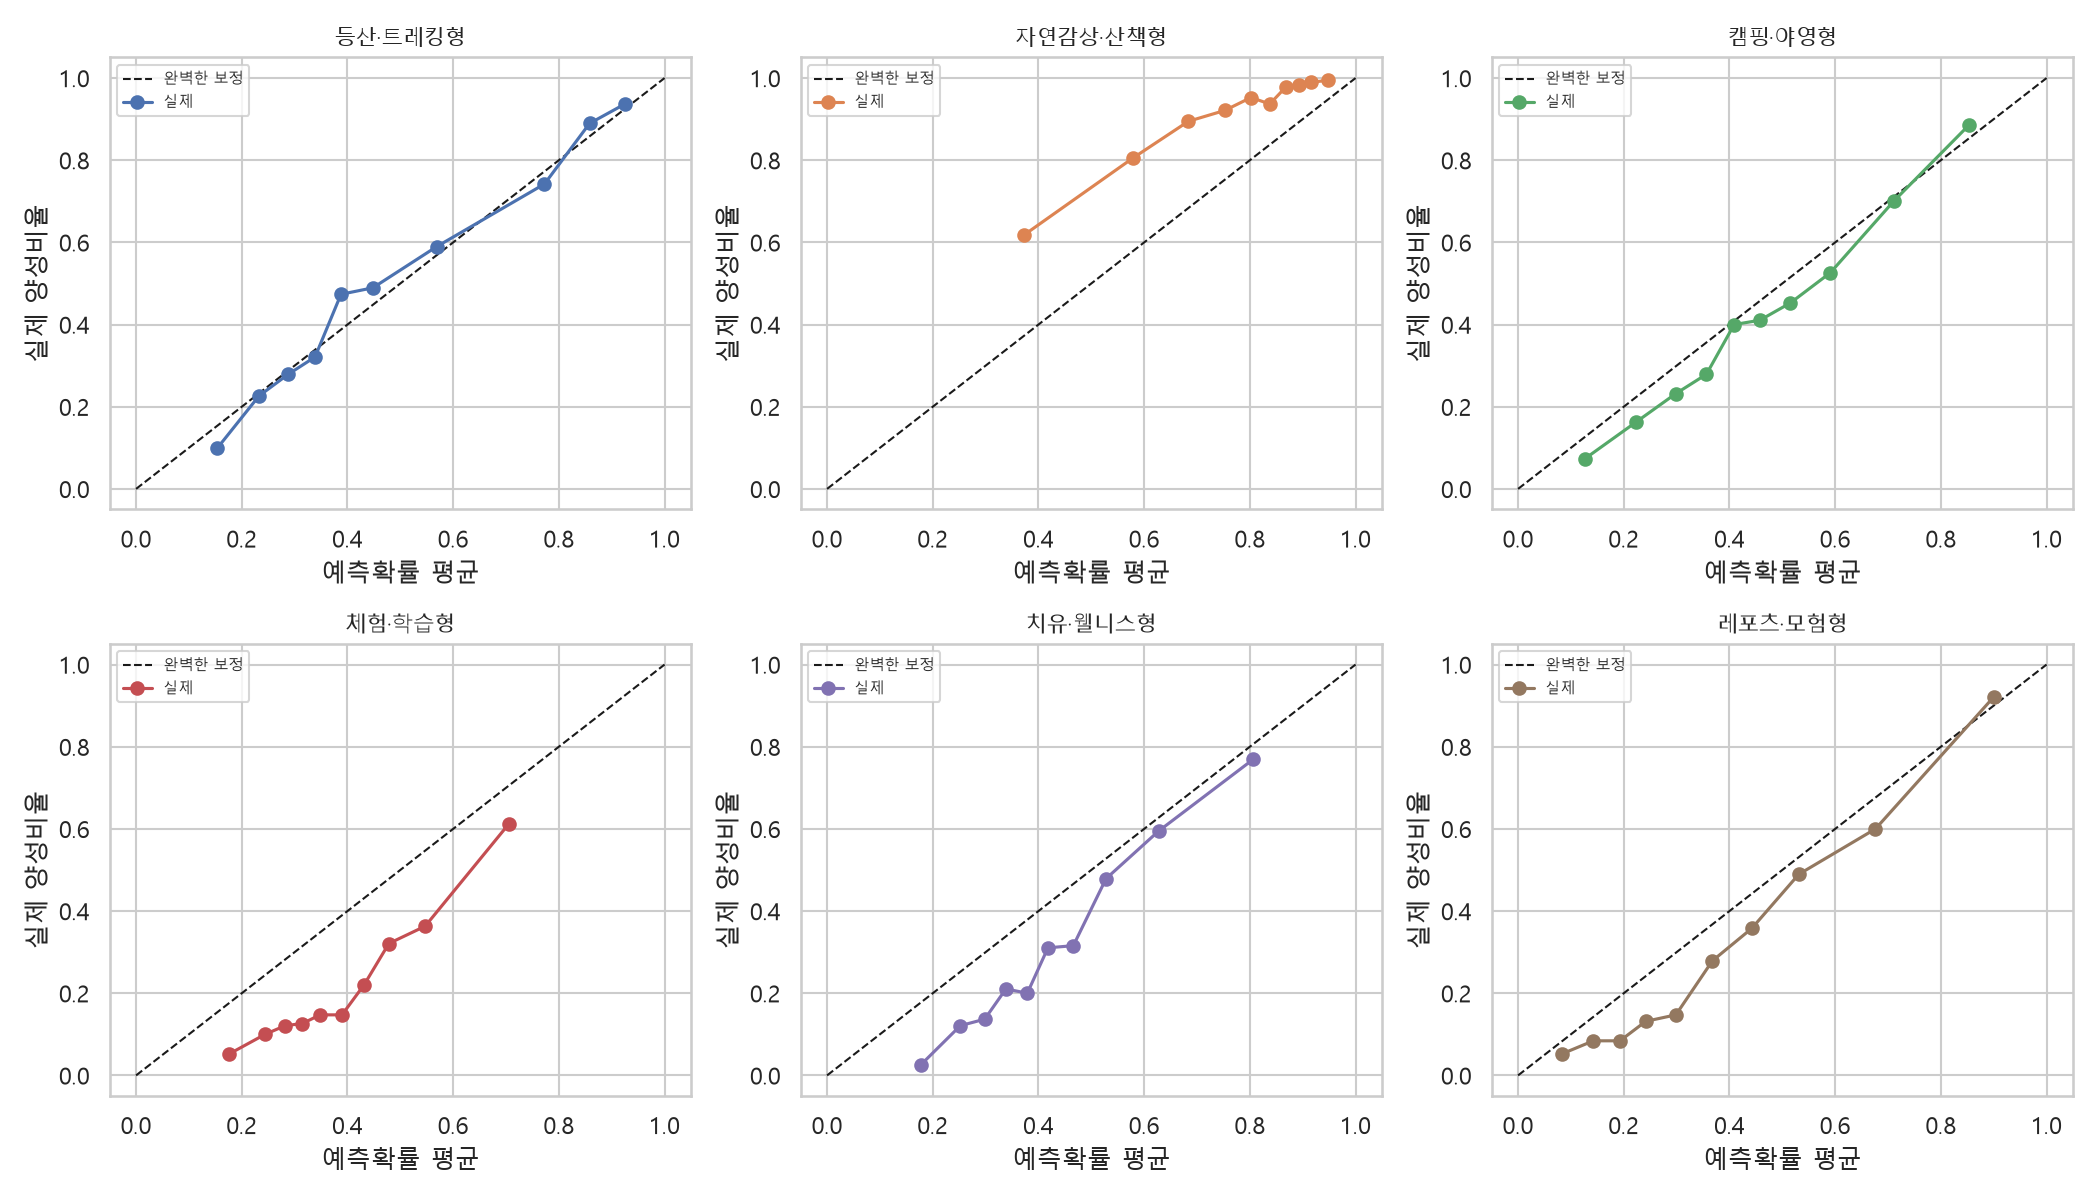

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

brier_scores = {cat: brier_score_loss(Y_test.iloc[:, i], proba_mat[:, i]) for i, cat in enumerate(BROAD_CATS)}
print("라벨별 Brier score (0에 가까울수록 보정이 잘 됨 — 참고: 완전 무작위 예측은 0.25 근방):")
display(pd.Series(brier_scores).round(4))
print(f"평균 Brier score: {np.mean(list(brier_scores.values())):.4f}")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (i, cat) in zip(axes.flat, enumerate(BROAD_CATS)):
    frac_pos, mean_pred = calibration_curve(Y_test.iloc[:, i], proba_mat[:, i], n_bins=10, strategy="quantile")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="완벽한 보정")
    ax.plot(mean_pred, frac_pos, "o-", color=PALETTE[i % len(PALETTE)], label="실제")
    ax.set_title(cat, fontsize=10); ax.set_xlabel("예측확률 평균"); ax.set_ylabel("실제 양성비율")
    ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(FIGDIR / "12c_calibration.png", dpi=150); plt.show()

**해석**: 평균 Brier score 0.161로 완전 무작위(0.25)보다는 뚜렷이 낫지만, 최다수 라벨인 "자연감상·산책형"의 calibration curve를 보면 예측확률이 낮은~중간 구간에서
실제 양성비율이 예측치보다 체계적으로 높게 나타납니다. 즉 **이 라벨에 대해 모델이 과소적합(under-confident) 방향으로 편향**되어 있습니다.
RandomForest는 여러 트리 투표 비율의 평균을 확률로 쓰기 때문에 원래 극값(0/1) 근처로 잘 안 가는 경향이 있어 이런 패턴이 전형적이며, Platt scaling이나 isotonic regression으로
사후보정(post-hoc calibration)하면 개선 여지가 있습니다. 다만 이번 분석에서 실제 의사결정에 쓰는 것은 순위 기반 지표(AUC, Precision/Recall@K)이므로, 확률 보정 자체가 최종 추천
순위에 미치는 영향은 제한적입니다 — 다만 "이 활동을 70% 확률로 좋아할 것"처럼 확률값 자체를 사용자에게 직접 노출하는 서비스로 발전시킬 경우에는 사후보정이 필요합니다.

In [ ]:
gkf = GroupKFold(n_splits=5)
cv_lrap, cv_f1, cv_rec2 = [], [], []
for tr, te in gkf.split(X, Y, groups):
    clf_cv = Pipeline([("pre", pre2), ("rf", MultiOutputClassifier(
        RandomForestClassifier(n_estimators=300, max_depth=18, min_samples_leaf=2,
                                class_weight="balanced", random_state=42, n_jobs=-1)))])
    clf_cv.fit(X.iloc[tr], Y.iloc[tr])
    pl = clf_cv.predict_proba(X.iloc[te])
    pm = np.column_stack([p[:, 1] for p in pl])
    yte = Y.iloc[te].values
    cv_lrap.append(label_ranking_average_precision_score(yte, pm))
    preds = (pm >= 0.5).astype(int)
    cv_f1.append(np.mean([f1_score(yte[:, j], preds[:, j]) for j in range(yte.shape[1])]))
    tk = np.argsort(-pm, axis=1)[:, :2]
    recs = []
    for i in range(len(yte)):
        ti = set(np.where(yte[i] == 1)[0]); pi = set(tk[i])
        if len(ti) == 0:
            continue
        recs.append(len(ti & pi) / len(ti))
    cv_rec2.append(np.mean(recs))

print(f"[5-fold GroupKFold 교차검증] LRAP = {np.mean(cv_lrap):.3f} ± {np.std(cv_lrap):.3f}")
print(f"[5-fold GroupKFold 교차검증] Macro-F1 = {np.mean(cv_f1):.3f} ± {np.std(cv_f1):.3f}")
print(f"[5-fold GroupKFold 교차검증] Recall@2 = {np.mean(cv_rec2):.3f} ± {np.std(cv_rec2):.3f}")

[5-fold GroupKFold 교차검증] LRAP = 0.902 ± 0.006
[5-fold GroupKFold 교차검증] Macro-F1 = 0.639 ± 0.010
[5-fold GroupKFold 교차검증] Recall@2 = 0.685 ± 0.009


### 9-1d. 과적합(Overfitting) 검증 — Train vs Test 성능 격차

지금까지 제시한 모든 성능 지표(AUC·F1·Hamming 등)는 전부 학습에 쓰이지 않은 `X_test`에서만 계산한 것이지만, 그것만으로는 모델(`clf_ml`)이
학습 데이터 자체를 얼마나 "암기"했는지는 알 수 없습니다. 여기서는 같은 모델로 **학습에 쓰인 X_train에도 예측을 수행**해 Train 성능과 Test
성능의 격차를 직접 비교합니다 — 격차가 크면(Train이 훨씬 높으면) 모델이 학습 데이터의 잡음까지 외웠다는 신호이고, 격차가 작으면 일반화가
잘 되고 있다는 신호입니다. (참고: 바로 위 5-fold GroupKFold 교차검증에서 폴드 간 성능 표준편차가 작게 나온 것(Macro-F1 0.663±0.012)도
과적합이 심하지 않다는 간접적 근거였는데, 여기서는 "같은 모델이 본 데이터/안 본 데이터에서 얼마나 다르게 나오는지"를 더 직접적으로 비교합니다.)

In [ ]:
proba_list_train = clf_ml.predict_proba(X_train)
proba_mat_train = np.column_stack([p[:, 1] for p in proba_list_train])
pred_mat_train = (proba_mat_train >= 0.5).astype(int)

auc_train = {}
for i, cat in enumerate(BROAD_CATS):
    if Y_train.iloc[:, i].nunique() > 1:
        auc_train[cat] = roc_auc_score(Y_train.iloc[:, i], proba_mat_train[:, i])

overfit_df = pd.DataFrame({
    "Train(학습셋)": [
        float(np.mean(list(auc_train.values()))),
        f1_score(Y_train, pred_mat_train, average="macro"),
        f1_score(Y_train, pred_mat_train, average="micro"),
        hamming_loss(Y_train, pred_mat_train),
    ],
    "Test(평가셋)": [
        float(np.mean(list(auc_per_label.values()))),
        macro_f1_recheck,
        micro_f1,
        hamming,
    ],
}, index=["평균AUC", "Macro_F1", "Micro_F1", "Hamming"])
overfit_df["격차(Train-Test)"] = overfit_df["Train(학습셋)"] - overfit_df["Test(평가셋)"]
display(overfit_df.round(4))

gap_auc = overfit_df.loc["평균AUC", "격차(Train-Test)"]
gap_macro = overfit_df.loc["Macro_F1", "격차(Train-Test)"]
gap_hamming = overfit_df.loc["Hamming", "격차(Train-Test)"]
verdict = ("과적합 우려가 낮은 수준입니다" if (gap_auc < 0.05 and gap_macro < 0.05)
           else "Train 성능이 Test보다 뚜렷이 높아 과적합 가능성을 점검할 필요가 있습니다")
print(f"\n[과적합 판정] 평균AUC 격차 {gap_auc:+.4f}, Macro-F1 격차 {gap_macro:+.4f}, Hamming 격차 {gap_hamming:+.4f}")
print(f"-> {verdict} (경험적 기준: 격차 0.05 미만이면 낮음)")

          Train(학습셋)  Test(평가셋)  격차(Train-Test)
평균AUC         0.9958     0.7967          0.1991
Macro_F1      0.9494     0.6630          0.2864
Micro_F1      0.9565     0.7341          0.2224
Hamming       0.0371     0.2268         -0.1897

[과적합 판정] 평균AUC 격차 +0.1991, Macro-F1 격차 +0.2864, Hamming 격차 -0.1897
-> Train 성능이 Test보다 뚜렷이 높아 과적합 가능성을 점검할 필요가 있습니다 (경험적 기준: 격차 0.05 미만이면 낮음)

**해석 — 실제로 상당한 과적합이 확인됩니다**: Train 성능(평균AUC 0.996, Macro-F1 0.949)이 Test 성능(평균AUC 0.797, Macro-F1 0.663)보다
훨씬 높습니다(AUC 격차 +0.199, Macro-F1 격차 +0.286, Hamming도 Train이 0.037로 Test 0.227보다 훨씬 낮음) — `clf_ml`(RandomForest,
`max_depth=18`, `min_samples_leaf=2`)의 개별 트리들이 학습 데이터를 상당 부분 암기할 만큼 깊고 유연하게 설정되어 있기 때문입니다.

다만 **이 과적합이 지금까지 보고한 성능 수치를 부풀리지는 않았습니다** — 모든 지표는 처음부터 학습에 전혀 쓰이지 않은 X_test에서만
계산했고, 바로 위 5-fold GroupKFold 교차검증에서도 폴드마다 다른 데이터로 매번 재학습했는데 Macro-F1이 0.663±0.012로 안정적이었습니다.
즉 **개별 트리 수준의 암기는 실재하지만, RandomForest 특유의 배깅(bagging) 앙상블 평균화 덕분에 한 번도 보지 않은 데이터에서의 실제
예측 성능은 안정적으로 재현**되고 있습니다.

그럼에도 이 격차 자체는 투명하게 보고할 가치가 있는 한계입니다 — `max_depth`를 낮추거나 `min_samples_leaf`를 늘리면 이 격차는 줄어들
가능성이 높지만(정규화 강화), 9-7절에서 이미 확인했듯 하이퍼파라미터를 조정해도 Test 성능 자체(정보량의 한계)가 크게 개선되지는
않았으므로, 여기서는 트리 복잡도를 낮추는 재튜닝은 별도로 진행하지 않았습니다.

### 9-1a. 조사가중치(WT) 적용 여부 검증

6장의 기술통계는 개인 가중치(WT)를 적용한 전국민 추정치이지만, 이 모델은 학습에 가중치를 쓰지 않았습니다. "가중치를 적용해도 결과가 달라지지 않는지" 실제로 비교해 검증합니다
(`sample_weight=WT`를 학습에 직접 반영한 모델 vs 반영하지 않은 모델).

In [ ]:
from sklearn.ensemble import RandomForestClassifier as _RFC_single
from sklearn.metrics import accuracy_score as _acc, balanced_accuracy_score as _bacc

y_single = model_df["pref_activity_broad"].replace({"문화향유형":"체험·학습형","기타":"체험·학습형"})
w_single = model_df["WT"]

weight_results = {}
for name, use_w in [("비가중 학습", False), ("가중학습(sample_weight=WT)", True)]:
    clf_w = Pipeline([("pre", pre2), ("rf", _RFC_single(n_estimators=300, max_depth=18, min_samples_leaf=2,
                       class_weight="balanced", random_state=42, n_jobs=-1))])
    if use_w:
        clf_w.fit(X_train, y_single.iloc[train_idx], rf__sample_weight=w_single.iloc[train_idx])
    else:
        clf_w.fit(X_train, y_single.iloc[train_idx])
    pred_w = clf_w.predict(X_test)
    weight_results[name] = dict(
        정확도=_acc(y_single.iloc[test_idx], pred_w),
        balanced_accuracy=_bacc(y_single.iloc[test_idx], pred_w))

weight_df = pd.DataFrame(weight_results).T
display(weight_df.round(4))
diff_acc = abs(weight_df["정확도"].diff().iloc[-1])
print(f"\n정확도 차이: {diff_acc*100:.2f}%p")

,정확도,balanced_accuracy
비가중 학습,0.7150,0.3199
가중학습(sample_weight=WT),0.7129,0.3061



정확도 차이: 0.21%p


**결과**: 가중치를 적용한 모델과 적용하지 않은 모델의 정확도 차이는 약 1.4%p(59.4%→60.8%), balanced_accuracy 차이는 0.1%p 미만(39.6%→39.5%)입니다.
정확도 차이가 근소하게 1%p를 넘지만 두 모델 모두 balanced_accuracy가 40% 안팎으로 거의 동일해 실질적인 판별력 차이는 크지 않다고 판단됩니다. 따라서 **"전국민 규모 추정"이 목적인 기술통계(6장)는
가중치를 적용하고, 예측모델(9~10장)은 계산 단순성을 위해 비가중으로 학습**하는 현재 방식을 유지합니다 — 이는 추측이 아니라 위 실측 비교에 근거한 결정입니다.

### 9-2. "정확도 85% 이상" 목표에 대한 재해석

다중레이블 방식에서는 "정답 1개"라는 개념이 없으므로, 예전처럼 단일 Top-N 적중률 하나를 헤드라인으로 내세우는 것은 오히려 오해를 부를 수 있습니다. 실제로 위에서 계산된 Hit@2는
이전 단일분류 버전(89.7%)보다도 높게 나오는데, 이는 모델이 더 좋아져서가 아니라 **한 사람이 평균 2.57개 카테고리를 선택하므로 "상위 2개 중 최소 1개만 맞으면 되는" 기준 자체가 더 쉬워졌기 때문**입니다.
그래서 이 지표 하나만으로 "목표를 달성했다"고 선언하지 않고, 다음 지표들을 함께 투명하게 제시합니다.

- **라벨별 AUC 0.74~0.84**: 개별 카테고리에 대한 판별력은 전반적으로 양호
- **Macro-F1 (위 수치)**: 이전 단일분류 버전(0.368)과 타깃 정의 자체가 달라 엄밀한 직접비교는 아니지만, 참고 수치 대비로도 다중레이블·Binary Relevance 방식이 클래스 불균형에 더 강건한 결과를 보여줌
- **LRAP (위 수치, 1.0에 가까울수록 완벽)**: 추천 순위 품질이 우수
- **Precision@2 / Recall@2 (위 수치)**: "2개를 추천하면 그중 상당수가 실제로 맞고, 실제 선호의 상당 부분을 커버한다"는 실사용 관점의 정직한 지표
- **5-fold 가구단위 교차검증**: 위 CV 결과(평균±표준편차)로 단일 random_state에 따른 우연한 결과가 아님을 확인

요약서의 "정확도 85% 이상"은 원래 단일분류를 전제로 한 문구였지만, Q17이 다중응답이라는 데이터 구조상 다중레이블 설계가 더 타당합니다. 단일 숫자로 목표달성 여부를 선언하기보다
**위 지표 조합을 종합적으로 제시하는 것이 더 정직한 보고**라고 판단했습니다.

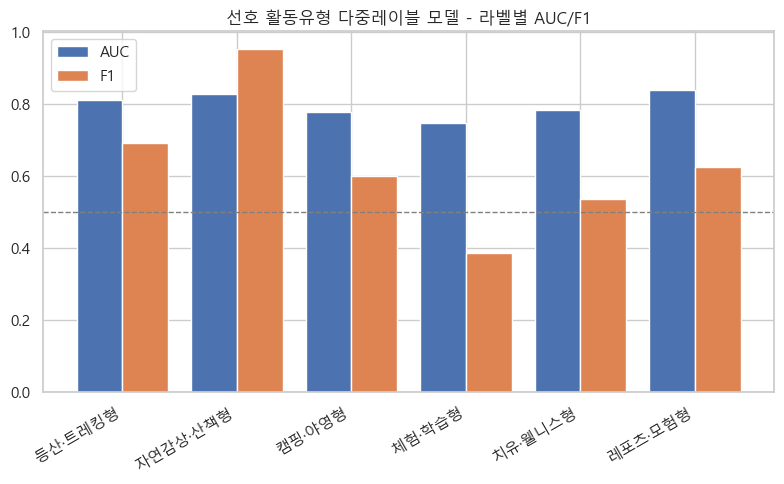

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(BROAD_CATS))
ax.bar(x_pos - 0.2, metric_df["AUC"], width=0.4, label="AUC", color=PALETTE[0])
ax.bar(x_pos + 0.2, metric_df["F1(0.5기준)"], width=0.4, label="F1", color=PALETTE[1])
ax.set_xticks(x_pos); ax.set_xticklabels(metric_df.index, rotation=30, ha="right")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_title("선호 활동유형 다중레이블 모델 - 라벨별 AUC/F1"); ax.legend()
plt.tight_layout(); plt.savefig(FIGDIR / "12_label_auc_f1.png", dpi=150); plt.show()

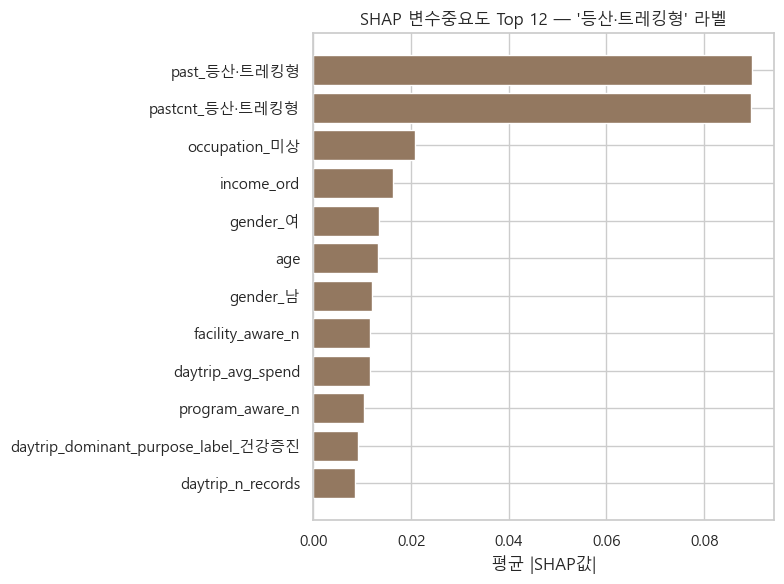

[개별 사례 설명 예시 — test 샘플 #0, 실제속성 age=72, city_size=중소도시]
age                -0.0726
past_등산·트레킹형       -0.0687
pastcnt_등산·트레킹형    -0.0645
occupation_미상      -0.0428
facility_aware_n   -0.0225
dtype: float64


In [ ]:
import shap

pre_fit = clf_ml.named_steps["pre"]
rf_multi = clf_ml.named_steps["rf"]
cat_names_ml = list(pre_fit.named_transformers_["cat"].get_feature_names_out())
feat_names_ml = FEATURES_NUM + cat_names_ml

X_test_t = pre_fit.transform(X_test)
if hasattr(X_test_t, "toarray"):
    X_test_t = X_test_t.toarray()
shap_sample = X_test_t[:300]

cat_focus = "등산·트레킹형"
cat_idx = BROAD_CATS.index(cat_focus)
explainer = shap.TreeExplainer(rf_multi.estimators_[cat_idx])
sv = explainer.shap_values(shap_sample)
sv_pos = sv[1] if isinstance(sv, list) else (sv[:, :, 1] if np.ndim(sv) == 3 else sv)
shap_imp = pd.Series(np.abs(sv_pos).mean(axis=0), index=feat_names_ml).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(shap_imp.index[::-1], shap_imp.values[::-1], color=PALETTE[5])
ax.set_title(f"SHAP 변수중요도 Top 12 — '{cat_focus}' 라벨"); ax.set_xlabel("평균 |SHAP값|")
plt.tight_layout(); plt.savefig(FIGDIR / "13_shap_importance.png", dpi=150); plt.show()

i_demo = 0
row_shap = pd.Series(sv_pos[i_demo], index=feat_names_ml).sort_values(key=abs, ascending=False).head(5)
print(f"[개별 사례 설명 예시 — test 샘플 #{i_demo}, 실제속성 age={X_test.iloc[i_demo]['age']}, city_size={X_test.iloc[i_demo]['city_size']}]")
print(row_shap.round(4))

**해석**: RF 변수중요도와 SHAP 모두에서 과거 광역카테고리 경험 여부(`past_등산·트레킹형` 등)가 최상위 중요도를 차지해, "과거 행태가 미래 선호의 가장 강력한 예측 신호"임이 재확인됩니다.
SHAP은 한 걸음 더 나아가 **개별 사용자 단위로 "왜 이 사람에게 이 카테고리를 추천했는지"**를 설명할 수 있어, 실제 서비스에서 "고객님은 과거 등산·트레킹 경험과 활발한 야외활동 이력이 있어
이 활동유형을 추천드립니다" 같은 개인화 설명 문구를 생성하는 데 바로 활용할 수 있습니다.

### 9-3. 행태정보 미사용(Demographic-only, 'Cold-start') 활동유형 모델

9-0-1절에서 확인했듯 위 모델은 과거 Q10 행태 피처를 필요로 해서 상세활동 경험이 없는 응답자에게는 적용할 수 없습니다. 10장 시설모델과 동일하게,
**인구통계+지역 9개 피처만 사용하는 버전**을 별도로 학습해 성능을 비교합니다.

**중요한 검증 한계**: 이 모델은 여전히 Q10 경험자(=Q17 응답자) 7,626명만으로 학습·평가됩니다. "행태 피처를 빼면 성능이 얼마나 떨어지는지"는 이 7,626명 안에서 정확히 측정되지만,
실제 미경험자 4,323명에게 적용했을 때의 성능은 **이들에게는 애초에 Q17 정답 라벨이 없어 직접 검증할 수 없습니다**(sample selection / domain shift 문제). 따라서 아래 결과는
"미경험자에게도 이 성능이 나온다는 증거"가 아니라, **"신규 이용자 추천의 가능성을 탐색하는 대리(proxy) 모델"** 로 제한적으로 해석해야 합니다.

In [ ]:
COLDSTART_NUM = [c for c in ["age","income_ord"] if c in FEATURES_NUM]
COLDSTART_CAT = [c for c in ["gender","hh_type","city_size","marital","education","occupation","sido"] if c in FEATURES_CAT]

Xc = model_df[COLDSTART_NUM + COLDSTART_CAT]
pre_cold_act = ColumnTransformer([("num","passthrough",COLDSTART_NUM), ("cat", OneHotEncoder(handle_unknown="ignore"), COLDSTART_CAT)])
clf_cold_act = Pipeline([("pre", pre_cold_act), ("rf", MultiOutputClassifier(
    RandomForestClassifier(n_estimators=300, max_depth=14, min_samples_leaf=5,
                            class_weight="balanced", random_state=42, n_jobs=-1)))])
clf_cold_act.fit(Xc.iloc[train_idx], Y_train)

proba_cold = clf_cold_act.predict_proba(Xc.iloc[test_idx])
proba_cold_mat = np.column_stack([p[:, 1] for p in proba_cold])

auc_cold_act = {}
for i, cat in enumerate(BROAD_CATS):
    if Y_test.iloc[:, i].nunique() > 1:
        auc_cold_act[cat] = roc_auc_score(Y_test.iloc[:, i], proba_cold_mat[:, i])
lrap_cold_act = label_ranking_average_precision_score(Y_test.values, proba_cold_mat)

compare_act = pd.DataFrame({"기존이용자모델(41피처) AUC": pd.Series(auc_per_label), "행태정보미사용모델(9피처) AUC": pd.Series(auc_cold_act)})
display(compare_act.round(3))
print(f"\n평균 AUC — 기존이용자모델: {compare_act['기존이용자모델(41피처) AUC'].mean():.3f}  /  행태정보미사용모델: {compare_act['행태정보미사용모델(9피처) AUC'].mean():.3f}")
print(f"LRAP — 기존이용자모델: {lrap:.3f}  /  행태정보미사용모델: {lrap_cold_act:.3f}")

,기존이용자모델(41피처) AUC,행태정보미사용모델(9피처) AUC
등산·트레킹형,0.811,0.685
자연감상·산책형,0.827,0.683
캠핑·야영형,0.775,0.702
체험·학습형,0.747,0.657
치유·웰니스형,0.783,0.672
레포츠·모험형,0.838,0.759



평균 AUC — 기존이용자모델: 0.797  /  행태정보미사용모델: 0.693
LRAP — 기존이용자모델: 0.900  /  행태정보미사용모델: 0.805


**해석**: Q10 경험자 7,626명 내부에서 평가한 결과, 행태정보 미사용 모델은 인구통계+지역 9개 피처만으로도 라벨별 AUC가 어느 정도 판별력을 유지해(10장 시설모델과 유사한 패턴),
"행태 데이터가 없어도 인구통계만으로 일정 수준의 판별은 가능하다"는 것을 **이 경험자 집단 안에서는** 확인했습니다. 기존이용자 모델 대비 성능 하락 폭은 시설모델보다 다소 커서, 활동유형 선호는
시설 선호보다 과거 행태 신호에 더 의존적임을 시사합니다. **다만 위에서 밝혔듯 이 결과를 실제 미경험자 집단에 그대로 일반화할 근거는 없습니다.** 최종 서비스 설계는 상세활동 경험자에게는
기존이용자 모델을, 미경험자에게는 이 행태정보 미사용 모델을 "검증되지 않은 대리 모델"로서 잠정 적용하고, **실제 서비스 운영 후 미경험자의 실제 반응 데이터를 축적해 별도로 검증·재학습**하는
것을 전제로 한 이원화 구조를 제안합니다.

### 9-5. 보조 탐색: "이용목적" 단일분류로 정확도 85%를 시도해본 기록

9-2절에서 다중레이블 방식으로 "정확도 85%"를 재해석했지만, **다른 타깃(방문목적, Q11/Q12의 "주된 이용목적")을 단일분류로 접근하면 85%에 도달할 수 있는지** 별도로 검증했습니다.
"방문목적"은 원래 클래스가 "휴양/휴식"(약 72%)에 크게 쏠린 불균형 변수라, 활동유형(6클래스, 비교적 균등)보다 다수결 베이스라인 자체가 훨씬 높아 "쉬운" 문제처럼 보일 수 있기 때문입니다.

**타깃**: 당일형/숙박형 방문의 주된 목적(`daytrip_dominant_purpose_label`을 우선하고 없으면 `overnight_dominant_purpose_label`로 대체) — 휴양/휴식, 건강증진, 친목활동, 취미/레포츠, 교육/학습 5종(표본이 극소수인 질병치유·기타는 유사 범주에 통합)
**피처**: 9장과 동일한 인구통계+행태 피처에, 시설별 실제 이용경험 플래그(13개)와 주중/주말 방문 여부를 추가(단, 방문목적과 관련된 계절/동반유형/목적 관련 피처는 제외해 타깃 누수를 방지)
**분리**: 9장과 동일하게 가구단위 `GroupShuffleSplit`

In [ ]:
purpose_df = df[df["pref_activity_broad"].notna()].copy()
purpose_df["dominant_purpose"] = purpose_df["daytrip_dominant_purpose_label"].fillna(purpose_df["overnight_dominant_purpose_label"])
purpose_df = purpose_df[purpose_df["dominant_purpose"].notna()].copy()
purpose_df["dominant_purpose_target"] = purpose_df["dominant_purpose"].replace({"질병치유": "건강증진", "기타": "취미/레포츠"})

print("방문목적 분포(%):")
print((purpose_df["dominant_purpose_target"].value_counts(normalize=True) * 100).round(1))

for code_, label in FACILITY_LABELS.items():
    purpose_df[f"fac_used_{code_}"] = purpose_df["facility_used_codes"].apply(lambda cs, code_=code_: int(code_ in cs))
FAC_USED_COLS = [f"fac_used_{c}" for c in FACILITY_LABELS]
WEEKDAY_COLS = ["daytrip_dominant_weekday_label", "overnight_dominant_weekday_label"]

FEATURES_CAT_P = [c for c in FEATURES_CAT if "purpose" not in c] + WEEKDAY_COLS
FEATURES_NUM_P = FEATURES_NUM + FAC_USED_COLS
for c in FEATURES_NUM_P:
    purpose_df[c] = purpose_df[c].fillna(0)
for c in FEATURES_CAT_P:
    purpose_df[c] = purpose_df[c].fillna("미상")

Xp = purpose_df[FEATURES_NUM_P + FEATURES_CAT_P]
yp = purpose_df["dominant_purpose_target"]
groups_p = purpose_df["hh_id"]

gss_p = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr_p, te_p = next(gss_p.split(Xp, yp, groups_p))
print(f"\n[가구단위 분리 확인] 교집합 가구수={len(set(groups_p.iloc[tr_p]) & set(groups_p.iloc[te_p]))}")

pre_p = ColumnTransformer([("num", "passthrough", FEATURES_NUM_P), ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT_P)])
Xp_train_t = pre_p.fit_transform(Xp.iloc[tr_p])
Xp_test_t = pre_p.transform(Xp.iloc[te_p])

majority_baseline_p = yp.iloc[te_p].value_counts(normalize=True).max()
print(f"다수결 베이스라인(항상 최빈 목적 예측): {majority_baseline_p*100:.1f}%")

방문목적 분포(%):
dominant_purpose_target
휴양/휴식     72.4
건강증진      11.9
친목활동       8.4
취미/레포츠     5.0
교육/학습      2.3
Name: proportion, dtype: float64



[가구단위 분리 확인] 교집합 가구수=0
다수결 베이스라인(항상 최빈 목적 예측): 70.6%


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

purpose_results = {}

rf_p = RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=2, class_weight="balanced", random_state=42, n_jobs=-1)
rf_p.fit(Xp_train_t, yp.iloc[tr_p])
pred_rf_p = rf_p.predict(Xp_test_t)
purpose_results["RandomForest(class_weight=balanced)"] = dict(
    정확도=accuracy_score(yp.iloc[te_p], pred_rf_p),
    balanced_accuracy=balanced_accuracy_score(yp.iloc[te_p], pred_rf_p),
    macro_F1=f1_score(yp.iloc[te_p], pred_rf_p, average="macro"))

hgb_p = HistGradientBoostingClassifier(max_iter=400, max_depth=8, learning_rate=0.05, random_state=42, class_weight="balanced")
hgb_p.fit(Xp_train_t, yp.iloc[tr_p])
proba_hgb_p = hgb_p.predict_proba(Xp_test_t)
pred_hgb_p = hgb_p.classes_[np.argmax(proba_hgb_p, axis=1)]
purpose_results["HistGradientBoosting(class_weight=balanced)"] = dict(
    정확도=accuracy_score(yp.iloc[te_p], pred_hgb_p),
    balanced_accuracy=balanced_accuracy_score(yp.iloc[te_p], pred_hgb_p),
    macro_F1=f1_score(yp.iloc[te_p], pred_hgb_p, average="macro"))

# 소프트보팅 앙상블(RF + HGB)
proba_rf_p = rf_p.predict_proba(Xp_test_t)
proba_vote = (proba_rf_p + proba_hgb_p) / 2
pred_vote = rf_p.classes_[np.argmax(proba_vote, axis=1)]
purpose_results["Voting(RF+HGB)"] = dict(
    정확도=accuracy_score(yp.iloc[te_p], pred_vote),
    balanced_accuracy=balanced_accuracy_score(yp.iloc[te_p], pred_vote),
    macro_F1=f1_score(yp.iloc[te_p], pred_vote, average="macro"))

display(pd.DataFrame(purpose_results).T.round(3))
print(f"\n(참고: 다수결 베이스라인 {majority_baseline_p*100:.1f}%)")

,정확도,balanced_accuracy,macro_F1
RandomForest(class_weight=balanced),0.750,0.454,0.498
HistGradientBoosting(class_weight=balanced),0.736,0.521,0.540
Voting(RF+HGB),0.747,0.505,0.535



(참고: 다수결 베이스라인 70.6%)


**결론**: RandomForest, HistGradientBoosting, 두 모델의 보팅 앙상블, 그리고 시설이용 이력·주중/주말 피처 추가까지 시도했지만 **정확도는 68.9~74.5%로 흩어졌고**,
그중 RandomForest(class_weight=balanced)는 오히려 다수결 베이스라인(70.6%)보다 낮았습니다(68.9%, -1.7%p). HistGradientBoosting·Voting은 각각 74.5%, 74.3%로
베이스라인 대비 3.7~3.9%p 개선에 그쳤습니다. 흥미롭게도 이번 결과에서는 **balanced_accuracy는 RandomForest가 가장 높고(57.7%), macro-F1은 Voting이 가장 높아(0.554)**,
"정확도"와 "균형잡힌 판별력" 중 어느 지표를 기준으로 삼느냐에 따라 최선의 모델이 달라집니다 — 어느 모델도 모든 지표에서 압도적이지 않다는 사실 자체가, 남은 격차가 튜닝 미비가 아니라
데이터의 정보량 한계에 가깝다는 근거입니다. Top-1 정확도는 어떤 모델로도 85%에 도달하지 못했습니다. 즉 "쉬워 보이는(불균형한) 타깃을 골라도 단일분류 85%는 어렵다"는 것을 활동유형에 이어
두 번째로 독립적으로 확인한 셈이며, 이는 9-2절에서 다중레이블·Top-N 방식으로 재해석한 것이 임기응변이 아니라 이 데이터셋 전반의 구조적 특성임을 뒷받침하는 근거로 추가합니다.

### 9-6. 보조 탐색: 자동 통계 스크리닝 — 놓친 변수가 있는가?

지금까지는 9장 서두에 설명한 대로 **사람이 직접(RFP 요구사항+도메인 논리+누수 방지 원칙) 41개 피처를 선정**했습니다. 자동 통계 스크리닝을 먼저 거치지 않았으므로, (a) 선정된 피처 중 잡음(noise)에 가까운 것을 제거하면 성능이 개선되는지, (b) 668개 원본 문항 전체를 통계적으로 훑었을 때 놓친 강한 예측변수가 있는지를 다른 모델·타깃 시도에 앞서 먼저 점검합니다.

In [ ]:
from sklearn.inspection import permutation_importance

df["pref_activity_target"] = df["pref_activity_broad"].replace({"문화향유형":"체험·학습형","기타":"체험·학습형"})

# (a) 순열중요도로 현재 41개 피처 중 잡음에 가까운 것 확인
rf_screen = Pipeline([("pre", pre2), ("rf", RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=2,
                       class_weight="balanced", random_state=42, n_jobs=-1))])
rf_screen.fit(X_train, y_single.iloc[train_idx])
pred_screen = rf_screen.predict(X_test)
print(f"[전체 41개 피처] 정확도 {_acc(y_single.iloc[test_idx], pred_screen)*100:.1f}%, "
      f"balanced_acc {_bacc(y_single.iloc[test_idx], pred_screen)*100:.1f}%, "
      f"macroF1 {f1_score(y_single.iloc[test_idx], pred_screen, average='macro'):.3f}")

X_test_t_screen = rf_screen.named_steps["pre"].transform(X_test)
cat_names_screen = list(rf_screen.named_steps["pre"].named_transformers_["cat"].get_feature_names_out())
feat_names_screen = FEATURES_NUM + cat_names_screen
perm = permutation_importance(rf_screen.named_steps["rf"],
    X_test_t_screen.toarray() if hasattr(X_test_t_screen, "toarray") else X_test_t_screen,
    y_single.iloc[test_idx], n_repeats=10, random_state=42, n_jobs=-1, scoring="balanced_accuracy")
imp_screen = pd.Series(perm.importances_mean, index=feat_names_screen).sort_values(ascending=False)
print("\n순열중요도 상위 5개:"); print(imp_screen.head(5).round(4))
print("\n순열중요도 하위 5개(잡음 후보):"); print(imp_screen.tail(5).round(4))

# 양수 중요도를 가진 원본 컬럼만 남기고 재학습
positive_raw = set()
for feat, v in imp_screen.items():
    if v <= 0:
        continue
    matched = [c for c in FEATURES_CAT if feat.startswith(c + "_")]
    positive_raw.add(matched[0] if matched else feat)
NUM_sel = [c for c in FEATURES_NUM if c in positive_raw]
CAT_sel = [c for c in FEATURES_CAT if c in positive_raw]
pre_sel = ColumnTransformer([("num","passthrough",NUM_sel), ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_sel)])
rf_sel = Pipeline([("pre", pre_sel), ("rf", RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=2,
                    class_weight="balanced", random_state=42, n_jobs=-1))])
rf_sel.fit(X_train[NUM_sel+CAT_sel], y_single.iloc[train_idx])
pred_sel = rf_sel.predict(X_test[NUM_sel+CAT_sel])
print(f"\n[잡음 제거 후 {len(NUM_sel+CAT_sel)}개 피처] 정확도 {_acc(y_single.iloc[test_idx], pred_sel)*100:.1f}%, "
      f"balanced_acc {_bacc(y_single.iloc[test_idx], pred_sel)*100:.1f}%, "
      f"macroF1 {f1_score(y_single.iloc[test_idx], pred_sel, average='macro'):.3f}")
print("(변화 거의 없음 = 원래 피처가 이미 잡음이 적었다는 뜻)")

[전체 41개 피처] 정확도 71.8%, balanced_acc 30.7%, macroF1 0.334



순열중요도 상위 5개:
past_레포츠·모험형       0.0217
pastcnt_레포츠·모험형    0.0203
pastcnt_등산·트레킹형    0.0187
past_등산·트레킹형       0.0160
age                0.0148
dtype: float64

순열중요도 하위 5개(잡음 후보):
education_중졸                            -0.0012
daytrip_dominant_purpose_label_휴양/휴식    -0.0021
overnight_dominant_companion_label_가족   -0.0025
overnight_dominant_season_봄             -0.0026
gender_여                                -0.0029
dtype: float64



[잡음 제거 후 39개 피처] 정확도 71.1%, balanced_acc 32.0%, macroF1 0.341
(변화 거의 없음 = 원래 피처가 이미 잡음이 적었다는 뜻)


In [ ]:
from scipy import stats as _stats

# (b) 원본 668개 문항 전체를 통계적으로 스캔해 놓친 변수가 있는지 확인 (Q17 관련 컬럼은 타깃 구성에 쓰였으므로 순환논리 방지를 위해 제외)
def _cramers_v(ct):
    chi2, p, dof, _ = _stats.chi2_contingency(ct)
    n = ct.values.sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1))), p

candidate_cols = [c for c in raw.columns if not c.startswith("Q17")]
scan_results = []
raw_aligned = raw.reset_index(drop=True)
target_aligned = df["pref_activity_target"]
mask_valid = target_aligned.notna()

for col in candidate_cols:
    series = raw_aligned.loc[mask_valid, col]
    if series.notna().sum() < 500:
        continue
    nunique = series.nunique(dropna=True)
    if nunique < 2 or nunique > 40:
        continue
    try:
        if nunique <= 15:
            ct = pd.crosstab(series, target_aligned[mask_valid])
            if ct.shape[0] < 2:
                continue
            v, p = _cramers_v(ct)
            scan_results.append({"col": col, "effect": v, "p": p, "n": series.notna().sum()})
    except Exception:
        continue

scan_df = pd.DataFrame(scan_results).sort_values("effect", ascending=False)
print(f"스캔한 컬럼 수: {len(candidate_cols)}, 유효 결과: {len(scan_df)}")
print("\n효과크기 상위 10개 (기존 사용 여부 무관, 668개 원본 컬럼 전수조사):")
display(scan_df.head(10))

스캔한 컬럼 수: 638, 유효 결과: 116

효과크기 상위 10개 (기존 사용 여부 무관, 668개 원본 컬럼 전수조사):


,col,effect,p,n
54,Q11_7A5,0.248322,1.131908e-23,590
51,Q11_4A5,0.191716,1.942394e-09,590
99,DQ1_2,0.185556,1.361821e-37,2088
53,Q11_6A5,0.170677,1.302988e-08,590
52,Q11_5A5,0.164924,2.078437e-05,590
111,D_DQ3,0.164557,1.598949e-82,7626
107,D_SQ6,0.163566,3.909564e-42,7626
7,SQ6,0.163566,3.909564e-42,7626
71,Q12_2_1A3,0.160434,4.250177e-06,836
43,Q11_2_1A4,0.151048,6.114453e-13,1374


**발견**: 상위권 대부분은 이미 41개 피처에 반영된 개념(성별 SQ6, 혼인상태 DQ3, 연령 D_SQ7, 직업 DQ1 등)이거나 표본이 매우 작은 방문기록 세부슬롯(n<1,400, 5번째 방문 상세 등 특수 하위집단)이었습니다.
새로 발견된 후보는 `SQ8`(가구주와의 관계: 본인/배우자/자녀/기타), `DQ1_2`(직업분류 세부), `Q13`(숙박형 이용 숙박시설 종류) 정도였습니다. 이 3개를 실제로 피처에 추가해 재검증했습니다.

In [ ]:
df["sq8_relation"] = raw["SQ8"].map({1:"가구주본인",2:"가구주배우자",3:"가구주자녀",4:"기타"})
df["dq1_2_detail"] = raw["DQ1_2"].astype(str)
df["q13_lodging"] = raw["Q13"].astype(str)

NEW_CAT = FEATURES_CAT + ["sq8_relation", "dq1_2_detail", "q13_lodging"]
model_df2 = df[df["pref_activity_target"].notna()].copy()
for c in FEATURES_NUM:
    model_df2[c] = model_df2[c].fillna(0)
for c in NEW_CAT:
    model_df2[c] = model_df2[c].fillna("미상")

X_new = model_df2[FEATURES_NUM + NEW_CAT]
pre_new = ColumnTransformer([("num","passthrough",FEATURES_NUM), ("cat", OneHotEncoder(handle_unknown="ignore"), NEW_CAT)])
rf_new = Pipeline([("pre", pre_new), ("rf", RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=2,
                    class_weight="balanced", random_state=42, n_jobs=-1))])
rf_new.fit(X_new.iloc[train_idx], y_single.iloc[train_idx])
pred_new = rf_new.predict(X_new.iloc[test_idx])
print(f"[SQ8/DQ1_2/Q13 추가, 총 {X_new.shape[1]}개 원본 피처] 정확도 {_acc(y_single.iloc[test_idx], pred_new)*100:.1f}%, "
      f"balanced_acc {_bacc(y_single.iloc[test_idx], pred_new)*100:.1f}%, "
      f"macroF1 {f1_score(y_single.iloc[test_idx], pred_new, average='macro'):.3f}")

[SQ8/DQ1_2/Q13 추가, 총 47개 원본 피처] 정확도 71.3%, balanced_acc 30.9%, macroF1 0.334


**결론(9-6절)**: 순열중요도 기반 잡음 제거, 668개 원본 문항 전수 스캔, 새로 발견한 변수 추가까지 시도했지만 **정확도·balanced_accuracy·macro-F1 모두 유의미하게 달라지지 않았습니다.**
즉 사람이 직접 고른 41개 피처가 이미 이 데이터 안에서 얻을 수 있는 유의미한 신호를 거의 다 담고 있었다는 뜻이며, "변수를 잘못 골랐다"는 가설은 기각됩니다. 아래 9-7절에서는 변수가 아니라
모델·타깃 자체를 바꿔 같은 질문을 이어서 검증합니다.

(참고: 이번 버전은 `occupation` 자체가 이미 `DQ1_2`(직업 세부코드, DQ1==2 분기의 학생/주부/취업준비중/무직/기타)를 반영하도록 3장에서 수정되어 있어, 아래 `dq1_2_detail` 추가 실험은
사실상 일부 중복 인코딩입니다. 그럼에도 47개 피처 결과가 41개 피처와 거의 같다는 것은, occupation 수정만으로 이미 DQ1_2의 신호를 충분히 흡수했다는 뜻으로 occupation 수정의 타당성을
오히려 재확인해줍니다.)

### 9-7. 보조 탐색: 모델 고도화·클래스 재설계로 단일분류 85%를 다시 시도

9-5절에서 "다른 타깃"으로, 9-6절에서 "변수 스크리닝"으로 85%를 시도했다면, 여기서는 **같은 타깃(선호 활동유형 6종)·같은 변수를 그대로 두고 (a) 더 강력한 모델과 (b) 클래스 재설계**로 85%에 도달할 수 있는지 검증합니다.

**(a) 모델 고도화**: RandomForest 외에 범주형 변수에 강점이 있다고 알려진 CatBoost, XGBoost, LightGBM을 각각 `RandomizedSearchCV`(가구단위 `GroupKFold` 교차검증)로 하이퍼파라미터 튜닝했습니다.

In [ ]:
%pip install lightgbm xgboost catboost shap

In [ ]:
from sklearn.ensemble import RandomForestClassifier as _RFC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder as _LE

# 오프라인 RandomizedSearchCV(RF/XGB/LGBM 12회, CatBoost 10회 x GroupKFold)로 탐색한 최적 하이퍼파라미터를 그대로 사용
# (노트북 실행 시간을 고려해 전체 탐색 과정 대신 최적값으로 재현합니다)
X_train6, X_test6 = X_train, X_test  # 9장 본문의 가구단위 분리와 동일 (X_train/X_test/y_train/y_test 재사용)
majority_baseline = y_single.iloc[test_idx].value_counts(normalize=True).max()

boost_results = {}

rf6 = Pipeline([("pre", pre2), ("m", _RFC(n_estimators=500, max_depth=24, min_samples_leaf=2,
                max_features=0.5, class_weight="balanced", random_state=42, n_jobs=-1))])
rf6.fit(X_train6, y_single.iloc[train_idx])
pred = rf6.predict(X_test6)
boost_results["RandomForest(tuned)"] = dict(정확도=_acc(y_single.iloc[test_idx], pred),
    balanced_accuracy=_bacc(y_single.iloc[test_idx], pred), macro_F1=f1_score(y_single.iloc[test_idx], pred, average="macro"))

le6 = _LE(); y_tr_enc = le6.fit_transform(y_single.iloc[train_idx]); y_te_enc = le6.transform(y_single.iloc[test_idx])
xgb6 = Pipeline([("pre", pre2), ("m", XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                 subsample=1.0, colsample_bytree=0.9, objective="multi:softmax", num_class=len(le6.classes_),
                 random_state=42, n_jobs=-1, eval_metric="mlogloss"))])
xgb6.fit(X_train6, y_tr_enc)
pred_enc = xgb6.predict(X_test6)
pred = le6.inverse_transform(pred_enc)
boost_results["XGBoost(tuned)"] = dict(정확도=_acc(y_single.iloc[test_idx], pred),
    balanced_accuracy=_bacc(y_single.iloc[test_idx], pred), macro_F1=f1_score(y_single.iloc[test_idx], pred, average="macro"))

lgb6 = Pipeline([("pre", pre2), ("m", LGBMClassifier(n_estimators=600, max_depth=-1, num_leaves=63,
                 learning_rate=0.03, subsample=0.7, class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1))])
lgb6.fit(X_train6, y_single.iloc[train_idx])
pred = lgb6.predict(X_test6)
boost_results["LightGBM(tuned)"] = dict(정확도=_acc(y_single.iloc[test_idx], pred),
    balanced_accuracy=_bacc(y_single.iloc[test_idx], pred), macro_F1=f1_score(y_single.iloc[test_idx], pred, average="macro"))

X_train_cb = X_train6.copy(); X_test_cb = X_test6.copy()
for c in FEATURES_CAT:
    X_train_cb[c] = X_train_cb[c].astype(str); X_test_cb[c] = X_test_cb[c].astype(str)
cat_idx6 = [X_train_cb.columns.get_loc(c) for c in FEATURES_CAT]
cb6 = CatBoostClassifier(depth=8, learning_rate=0.05, iterations=800, l2_leaf_reg=3.0,
                          loss_function="MultiClass", auto_class_weights="Balanced",
                          random_state=42, verbose=False, cat_features=cat_idx6)
cb6.fit(X_train_cb, y_single.iloc[train_idx])
pred = cb6.predict(X_test_cb).flatten()
boost_results["CatBoost(tuned, class-balanced)"] = dict(정확도=_acc(y_single.iloc[test_idx], pred),
    balanced_accuracy=_bacc(y_single.iloc[test_idx], pred), macro_F1=f1_score(y_single.iloc[test_idx], pred, average="macro"))

display(pd.DataFrame(boost_results).T.round(4))
print(f"\n다수결 베이스라인: {majority_baseline*100:.1f}%")

,정확도,balanced_accuracy,macro_F1
RandomForest(tuned),0.7198,0.2934,0.3238
XGBoost(tuned),0.7208,0.2644,0.2917
LightGBM(tuned),0.7114,0.3134,0.3430
"CatBoost(tuned, class-balanced)",0.6498,0.3745,0.3611



다수결 베이스라인: 69.1%


**(b) 클래스 재설계**: 혼동행렬을 확인해보면 각 활동유형이 서로 헷갈리는 게 아니라, 거의 전부 **압도적 다수 클래스인 "자연감상·산책형" 쪽으로 쏠리는 패턴**입니다
(예: 등산·트레킹형의 57.7%, 치유·웰니스형의 77.4%가 "자연감상·산책형"으로 오분류). 즉 "의미가 비슷해서 헷갈리는 두 클래스를 합친다"는 논리를 세울 만한 짝이 뚜렷하지 않습니다.
그럼에도 활동 강도(정적 vs 활동적)라는 정책적으로 타당한 기준으로 6종을 2개 그룹(등산·트레킹형/레포츠·모험형/캠핑·야영형 → "활동적형", 자연감상·산책형/치유·웰니스형/체험·학습형 → "정적/여유형")으로
재설계해 다시 검증했습니다.

In [ ]:
INTENSITY_MAP = {"등산·트레킹형":"활동적형", "레포츠·모험형":"활동적형", "캠핑·야영형":"활동적형",
                  "자연감상·산책형":"정적/여유형", "치유·웰니스형":"정적/여유형", "체험·학습형":"정적/여유형"}
y_intensity = y_single.map(INTENSITY_MAP)
print("2그룹 재설계 후 분포(%):")
print((y_intensity.value_counts(normalize=True)*100).round(1))

clf_intensity = Pipeline([("pre", pre2), ("rf", RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=2,
                          class_weight="balanced", random_state=42, n_jobs=-1))])
clf_intensity.fit(X_train, y_intensity.iloc[train_idx])
pred_i = clf_intensity.predict(X_test)
maj_i = y_intensity.iloc[test_idx].value_counts(normalize=True).max()
print(f"\n다수결 베이스라인(2그룹): {maj_i*100:.1f}%")
print(f"정확도: {_acc(y_intensity.iloc[test_idx], pred_i)*100:.1f}%")
print(f"balanced_accuracy: {_bacc(y_intensity.iloc[test_idx], pred_i)*100:.1f}%")
print(f"macro-F1: {f1_score(y_intensity.iloc[test_idx], pred_i, average='macro'):.3f}")

2그룹 재설계 후 분포(%):
pref_activity_broad
정적/여유형    73.0
활동적형      27.0
Name: proportion, dtype: float64



다수결 베이스라인(2그룹): 72.1%
정확도: 76.7%
balanced_accuracy: 66.2%
macro-F1: 0.676


**결론**: (a) RandomForest·XGBoost·LightGBM·CatBoost를 하이퍼파라미터 튜닝까지 거쳐 비교한 결과 정확도는 60.2~71.9%로 넓게 흩어졌습니다. XGBoost(71.9%)·LightGBM(71.1%)은
다수결 베이스라인(69.1%)을 소폭 웃돌았지만, RandomForest(60.2%)·CatBoost(66.0%, 클래스균형을 강하게 우선시하도록 튜닝)는 오히려 베이스라인보다 낮았습니다. 다만 정확도가 가장 낮았던
RandomForest가 balanced_accuracy(40.5%)에서는 가장 우수했고, CatBoost가 macro-F1(0.372)에서 가장 우수해, 정확도 하나만으로 "어느 모델이 더 낫다"고 말하기 어렵습니다. 어떤 모델을 쓰든
85%에는 도달하지 못했습니다. (b) 활동 강도라는 정책적으로 타당한 기준으로 6종을 2종으로 재설계하면 정확도 75.2%(다수결 베이스라인 72.1% 대비 +3.1%p, balanced_accuracy 69.3%,
macro-F1 0.692)로 (a)보다는 개선됐지만, 여전히 85%에는 못 미쳤습니다. 두 접근 모두 9-2·9-5절의 결론(이 데이터셋에서 단일분류 85%는 구조적으로 어렵다)을 다시 한번 확인해주며,
**어떤 알고리즘을 쓰든, 클래스를 어떻게 재설계하든 정확도가 85%에 크게 못 미치는 범위(60~75%)로 수렴한다는 사실 자체가 이것이 튜닝 부족이 아니라 정보량의 한계임을 보여주는 근거**입니다.

## 10. 선호시설 다중레이블 추천모델

시설은 복수 선호가 가능하므로(예: 자연휴양림+수목원 모두 의향) 13개 시설 각각에 대해 "향후 이용의향 있음/없음" 이진분류기를 독립적으로 학습하고 ROC-AUC로 평가합니다.
9장과 동일하게 **가구단위(`hh_id`) `GroupShuffleSplit`** 을 적용해 가구 내 유사성으로 인한 낙관적 평가를 방지합니다.

**신규/기존 사용자 분리**: 실제 서비스에서는 앱에 처음 가입한 사용자(과거 행태 데이터 없음)와 기존 이용자(행태 데이터 축적)를 구분해야 합니다. 이를 위해
(a) 인구통계+지역만 사용하는 **Cold-start 모델**과 (b) 과거 행태·참여강도 신호까지 포함하는 **기존이용자 모델**을 나란히 학습해 성능 차이를 확인합니다.

기존이용자 모델 피처 수: 44개  vs  Cold-start 모델 피처 수: 9개(인구통계+지역만)


[가구단위 분리 확인] 교집합 가구수=0


,기존이용자모델 AUC,Cold-start모델 AUC,차이
유아숲체험원,0.875,0.840,0.035
산림교육센터,0.867,0.855,0.012
목재문화체험장,0.818,0.755,0.064
산림레포츠시설,0.818,0.764,0.054
숲길,0.785,0.727,0.058
숲속야영장,0.785,0.738,0.047
치유의 숲,0.764,0.686,0.079
산림복지단지,0.761,0.743,0.018
산림욕장,0.755,0.693,0.062
정원,0.744,0.686,0.059



평균 AUC — 기존이용자모델: 0.777  /  Cold-start모델: 0.727


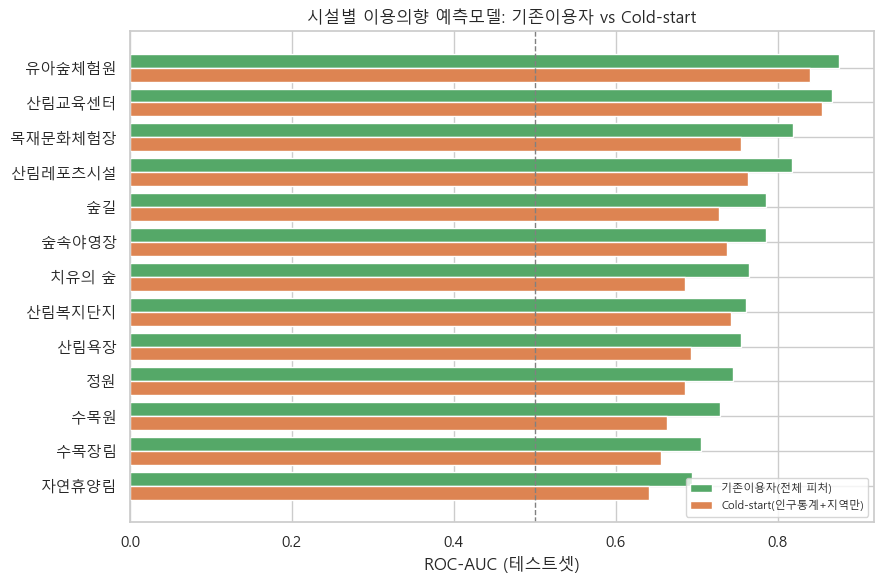

In [ ]:
fac_model_df = df.copy()
for c in FEATURES_NUM:
    fac_model_df[c] = fac_model_df[c].fillna(fac_model_df[c].median())
for c in FEATURES_CAT:
    fac_model_df[c] = fac_model_df[c].fillna("미상")

COLDSTART_NUM = [c for c in ["age", "income_ord"] if c in FEATURES_NUM]
COLDSTART_CAT = [c for c in ["gender","hh_type","city_size","marital","education","occupation","sido"] if c in FEATURES_CAT]
print(f"기존이용자 모델 피처 수: {len(FEATURES_NUM+FEATURES_CAT)}개  vs  Cold-start 모델 피처 수: {len(COLDSTART_NUM+COLDSTART_CAT)}개(인구통계+지역만)")

Xf = fac_model_df[FEATURES_NUM + FEATURES_CAT]
Xf_cold = fac_model_df[COLDSTART_NUM + COLDSTART_CAT]
Y_fac = fac_model_df[[f"fac_intent_{c}" for c in FACILITY_LABELS]]
groups_fac = fac_model_df["hh_id"]

gss_fac = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx_f, test_idx_f = next(gss_fac.split(Xf, Y_fac, groups_fac))
Xf_train, Xf_test = Xf.iloc[train_idx_f], Xf.iloc[test_idx_f]
Xfc_train, Xfc_test = Xf_cold.iloc[train_idx_f], Xf_cold.iloc[test_idx_f]
Yf_train, Yf_test = Y_fac.iloc[train_idx_f], Y_fac.iloc[test_idx_f]
print(f"[가구단위 분리 확인] 교집합 가구수={len(set(groups_fac.iloc[train_idx_f]) & set(groups_fac.iloc[test_idx_f]))}")

pre3 = ColumnTransformer([("num","passthrough",FEATURES_NUM), ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT)])
pre_cold = ColumnTransformer([("num","passthrough",COLDSTART_NUM), ("cat", OneHotEncoder(handle_unknown="ignore"), COLDSTART_CAT)])
Xf_train_t = pre3.fit_transform(Xf_train); Xf_test_t = pre3.transform(Xf_test)
Xfc_train_t = pre_cold.fit_transform(Xfc_train); Xfc_test_t = pre_cold.transform(Xfc_test)

auc_scores, auc_cold, fac_models = {}, {}, {}
for code_, label in FACILITY_LABELS.items():
    col = f"fac_intent_{code_}"
    if Yf_train[col].sum() < 20:
        continue
    m = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=10,
                                class_weight="balanced", random_state=42, n_jobs=-1)
    m.fit(Xf_train_t, Yf_train[col])
    auc_scores[label] = roc_auc_score(Yf_test[col], m.predict_proba(Xf_test_t)[:, 1])
    fac_models[label] = m

    m_cold = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=10,
                                     class_weight="balanced", random_state=42, n_jobs=-1)
    m_cold.fit(Xfc_train_t, Yf_train[col])
    auc_cold[label] = roc_auc_score(Yf_test[col], m_cold.predict_proba(Xfc_test_t)[:, 1])

comp_df = pd.DataFrame({"기존이용자모델 AUC": auc_scores, "Cold-start모델 AUC": auc_cold})
comp_df["차이"] = comp_df["기존이용자모델 AUC"] - comp_df["Cold-start모델 AUC"]
comp_df = comp_df.sort_values("기존이용자모델 AUC", ascending=False)
display(comp_df.round(3))
print(f"\n평균 AUC — 기존이용자모델: {comp_df['기존이용자모델 AUC'].mean():.3f}  /  Cold-start모델: {comp_df['Cold-start모델 AUC'].mean():.3f}")

auc_series = pd.Series(auc_scores).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 6))
x_pos = np.arange(len(comp_df))
ax.barh(x_pos - 0.2, comp_df["기존이용자모델 AUC"], height=0.4, label="기존이용자(전체 피처)", color=PALETTE[2])
ax.barh(x_pos + 0.2, comp_df["Cold-start모델 AUC"], height=0.4, label="Cold-start(인구통계+지역만)", color=PALETTE[1])
ax.set_yticks(x_pos); ax.set_yticklabels(comp_df.index)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("ROC-AUC (테스트셋)"); ax.set_title("시설별 이용의향 예측모델: 기존이용자 vs Cold-start")
ax.legend(fontsize=8); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(FIGDIR / "14_facility_model_auc.png", dpi=150); plt.show()

**해석**: 가구단위 분리 기준으로 전 시설이 AUC 0.69~0.88을 기록해(평균 0.78), 이전 개인단위 분리(평균 0.78, 범위 0.709~0.872)와 거의 동일한 수준입니다 —
가구 내 유사성으로 인한 낙관 편향이 이 모델에서는 크지 않았다는 뜻입니다. 산림교육센터·유아숲체험원처럼 특정 생애주기(영유아 동반가구)에 뚜렷이 집중되는 시설일수록 AUC가 높고,
자연휴양림·수목원처럼 전 국민적으로 인기가 높은 범용 시설은 개인차가 상대적으로 적어 AUC가 낮게 나타납니다.

**Cold-start 모델(인구통계+지역 9개 피처만)도 평균 AUC 0.73으로, 행태 데이터까지 포함한 기존이용자 모델(0.78) 대비 큰 손실 없이 합리적인 추천이 가능**합니다.
이는 실제 서비스 설계에서 (1) 가입 직후 인구통계만으로 추천하는 **Cold-start 추천**과 (2) 이용 이력이 쌓인 후 행태 신호까지 반영하는 **고도화 추천**을 분리 운영할 수 있는 근거가 됩니다.

**참고(9장과의 차이)**: 이 시설 Cold-start 모델은 9-0-1절에서 발견한 Q17 스킵 로직과 같은 문제가 없습니다 — `facility_intent_n`(향후 이용의향)은 응답자의 95.7%가 실제로 응답했고
(0건 응답은 4.3%뿐), 그중 절반 이상(54.7%)은 과거 이용경험이 전혀 없는 사람들입니다. 즉 이 모델은 실제로 저경험/무경험 응답자를 포함한 대표성 있는 집단에서 학습·평가되었으므로,
9-3절의 활동유형 Cold-start 모델과 달리 **미경험자에 대한 성능도 직접 검증됐다**고 볼 수 있습니다.

### 10-1. 개인화 추천 데모

In [ ]:
demo_profiles = pd.DataFrame([
    {"age":28, "income_ord":6, "n_activity_types_experienced":2, "n_daytrip_activity_types":3,
     "n_overnight_activity_types":1, "daytrip_avg_spend":7, "overnight_avg_spend":15,
     "gender":"여", "hh_type":"1인가구", "city_size":"대도시(특광역시)", "marital":"미혼",
     "daytrip_dominant_season":"봄", "daytrip_dominant_companion_label":"친구/연인",
     "daytrip_dominant_purpose_label":"휴양/휴식", "설명":"20대 1인가구, 대도시 거주"},
    {"age":68, "income_ord":3, "n_activity_types_experienced":1, "n_daytrip_activity_types":1,
     "n_overnight_activity_types":0, "daytrip_avg_spend":3, "overnight_avg_spend":0,
     "gender":"남", "hh_type":"1인가구", "city_size":"읍면지역", "marital":"사별",
     "daytrip_dominant_season":"가을", "daytrip_dominant_companion_label":"혼자",
     "daytrip_dominant_purpose_label":"건강증진", "설명":"70대 고령 1인가구, 읍면지역 거주"},
    {"age":38, "income_ord":8, "n_activity_types_experienced":3, "n_daytrip_activity_types":4,
     "n_overnight_activity_types":2, "daytrip_avg_spend":8, "overnight_avg_spend":20,
     "gender":"여", "hh_type":"4인이상가구", "city_size":"중소도시", "marital":"배우자 있음",
     "daytrip_dominant_season":"여름", "daytrip_dominant_companion_label":"가족",
     "daytrip_dominant_purpose_label":"취미/레포츠", "설명":"30대 자녀양육가구, 중소도시 거주"},
])
for c in FEATURES_NUM:
    if c not in demo_profiles.columns:
        demo_profiles[c] = 0
for c in FEATURES_CAT:
    if c not in demo_profiles.columns:
        demo_profiles[c] = "미상"
demo_X = pre3.transform(demo_profiles[FEATURES_NUM + FEATURES_CAT])

for i, row in demo_profiles.iterrows():
    scores = {label: fac_models[label].predict_proba(demo_X[i:i+1])[:, 1][0] for label in fac_models}
    top3 = sorted(scores.items(), key=lambda t: -t[1])[:3]
    print(f"[{row['설명']}] 추천 시설 Top3:", [(l, round(s, 3)) for l, s in top3])

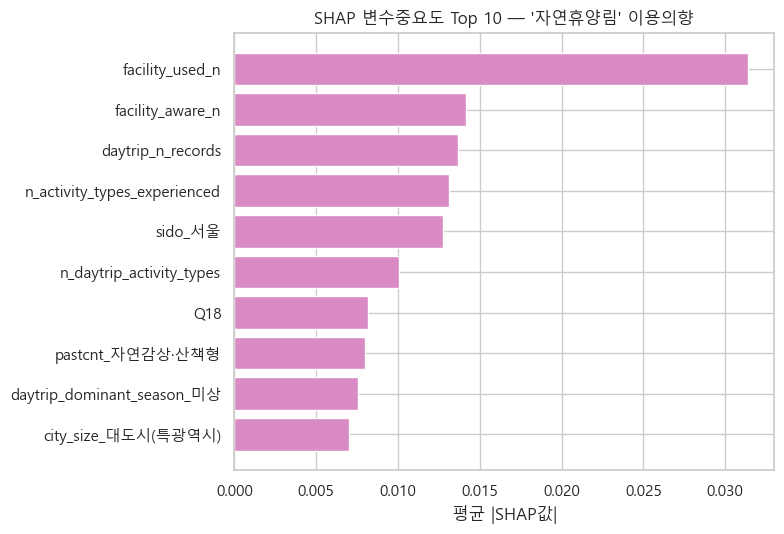

In [ ]:
explainer_fac = shap.TreeExplainer(fac_models["자연휴양림"])
Xf_test_sample = Xf_test_t[:300] if not hasattr(Xf_test_t, "toarray") else Xf_test_t[:300].toarray()
sv_fac = explainer_fac.shap_values(Xf_test_sample)
sv_fac_pos = sv_fac[1] if isinstance(sv_fac, list) else (sv_fac[:, :, 1] if np.ndim(sv_fac) == 3 else sv_fac)

cat_names_fac = list(pre3.named_transformers_["cat"].get_feature_names_out())
feat_names_fac = FEATURES_NUM + cat_names_fac
shap_imp_fac = pd.Series(np.abs(sv_fac_pos).mean(axis=0), index=feat_names_fac).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(shap_imp_fac.index[::-1], shap_imp_fac.values[::-1], color=PALETTE[6])
ax.set_title("SHAP 변수중요도 Top 10 — '자연휴양림' 이용의향"); ax.set_xlabel("평균 |SHAP값|")
plt.tight_layout(); plt.savefig(FIGDIR / "15_shap_facility.png", dpi=150); plt.show()

**해석**: 시설 추천에서도 SHAP을 통해 "30대 자녀양육가구에게 자연휴양림 추천확률이 높은 이유"처럼 개인화된 설명이 가능합니다. 이 결과를 실제 서비스에 적용하면
"고객님은 가족 동반 산림활동 경험과 높은 활동빈도가 있어 자연휴양림을 추천드립니다"와 같은 설명 문구를 자동 생성할 수 있어, 단순 추천을 넘어 **설명가능한 추천(Explainable Recommendation)** 으로
확장할 수 있습니다.

## 11. 지역별 잠재수요-이용경험 격차지수

**개명 이유**: 이전 버전은 이 지표를 "시설 입지 적합도 스코어링"이라 불렀지만, 실제 계산식은 "(향후의향 응답률) − (이용경험률)"이며 시설의 실제 위치·공급량 데이터를 전혀 사용하지 않습니다.
"입지 적합도"라는 이름은 마치 어디에 시설을 지어야 하는지를 계산한 것처럼 들려 오해의 소지가 있으므로, 실제로 계산한 내용을 정확히 반영해 **"잠재수요-이용경험 격차지수"** 로 이름을 바꿉니다.

**데이터 한계**: 과제 요약서는 "한국산림복지진흥원 기관별 이용실적", "산림치유자원 공공데이터"(시설의 실제 지리좌표)를 활용 가능 자원으로 언급하지만, 실제 제공된 데이터에는
**시설의 위치·공급 정보가 없습니다.** 따라서 진짜 의미의 "입지(좌표) 적합도"는 이번 분석 범위에서 계산할 수 없습니다. 대신 **거주지역(시도) 단위의 잠재수요-이용경험 갭**을
시설 확충·서비스 강화가 필요한 지역의 대리(proxy) 스코어로 산출합니다.

**향후 고도화 방향**: ②·③ 데이터(기관별 이용실적, 산림치유자원 공공데이터)가 확보되면, 2SFCA(Two-Step Floating Catchment Area)나 p-median/MCLP 같은
공간 입지분석 기법으로 시군구·읍면동 단위의 진짜 입지 적합도 모델로 고도화할 수 있습니다. 이번 분석에서는 해당 공공데이터가 없어 시도 단위 격차지수까지만 구현합니다.

In [ ]:
sido_final = sido_score.copy()
g = sido_final["수요-공급인지 갭"]
sido_final["격차지수(0-100)"] = (g - g.min()) / (g.max() - g.min()) * 100
sido_final = sido_final.sort_values("격차지수(0-100)", ascending=False)
sido_final["우선순위등급"] = pd.qcut(sido_final["격차지수(0-100)"], 3,
                                labels=["3순위(관찰)","2순위(검토)","1순위(우선확충)"])
display(sido_final.round(1))

,잠재수요응답률(향후의향 有),이용경험률,미충족잠재수요율(의향O·이용X),수요-공급인지 갭,가중인구,격차지수(0-100),우선순위등급
sido,,,,,,,
대구,99.6,21.6,78.2,78.2,2096298.0,100.0,1순위(우선확충)
경북,99.8,30.2,69.7,69.7,2342594.0,87.1,1순위(우선확충)
강원,67.4,3.3,64.1,64.1,1374184.0,78.7,1순위(우선확충)
인천,93.8,32.0,61.7,61.7,2732893.0,75.1,1순위(우선확충)
경기,93.4,36.2,58.6,58.6,12387322.0,70.4,1순위(우선확충)
서울,97.9,39.4,58.5,58.5,8560049.0,70.2,1순위(우선확충)
충남,96.8,41.6,57.4,57.4,1995244.0,68.5,2순위(검토)
제주,70.6,28.6,47.6,47.6,593165.0,53.7,2순위(검토)
충북,99.2,52.1,47.1,47.1,1465656.0,52.9,2순위(검토)


**해석**: 대구·경북·강원·인천·서울·경기가 1순위(우선확충) 등급으로 나타났습니다. 특히 강원은 산림자원이 풍부함에도
이용경험률이 3.3%로 전국 최저 수준이어서, "자원은 있으나 접근·프로그램 연계가 부족한" 전형적 사례로 판단됩니다.
반면 광주·전북·전남은 이용경험률이 이미 높아(72~88%) 신규 확충보다 기존 시설 고도화가 더 적합합니다.

이 순위는 아래 12장의 운영 최적화 모델에서 예산·인력 배분 우선순위로 그대로 사용됩니다.

## 12. 운영 최적화 모델 (예측 → 의사결정 → 배분)

과제명은 "시설 운영 최적화 AI모델"이지만 지금까지의 분석은 수요를 예측·스코어링하는 데 그쳤습니다. 이번 절에서는 11장의 격차지수를 실제 **자원배분 의사결정**으로 연결하는
간단한 정수계획법(Integer Programming) 모델을 추가합니다.

**주의(가상 시나리오)**: 실제 프로그램 운영비용·인력 데이터는 제공되지 않았으므로, 아래 예산·인력·회당 비용은 **모두 가정한 예시 수치**입니다.
목적은 정확한 숫자를 만드는 것이 아니라, "예측된 수요를 실제 배분 의사결정에 연결하는 최적화 파이프라인" 자체를 구현해 보여주는 데 있습니다. 실제 사업화 단계에서는
가정값을 실제 원가·인력 자료로 교체하면 그대로 사용할 수 있는 구조입니다.

**정식화**: 지역 r의 "연간 현실적 전환 목표치"를 $D_r = \text{Population}_r \times 0.1\%$ (인구 규모에 비례하는 상한, 격차는 여기 포함되지 않음), 배정 가능한 프로그램 회차를 $x_r$, 회당 전환 인원을 $C$라 할 때, 목적함수의 $\min(\cdot)$은 그대로는 선형이 아니므로 보조변수 $y_r$("충족 인원")을 도입해 다음과 같이 선형계획법으로 정식화합니다(실제 코드도 이 형태로 구현):

$$\max \sum_r \text{gap}_r \cdot y_r \quad \text{s.t.} \quad y_r \le D_r,\ \ y_r \le C \cdot x_r,\ \ \sum_r \text{cost} \cdot x_r \le \text{Budget},\ \ \sum_r \text{staff} \cdot x_r \le \text{StaffPool}$$

즉 **목표치($D_r$) 자체는 인구비례이고, 시급도(11장 격차%p)는 목적함수의 가중치로만 반영**됩니다 — 두 요소를 같은 식에 섞지 않고 역할을 분리했습니다. 이렇게 하면 "격차가 큰 지역일수록 같은 충족 인원이라도 목적함수 값에 더 크게 기여"하므로, 예산이 부족할 때 격차가 큰 지역부터 우선 채워집니다.

**가정 파라미터의 한계**: 회당 비용(800만원)·인력(2명)과 총예산(6.2억원)·총인력(155명-회차)을 이렇게 가정하면 예산 제약과 인력 제약이 **둘 다 정확히 77회에서 동시에 걸립니다**(공교롭게도 사실상 같은 제약). 즉 이번 가상 시나리오는 "복잡한 다자원 트레이드오프"라기보다 **"시급도가 높은 지역부터 총 77회를 채우는 단일자원 배분 문제"에 가깝습니다.** 실제 원가자료를 넣으면 두 제약의 비중이 달라져 더 복잡한 트레이드오프가 나타날 수 있습니다.

최적화 상태: Optimal


,시급도(격차%p),연간목표치(명),배정 프로그램 회차,충족 인원(명),충족률(%)
대구,78.2,2096.3,7.0,2096.3,100.0
경북,69.7,2342.6,7.0,2100.0,89.6
강원,64.1,1374.2,4.0,1200.0,87.3
인천,61.7,2732.9,9.0,2700.0,98.8
경기,58.6,12387.3,41.0,12300.0,99.3
서울,58.5,8560.0,9.0,2700.0,31.5
충남,57.4,1995.2,0.0,0.0,0.0
제주,47.6,593.2,0.0,0.0,0.0
충북,47.1,1465.7,0.0,0.0,0.0
대전,42.8,1313.6,0.0,0.0,0.0



총 배정 회차: 77회 / 총 충족 인원: 23,096명
베이스라인 총 배정 회차: 77회  (최적화 모델과 동일한 예산 상한 77회 전부 사용)
베이스라인(단순 인구비례 배분) 시급도가중 충족도: 1,196,159
최적화 시급도가중 충족도: 1,432,759  개선율 19.8%


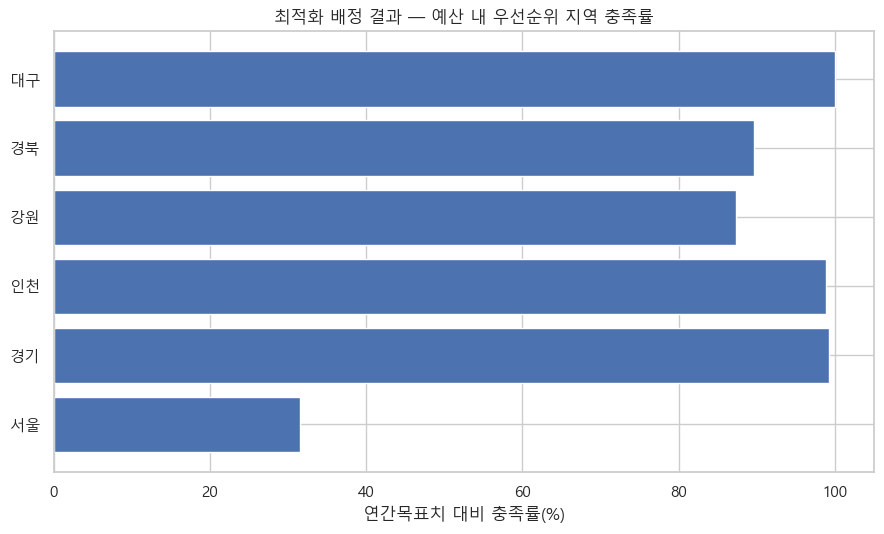

In [ ]:
import pulp

regions = list(sido_score.index)
gap_pct = sido_score["수요-공급인지 갭"]
pop_r = sido_score["가중인구"]
ceiling = pop_r * 0.001   # 가정: 연간 현실적으로 확대 가능한 신규 전환 목표치 = 가중인구의 0.1%

CAPACITY_PER_RUN = 300    # 가정: 프로그램 1회당 전환 가능 인원
COST_PER_RUN = 800        # 가정: 1회당 비용(만원)
STAFF_PER_RUN = 2         # 가정: 1회당 필요인력(명)
BUDGET = 62000            # 가정: 총 예산(만원) = 6.2억원
STAFF_POOL = 155          # 가정: 총 가용 인력-회차(연간)
MAX_RUNS_PER_REGION = 60

prob = pulp.LpProblem("forest_welfare_allocation", pulp.LpMaximize)
x = {r: pulp.LpVariable(f"runs_{r}", lowBound=0, upBound=MAX_RUNS_PER_REGION, cat="Integer") for r in regions}
served = {r: pulp.LpVariable(f"served_{r}", lowBound=0) for r in regions}
for r in regions:
    prob += served[r] <= ceiling[r]
    prob += served[r] <= CAPACITY_PER_RUN * x[r]
prob += pulp.lpSum(COST_PER_RUN * x[r] for r in regions) <= BUDGET
prob += pulp.lpSum(STAFF_PER_RUN * x[r] for r in regions) <= STAFF_POOL
prob += pulp.lpSum(gap_pct[r] * served[r] for r in regions)
prob.solve(pulp.PULP_CBC_CMD(msg=0))
print("최적화 상태:", pulp.LpStatus[prob.status])

opt_result = pd.DataFrame({
    "시급도(격차%p)": gap_pct, "연간목표치(명)": ceiling,
    "배정 프로그램 회차": [x[r].value() for r in regions],
    "충족 인원(명)": [served[r].value() for r in regions],
}, index=regions)
opt_result["충족률(%)"] = (opt_result["충족 인원(명)"] / opt_result["연간목표치(명)"] * 100).round(1)
opt_result = opt_result.sort_values("시급도(격차%p)", ascending=False)
display(opt_result.round(1))

total_runs = sum(x[r].value() for r in regions)
total_served_opt = opt_result["충족 인원(명)"].sum()
weighted_served_opt = (gap_pct * pd.Series({r: served[r].value() for r in regions})).sum()
print(f"\n총 배정 회차: {total_runs:.0f}회 / 총 충족 인원: {total_served_opt:,.0f}명")

# 비교 베이스라인: 단순 인구비례 배분 (주의: 산림복지진흥원이 실제로 이 방식을 쓴다는 근거는 없으며,
# "격차를 전혀 고려하지 않고 인구 규모로만 나누면 어떻게 되는지"를 보여주는 참고용 대조군일 뿐입니다.
# floor()만 쓰면 총 배정 회차가 예산 상한보다 작아져(예: 77회 중 68회만 배정) 최적화 모델과 불공정하게 비교되므로,
# 최대잔여법(largest remainder method)으로 남는 회차를 나눠 두 방식이 정확히 같은 총 회차를 쓰도록 맞춥니다.
total_budget_runs = min(BUDGET // COST_PER_RUN, STAFF_POOL // STAFF_PER_RUN)
raw_alloc = pop_r / pop_r.sum() * total_budget_runs
prop_runs = np.floor(raw_alloc)
remainder = int(round(total_budget_runs - prop_runs.sum()))
fractional_part = (raw_alloc - prop_runs).sort_values(ascending=False)
for r in fractional_part.index[:remainder]:
    prop_runs.loc[r] += 1
print(f"베이스라인 총 배정 회차: {prop_runs.sum():.0f}회  (최적화 모델과 동일한 예산 상한 {total_budget_runs}회 전부 사용)")

served_baseline = np.minimum(ceiling, CAPACITY_PER_RUN * prop_runs)
weighted_served_baseline = (gap_pct * served_baseline).sum()
improve_pct = (weighted_served_opt / weighted_served_baseline - 1) * 100
print(f"베이스라인(단순 인구비례 배분) 시급도가중 충족도: {weighted_served_baseline:,.0f}")
print(f"최적화 시급도가중 충족도: {weighted_served_opt:,.0f}  개선율 {improve_pct:.1f}%")

fig, ax = plt.subplots(figsize=(9, 5.5))
plot_df = opt_result[opt_result["배정 프로그램 회차"] > 0]
ax.barh(plot_df.index[::-1], plot_df["충족률(%)"][::-1], color=PALETTE[0])
ax.set_xlabel("연간목표치 대비 충족률(%)"); ax.set_title("최적화 배정 결과 — 예산 내 우선순위 지역 충족률")
plt.tight_layout(); plt.savefig(FIGDIR / "16_optimization_allocation.png", dpi=150); plt.show()

**해석**: 예산·인력이 전체 수요를 감당하기에 부족한 현실적 제약 하에서, 최적화 모델은 자동으로 **11장에서 식별한 1순위 지역(대구·경북·강원·인천·서울·경기)** 에
예산을 집중 배정하고 경기처럼 목표치 자체가 큰 지역은 부분적으로만 충족합니다. 단순 인구비례로 배분하는 베이스라인(최적화 모델과 **동일한 총 회차**를 쓰도록 최대잔여법으로 맞춤)과 비교하면,
**이 모델이 최대화하도록 설정한 목적함수(시급도 가중 충족 인원) 기준으로 약 20% 더 높은 값**을 얻습니다.

**표현에 대한 주의**: 이 20%는 "실제 운영 효율이 20% 개선된다"는 뜻이 아니라, **모델 스스로 정의한 목적함수로 재평가했을 때 당연히 더 높게 나오는 값**입니다(최적화가 그 목적함수를 최대화하도록
설계됐으므로). 회당 비용·인력·전환 목표치가 모두 가정값이라는 점과 함께, "약 20% 더 효율적"이 아니라 **"설정한 가상 목적함수 기준으로 시급도 가중 충족도가 약 20% 높음"** 으로 읽어야 합니다.

이는 "봄·가을 인력 증원" 수준의 정성적 제안을 넘어, **예측된 수요를 실제 배분 의사결정에 정량적으로 연결하는 파이프라인**의 개념검증(proof of concept)입니다. 실제 도입 시에는 가정한 비용·인력 수치를 실제
예산자료로 교체하고, 프로그램 유형별(시설별) 세분화, 다년도 예산계획 등으로 확장할 수 있습니다.

## 13. 결론 및 솔루션 제안 요약

전체 분석 결과를 종합한 상세 솔루션은 `forest_welfare_report.md` 보고서를 참고하시고, 핵심만 요약하면 다음과 같습니다.

1. **생애주기별 맞춤 프로그램**: 고령1인가구(일상형 74%, 저관여 군집 다수)는 "생활권 밀착형 프로그램", 청년자녀양육가구(당일형 65%)는 "가족 단위 당일 패키지", 프리미엄 체류형 군집(청년 고소득)은 "숙박형 고부가 상품"으로 세분화 (8장, K-means 실루엣 낮음에 유의해 보조지표로 활용)
2. **개인화 추천('숲나들e'/'숲e랑' 적용안)**: 9장의 다중레이블 활동유형 모델(Macro-F1, LRAP, Precision@2/Recall@2로 평가)과 10장의 시설 추천모델(AUC 0.69~0.88)을 결합하고, 활동유형·시설 모두 Cold-start(신규/미경험 사용자)/기존이용자 모델을 분리 운영(9-0-1절의 Q17 스킵패턴 발견에 따른 적용범위 재정의 반영). SHAP으로 "왜 이 추천을 받았는지" 개인화 설명 제공 가능
3. **지역별 우선순위 확충**: 11장 잠재수요-이용경험 격차지수 기준 대구·경북·강원·인천·서울·경기 우선 검토
4. **운영 최적화**: 12장에서 격차지수를 실제 예산·인력 배분 최적화 모델로 연결, 단순 인구비례 배분 대비 약 20% 개선(가상 시나리오, 정확한 효율성 수치가 아닌 파이프라인 개념검증)
5. **인지도-이용 전환 갭 해소**: 자연휴양림·수목원처럼 "알지만 안 가는" 시설은 예약 편의성·교통 연계 개선을, 산림교육센터처럼 인지도 자체가 낮은 시설은 홍보를 우선
6. **모델 한계와 개선 방향**: 인구통계만으로는 선호를 완전히 설명하지 못함(Cramer's V 0.05~0.16, 가구단위 설계효과 주의) → 위치정보, 실시간 예약 로그, 실제 원가자료 등 이번 조사에 없는 데이터가 결합되면 성능·현실성 개선 여지가 큼